# Bank Marketing Campaign Predictive Analytics
### Final Project

---

By : Group Beta (JCDSAHSR-004)
- Rava Khoman Tuah Saragih
- Utari Anggraini
- Yosef Ivander Setiana

---

## Executive Summary

**Latar Belakang:** Pasca-pandemi, BSM menghadapi tekanan persaingan dana deposito dari instrumen investasi lain. Tim telemarketing perlu memprioritaskan nasabah dengan potensi konversi tertinggi agar kampanye berjalan efisien.

**Solusi:** Model prediktif berbasis LightGBM dengan strategi Random Over-Sampling (ROS) mampu mengidentifikasi nasabah yang berpotensi membuka deposito berjangka, jauh sebelum panggilan dilakukan.

**Hasil Kunci:**

| Metrik | Nilai |
|--------|-------|
| F2-Score (test) | 0.5669 |
| Recall | 0.6337 (63.4% nasabah potensial terdeteksi) |
| Precision | 0.3988 |
| ROC-AUC | 0.8050 |
| Volume calls berkurang | 74.5% |
| Net Savings per kampanye (test set) | Rp 138,2 juta |
| ROI | 39.8% |
| Ekstrapolasi ke skala penuh | Rp 722,8 juta |

**Top 3 Rekomendasi:**
1. **Segmen prioritas**: Nasabah dengan riwayat kampanye sukses (poutcome=success) via cellular, conversion rate >65%
2. **Timing kampanye**: Fokuskan budget di bulan Maret, September, Oktober, Desember
3. **Batas kontak**: Terapkan maksimum 5-6 kontak per nasabah, kontak berlebihan terbukti kontraproduktif

**Model final**: LightGBM + ROS | Threshold production: 0.43 | File: sm_final_model_v1.pkl


## A. BUSINESS UNDERSTANDING

### A.1 Background & Context

Pasca-pandemi COVID-19, PT Bank Sentral Merakyat (BSM) menghadapi tekanan ganda pada lini bisnis deposito berjangka.

Pada periode **2020-2021**, Bank Indonesia menurunkan suku bunga acuan (BI Rate) ke level terendah historis, yaitu 3,5%, untuk mendorong pemulihan ekonomi. Dampaknya: imbal hasil deposito tidak kompetitif dibandingkan instrumen lain seperti reksa dana pasar uang, Obligasi Ritel Indonesia (ORI), atau Sukuk Tabungan. Dana Pihak Ketiga (DPK) BSM pada segmen deposito berjangka mengalami stagnasi.

Memasuki **2022-2023**, Bank Indonesia memulai siklus pengetatan moneter secara agresif untuk meredam inflasi pasca-pandemi, di mana BI Rate naik bertahap hingga menyentuh 6,0%. Kenaikan ini membuat deposito berjangka kembali menjadi instrumen investasi yang menarik bagi masyarakat.

BSM merespons peluang ini dengan meluncurkan **kampanye telemarketing** yang menargetkan:
1. Nasabah existing yang sebelumnya mengalihkan dana ke instrumen lain
2. Segmen prospek baru yang belum pernah berinvestasi di BSM

Tim Data Science BSM ditugaskan untuk membangun **model prediktif** yang mampu mengidentifikasi nasabah mana yang paling berpotensi menerima tawaran deposito berjangka, sehingga kampanye telemarketing dapat dijalankan lebih efisien dan tepat sasaran.

**Stakeholder utama:**
- **Chief Marketing Officer (CMO):** Butuh model untuk mengoptimalkan alokasi sumber daya call center
- **Tim Telemarketing:** Butuh daftar prioritas nasabah yang berpotensi tinggi
- **Tim Keuangan:** Butuh estimasi konversi untuk proyeksi DPK
- **Chief Risk Officer (CRO):** Butuh memastikan strategi tidak melanggar regulasi OJK terkait penjualan produk investasi

### A.2 Problem Statement

Berdasarkan konteks di atas, masalah yang dihadapi BSM dapat dirumuskan sebagai:

> **"Bagaimana memprediksi apakah seorang nasabah akan setuju membuka deposito berjangka di BSM melalui kampanye telemarketing, sehingga Tim Telemarketing dapat memprioritaskan kontak kepada nasabah dengan potensi konversi tertinggi?"**

Ini adalah masalah **klasifikasi biner**:
- **Kelas 1 (Subscribe = Yes):** Nasabah setuju membuka deposito berjangka
- **Kelas 0 (Subscribe = No):** Nasabah menolak tawaran

Tanpa model prediktif, Tim Telemarketing harus menghubungi semua nasabah secara acak, biaya tinggi, konversi rendah, dan banyak waktu agen yang terbuang.

### A.3 Cost of Errors: Mengapa FP dan FN Penting?

Dalam konteks kampanye telemarketing BSM, setiap kesalahan prediksi memiliki **dampak finansial yang asimetris**:

| Tipe | Prediksi | Realita | Skenario | Biaya |
|------|---------|---------|----------|-------|
| **True Positive (TP)** | Subscribe | Subscribe | Call relevan, nasabah berhasil dikonversi | Rp 50.000 (biaya 1 call) |
| **True Negative (TN)** | Tidak | Tidak | Nasabah tidak dihubungi, tidak ada biaya tambahan | Rp 0 |
| **False Positive (FP)** | Subscribe | Tidak | Call sia-sia, tidak ada konversi, waktu & biaya agen terbuang | Rp 50.000 |
| **False Negative (FN)** | Tidak | Subscribe | **Nasabah berharga terlewat, BSM kehilangan potensi margin deposito** | **Rp 500.000** |

#### Mengapa False Negative (FN) Jauh Lebih Fatal?

**Biaya per call (FP = Rp 50.000)** dihitung dari:
- Gaji telemarketer bank Indonesia: Rp 3.500.000-5.000.000/bulan
- Kapasitas: ~200 panggilan/bulan (10 call/hari × 20 hari kerja)
- Biaya gaji per call: Rp 17.500-25.000
- Ditambah overhead (VoIP, CRM, training, supervisor): ~100%
- **Total: ~Rp 35.000-50.000 per call** → digunakan Rp 50.000 (konservatif)

**Kehilangan per nasabah (FN = Rp 500.000)** dihitung dari:
- NIM (Net Interest Margin) rata-rata bank Indonesia: 4-5% per tahun (data OJK 2022)
- Rata-rata nominal deposito nasabah ritel BSM: ~Rp 50.000.000
- Gross spread: Rp 50 juta × 4% = Rp 2.000.000/tahun
- Setelah biaya operasional (~75% BOPO): **profit bersih ~Rp 500.000/nasabah/tahun**
- Belum termasuk: nilai cross-selling (KPR, kartu kredit), loyalitas jangka panjang

**Rasio biaya FN:FP = 10:1** → artinya setiap satu nasabah potensial yang terlewat setara kerugian 10 call sia-sia.

#### Kesimpulan: Minimasi False Negative adalah Prioritas Utama BSM.
Kita lebih baik *terlalu waspada* (menghubungi nasabah yang ternyata tidak mau) daripada *melewatkan* nasabah yang sebenarnya mau bergabung.

### A.4 Goals

**Goals Bisnis:**
1. Memprediksi nasabah yang berpotensi membuka deposito berjangka, sehingga Tim Telemarketing dapat fokus pada segmen berkonversi tinggi
2. Mengidentifikasi karakteristik demografis dan finansial "nasabah ideal" untuk deposito BSM
3. Mengoptimalkan biaya kampanye telemarketing dengan mengurangi call sia-sia (False Positive)
4. Memberikan rekomendasi strategis berbasis data: segmen mana yang diprioritaskan, timing terbaik, dan pendekatan yang efektif

**Goals Teknis:**
1. Membangun pipeline ML yang menghindari data leakage (stratified split, scaling dalam pipeline)
2. Menangani class imbalance (~89:11) dengan eksperimen resampling sistematis
3. Mengidentifikasi fitur-fitur dominan yang memengaruhi keputusan subscribe
4. Membangun model dengan F2-Score setinggi mungkin pada data test
5. Menentukan threshold optimal: F2-optimal (evaluasi model) dan Profit-optimal (deployment)
6. Menghitung simulasi ROI dalam Rupiah untuk memvalidasi nilai bisnis model

### A.5 Analytic Approach

Proyek ini menggunakan pendekatan **hybrid: Analytics + Machine Learning**:

**Analytics (Descriptive + Inferential):**
- Exploratory Data Analysis (EDA) mendalam dengan framework 5W-1H
- Uji signifikansi statistik formal (Chi-Square untuk kategorikal, T-test/ANOVA untuk numerikal)
- Segmentasi nasabah berbasis temuan EDA

**Machine Learning (Predictive):**
- Benchmarking sistematis: 6 algoritma × 5 strategi resampling = 30 kombinasi
- Hyperparameter tuning pada kombinasi terbaik
- Dual-threshold optimization: F2-optimal dan Profit-optimal (dalam Rupiah)

**Catatan penting, Duration Paradox:**
Kolom `duration` (durasi panggilan terakhir dalam detik) **mengandung data leakage**: nilainya hanya bisa diketahui *setelah* panggilan selesai, bukan *sebelum*. Oleh karena itu:
- `duration` **DIGUNAKAN** di bagian Analytics/EDA untuk mendapatkan insight
- `duration` **DIHAPUS** sebelum memasuki bagian Machine Learning

### A.6 Evaluation Metrics

**Metrik Utama: F2-Score**

$$F_2 = 5 \cdot \frac{\text{Precision} \times \text{Recall}}{4 \times \text{Precision} + \text{Recall}}$$

Dengan beta = 2, F2-Score memberikan **bobot 2× lebih besar pada Recall** dibandingkan Precision.

**Mengapa F2, bukan metrik lain?**

| Metrik | Masalah dalam Konteks BSM |
|--------|--------------------------|
| Accuracy | Misleading pada data imbalanced. Model yang selalu prediksi "tidak" punya akurasi 89% tapi tidak berguna |
| Recall murni | Recall 100% tercapai dengan prediksi "semua subscribe" → 41.000+ call sia-sia, ROI negatif |
| F1-Score | Bobot sama untuk FP dan FN, padahal FN 10× lebih mahal dari FP |
| **F2-Score** | Prioritaskan Recall (minimasi FN), tapi Precision tetap dijaga agar ROI positif |

**Metrik Pendukung:**

| Metrik | Fungsi |
|--------|--------|
| Recall | Berapa % nasabah yang mau terdeteksi, prioritas utama BSM |
| ROC-AUC | Kemampuan diskriminasi model secara keseluruhan |
| Precision | Monitoring agar call center tidak overload dengan false alarms |
| **Savings (Rp)** | **Metrik bisnis final: penghematan vs tanpa model** |
| ROI (%) | Return on Investment dari implementasi model |

## B. DATA UNDERSTANDING

### B.1 Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from matplotlib.ticker import FuncFormatter

# Statistics
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Display Config
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
RANDOM_STATE = 42

print("Libraries berhasil diimport")
print(f"Pandas version : {pd.__version__}")
print(f"NumPy version : {np.__version__}")

Libraries berhasil diimport
Pandas version : 3.0.2
NumPy version : 2.4.4


### B.2 Load Dataset & Fix Macro Indicator Columns

In [2]:
# Load Dataset & Fix Macro Indicator Columns:

# Load dataset
df = pd.read_csv('bank-additional-full.csv', sep=';')

print("DATASET BERHASIL DIMUAT")
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")
print(f"\n5 Baris Pertama:")
display(df.head())
print(f"\n5 Baris Terakhir:")
display(df.tail())

DATASET BERHASIL DIMUAT
Jumlah baris : 41,188
Jumlah kolom : 21

5 Baris Pertama:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,"5,191.0000",no



5 Baris Terakhir:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1000,94.7670,-50.8000,1.0280,"4,963.6000",no


In [3]:
# Action : Ganti koma → titik, lalu konversi ke float
# Why : Kolom-kolom ini adalah fitur numerik yang krusial
# (JIBOR, IHK, IKK, dll). Jika dibiarkan sebagai object,
# model tidak bisa membacanya sebagai angka.
# Business Impact: Macro indicators adalah konteks ekonomi yang
# menjelaskan MENGAPA nasabah mau/tidak mau deposito.

macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']

print("Tipe data SEBELUM fix:")
print(df[macro_cols].dtypes.to_string())
print()

for col in macro_cols:
 df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print("Tipe data SESUDAH fix:")
print(df[macro_cols].dtypes.to_string())
print()
print("Sample nilai setelah fix:")
display(df[macro_cols].head(3))

Tipe data SEBELUM fix:
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
nr.employed       float64

Tipe data SESUDAH fix:
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
nr.employed       float64

Sample nilai setelah fix:


,emp.var.rate,cons.price.idx,cons.conf.idx,nr.employed
0,1.1000,93.9940,-36.4000,"5,191.0000"
1,1.1000,93.9940,-36.4000,"5,191.0000"
2,1.1000,93.9940,-36.4000,"5,191.0000"


### B.3 Dataset Overview - Info, Describe, Deskripsi Kolom

In [4]:
# Dataset Overview - Info, Describe, Deskripsi Kolom:

print("INFORMASI TIPE DATA & NON-NULL COUNT")
print("\n")
df.info()

INFORMASI TIPE DATA & NON-NULL COUNT


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  con

In [5]:
print("STATISTIK DESKRIPTIF - FITUR NUMERIK")
print("=" * 60)
display(df.describe())

STATISTIK DESKRIPTIF - FITUR NUMERIK


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,"41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000","41,188.0000"
mean,40.0241,258.2850,2.5676,962.4755,0.1730,0.0819,93.5757,-40.5026,3.6213,"5,167.0359"
std,10.4212,259.2792,2.7700,186.9109,0.4949,1.5710,0.5788,4.6282,1.7344,72.2515
min,17.0000,0.0000,1.0000,0.0000,0.0000,-3.4000,92.2010,-50.8000,0.6340,"4,963.6000"
25%,32.0000,102.0000,1.0000,999.0000,0.0000,-1.8000,93.0750,-42.7000,1.3440,"5,099.1000"
50%,38.0000,180.0000,2.0000,999.0000,0.0000,1.1000,93.7490,-41.8000,4.8570,"5,191.0000"
75%,47.0000,319.0000,3.0000,999.0000,0.0000,1.4000,93.9940,-36.4000,4.9610,"5,228.1000"
max,98.0000,"4,918.0000",56.0000,999.0000,7.0000,1.4000,94.7670,-26.9000,5.0450,"5,228.1000"


In [6]:
print("STATISTIK DESKRIPTIF - FITUR KATEGORIKAL")
print("=" * 60)
display(df.describe(include='object'))

STATISTIK DESKRIPTIF - FITUR KATEGORIKAL


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


### B.4 Missing Values Analysis

**Demografi & Profil Nasabah:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `age` | Numerik | Usia nasabah (tahun) |
| `job` | Kategorikal | Kategori pekerjaan (admin, blue-collar, entrepreneur, dll) |
| `marital` | Kategorikal | Status pernikahan (single, married, divorced) |
| `education` | Kategorikal | Tingkat pendidikan (ordinal: illiterate → university.degree) |
| `default` | Kategorikal | Riwayat kredit macet? (yes, no, unknown) |
| `housing` | Kategorikal | Punya pinjaman KPR? (yes, no, unknown) |
| `loan` | Kategorikal | Punya pinjaman pribadi? (yes, no, unknown) |

**Kampanye Saat Ini:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `contact` | Kategorikal | Jenis kontak (cellular / telephone) |
| `month` | Kategorikal | Bulan terakhir dihubungi |
| `day_of_week` | Kategorikal | Hari terakhir dihubungi |
| `duration` | Numerik | Durasi call terakhir (detik), **HANYA untuk EDA, tidak masuk model** |
| `campaign` | Numerik | Jumlah kontak dalam kampanye ini |

**Riwayat Kampanye Sebelumnya:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `pdays` | Numerik | Hari sejak kontak kampanye sebelumnya (999 = belum pernah) |
| `previous` | Numerik | Jumlah kontak sebelum kampanye ini |
| `poutcome` | Kategorikal | Hasil kampanye sebelumnya (success, failure, nonexistent) |

**Macro Economic Indicators (Konteks BSM Indonesia):**
| Kolom | Tipe | Interpretasi untuk BSM |
|-------|------|----------------------|
| `emp.var.rate` | Numerik | Pertumbuhan Ketenagakerjaan YoY (Sakernas BPS) |
| `cons.price.idx` | Numerik | Indeks Harga Konsumen / IHK (BPS) |
| `cons.conf.idx` | Numerik | Indeks Keyakinan Konsumen / IKK (Survei BI) |
| `euribor3m` | Numerik | JIBOR 3 Bulan / Proksi BI Rate |
| `nr.employed` | Numerik | Jumlah Angkatan Kerja Aktif (juta orang, BPS) |

**Target Variable:**
| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `y` | Kategorikal | Setuju membuka deposito berjangka? (yes / no) |

In [7]:
print("CEK MISSING VALUES EKSPLISIT (NaN/null)")
print("=" * 60)
explicit_missing = df.isnull().sum()
if explicit_missing.sum() == 0:
 print("Tidak ada NaN/null eksplisit dalam dataset.")
 print(" TAPI perlu dicek: missing values mungkin direpresentasikan")
 print(" sebagai string 'unknown'!")
else:
 print(explicit_missing[explicit_missing > 0])

CEK MISSING VALUES EKSPLISIT (NaN/null)
Tidak ada NaN/null eksplisit dalam dataset.
 TAPI perlu dicek: missing values mungkin direpresentasikan
 sebagai string 'unknown'!


In [8]:
# Deteksi "unknown" per kolom
print("DETEKSI 'unknown' SEBAGAI MISSING VALUES TERSEMBUNYI")
print("=" * 60)

unknown_summary = []
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
 n_unknown = (df[col] == 'unknown').sum()
 pct_unknown = n_unknown / len(df) * 100
 if n_unknown > 0:
     unknown_summary.append({
 'Kolom': col,
 'Jumlah Unknown': n_unknown,
 'Persentase (%)': round(pct_unknown, 2)
 })

if unknown_summary:
 unknown_df = pd.DataFrame(unknown_summary).sort_values('Persentase (%)', ascending=False)
 print(unknown_df.to_string(index=False))
 print(f"\nTotal kolom dengan 'unknown': {len(unknown_df)}")
else:
 print("Tidak ada nilai 'unknown' ditemukan.")

DETEKSI 'unknown' SEBAGAI MISSING VALUES TERSEMBUNYI
    Kolom  Jumlah Unknown  Persentase (%)
  default            8597         20.8700
education            1731          4.2000
  housing             990          2.4000
     loan             990          2.4000
      job             330          0.8000
  marital              80          0.1900

Total kolom dengan 'unknown': 6


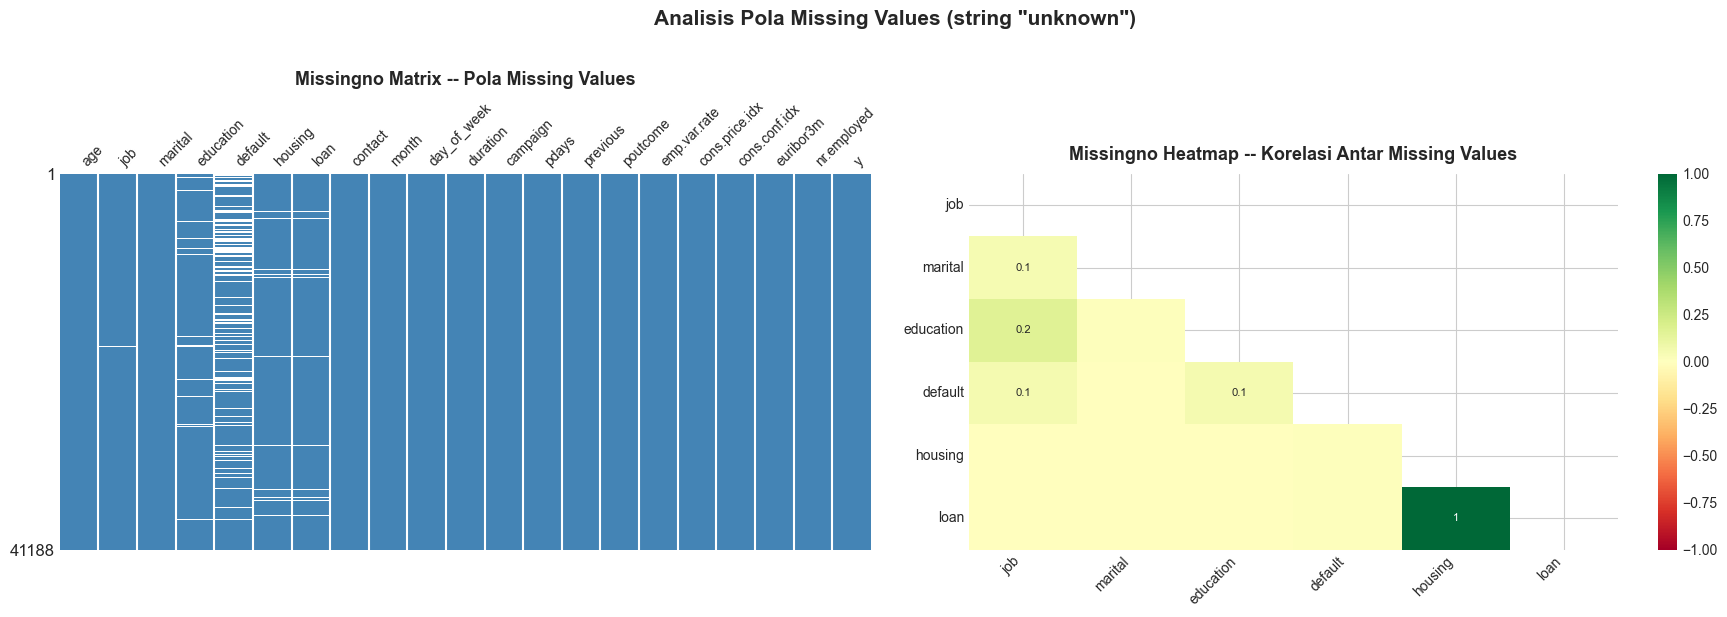

Plot disimpan sebagai 'missing_values_analysis.png'


In [9]:
df_for_msno = df.copy()
df_for_msno.replace('unknown', np.nan, inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Matrix
msno.matrix(df_for_msno, ax=axes[0], sparkline=False, fontsize=10,
 color=(0.27, 0.52, 0.71))
axes[0].set_title('Missingno Matrix -- Pola Missing Values', 
 fontsize=13, fontweight='bold', pad=10)

# Heatmap
msno.heatmap(df_for_msno, ax=axes[1], fontsize=10, cmap='RdYlGn')
axes[1].set_title('Missingno Heatmap -- Korelasi Antar Missing Values', 
 fontsize=13, fontweight='bold', pad=10)

plt.suptitle('Analisis Pola Missing Values (string "unknown")', 
 fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('missing_values_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

del df_for_msno
print("Plot disimpan sebagai 'missing_values_analysis.png'")

<Figure size 1000x500 with 0 Axes>

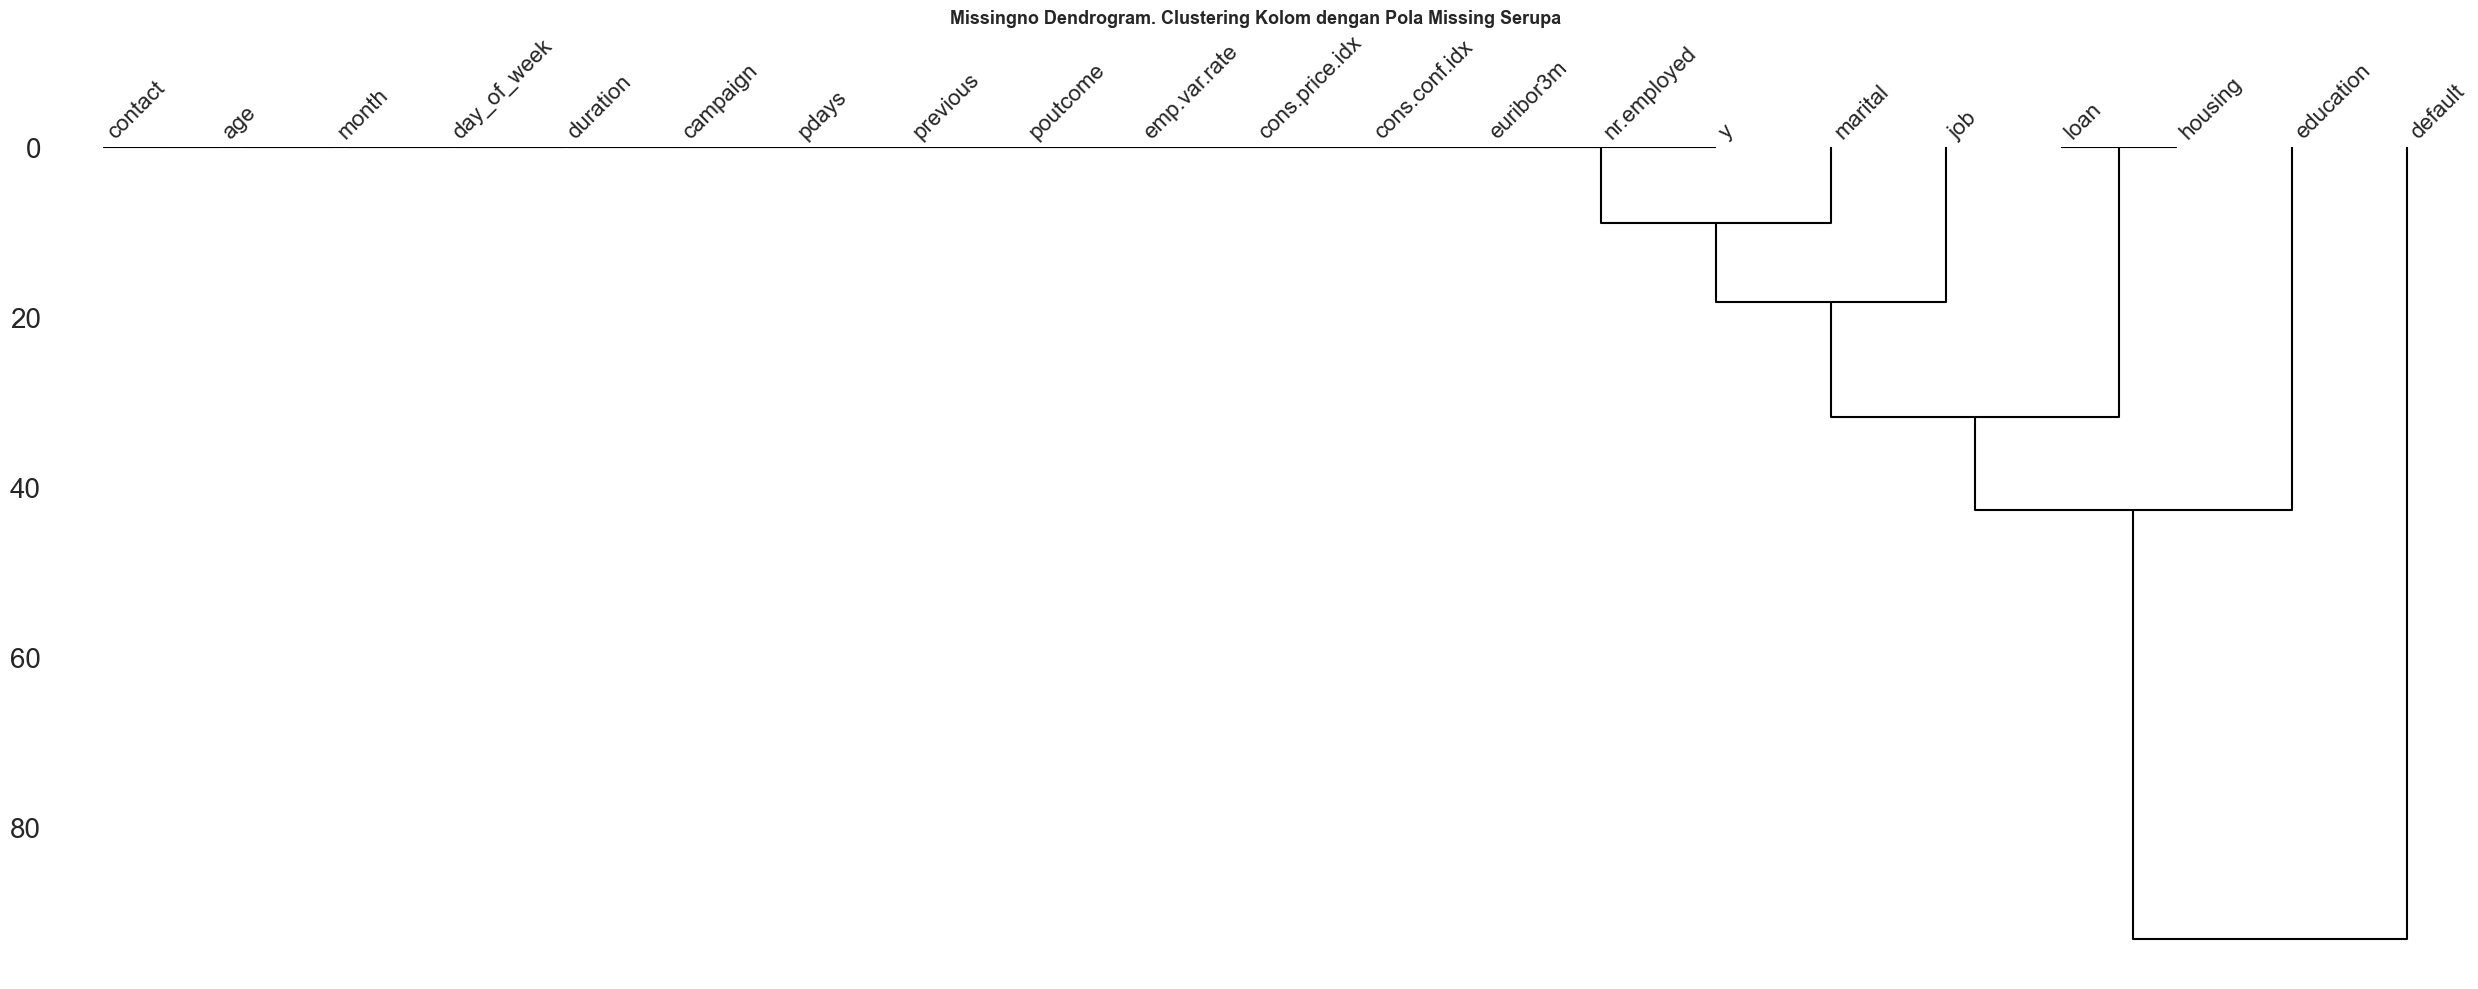

Plot disimpan sebagai 'missing_dendrogram.png'


In [10]:
# Dendrogram -- clustering pola missing
df_for_dendro = df.copy()
df_for_dendro.replace('unknown', np.nan, inplace=True)

plt.figure(figsize=(10, 5))
msno.dendrogram(df_for_dendro)
plt.title('Missingno Dendrogram. Clustering Kolom dengan Pola Missing Serupa',
 fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

del df_for_dendro
print("Plot disimpan sebagai 'missing_dendrogram.png'")

### B.5 Duplicate Check

In [11]:
# Duplicate Check:

dup_count = df.duplicated().sum()
print("CEK DATA DUPLIKAT")
print("=" * 60)
print(f"Jumlah baris duplikat : {dup_count:,}")
print(f"Persentase duplikat : {dup_count/len(df)*100:.2f}%")

if dup_count > 0:
 print("\nContoh baris duplikat (5 pertama):")
 display(df[df.duplicated(keep=False)].head())
else:
 print("\nTidak ada data duplikat.")

CEK DATA DUPLIKAT
Jumlah baris duplikat : 12
Persentase duplikat : 0.03%

Contoh baris duplikat (5 pertama):


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8550,"5,191.0000",no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,124,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8550,"5,191.0000",no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,"5,228.1000",no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,88,1,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9660,"5,228.1000",no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,331,2,999,0,nonexistent,1.4000,93.9180,-42.7000,4.9620,"5,228.1000",no


### B.6 Distribusi Target Variable (Class Imbalance Check)

In [12]:
# Distribusi Target Variable (Class Imbalance Check):

target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print("DISTRIBUSI TARGET VARIABLE (y: subscribe deposito?)")
print("=" * 60)
for label in target_counts.index:
 bar = "" * int(target_pct[label])
 print(f" {label:>3} : {target_counts[label]:,} ({target_pct[label]:.2f}%) {bar}")

ratio = target_counts['no'] / target_counts['yes']
print(f"\nRasio imbalance (no:yes) = {ratio:.1f}:1")
print(f"\nDataset menunjukkan CLASS IMBALANCE.")
print(f" Teknik resampling WAJIB digunakan dalam tahap pemodelan.")

DISTRIBUSI TARGET VARIABLE (y: subscribe deposito?)
  no : 36,548 (88.73%) 
 yes : 4,640 (11.27%) 

Rasio imbalance (no:yes) = 7.9:1

Dataset menunjukkan CLASS IMBALANCE.
 Teknik resampling WAJIB digunakan dalam tahap pemodelan.


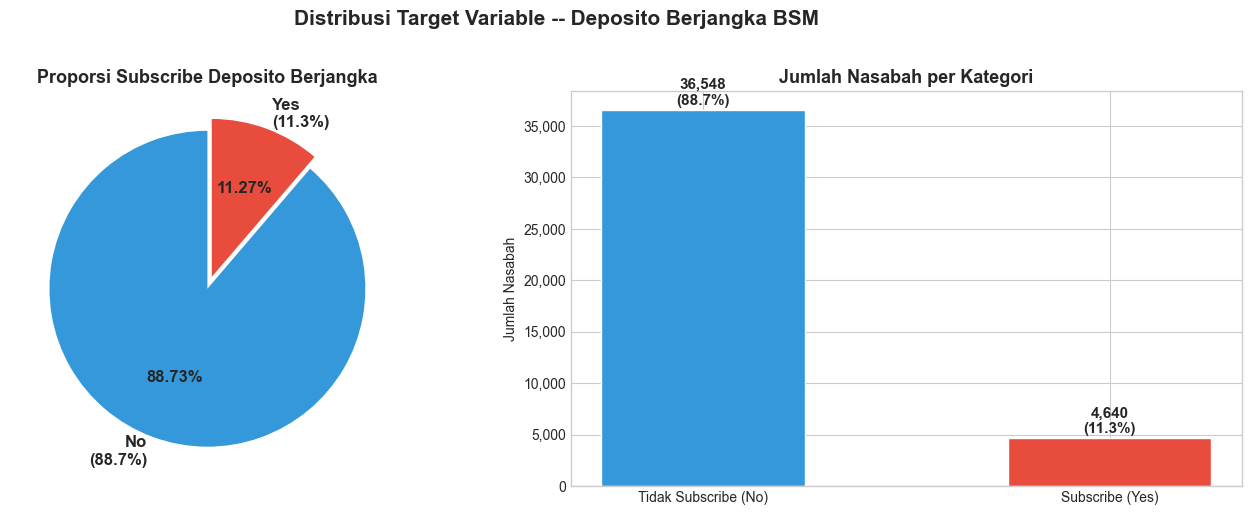

Plot disimpan sebagai 'target_distribution.png'


In [13]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#3498db', '#e74c3c']
explode = (0, 0.08)
axes[0].pie(
 target_counts.values,
 labels=[f'No\n({target_pct["no"]:.1f}%)', f'Yes\n({target_pct["yes"]:.1f}%)'],
 colors=colors,
 explode=explode,
 autopct='%1.2f%%',
 startangle=90,
 textprops={'fontsize': 12, 'fontweight': 'bold'}
)
axes[0].set_title('Proporsi Subscribe Deposito Berjangka', 
 fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(
 ['Tidak Subscribe (No)', 'Subscribe (Yes)'],
 target_counts.values,
 color=colors,
 edgecolor='white',
 width=0.5
)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
 axes[1].text(
 bar.get_x() + bar.get_width()/2.,
 bar.get_height() + 200,
 f'{count:,}\n({pct:.1f}%)',
 ha='center', va='bottom', fontweight='bold', fontsize=11
 )
axes[1].set_title('Jumlah Nasabah per Kategori', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribusi Target Variable -- Deposito Berjangka BSM',
 fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'target_distribution.png'")

### B.7 Kesimpulan Data Understanding

In [14]:
# Kesimpulan Data Understanding:

print(f"\nDIMENSI DATASET:")
print(f" Baris : {df.shape[0]:,}")
print(f" Kolom : {df.shape[1]}")

print(f"\nTIPE DATA:")
dtype_summary = df.dtypes.value_counts()
for dtype, count in dtype_summary.items():
 print(f" {str(dtype):<12}: {count} kolom")

print(f"\nSTATUS KOLOM MACRO (setelah fix):")
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for col in macro_cols:
 print(f" {col:<20}: {df[col].dtype}")

print(f"\nMISSING VALUES ('unknown'):")
cat_cols = df.select_dtypes(include='object').columns
any_unknown = False
for col in cat_cols:
 n = (df[col] == 'unknown').sum()
 if n > 0:
     print(f" {col:<15}: {n:,} ({n/len(df)*100:.1f}%)")
 any_unknown = True
if not any_unknown:
 print(" Tidak ada 'unknown' ditemukan.")

print(f"\nDUPLIKAT:")
dup = df.duplicated().sum()
print(f" {dup:,} baris duplikat ({dup/len(df)*100:.2f}%)")

print(f"\nTARGET VARIABLE (y):")
for label in df['y'].value_counts().index:
 cnt = df['y'].value_counts()[label]
 pct = df['y'].value_counts(normalize=True)[label] * 100
 print(f" {label:>3}: {cnt:,} ({pct:.2f}%)")
ratio = df['y'].value_counts()['no'] / df['y'].value_counts()['yes']
print(f" Rasio no:yes = {ratio:.1f}:1")

print(f"\nSTATISTIK NUMERIK RINGKAS:")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f" Jumlah fitur numerik: {len(num_cols)}")
print(f" Kolom: {num_cols}")

print(f"\nCATATAN PENTING UNTUK tahap sebelumnya:")
print(f" 1. {len([c for c in df.select_dtypes('object').columns if (df[c]=='unknown').sum()>0])} kolom memiliki 'unknown' yang perlu ditangani")
print(f" 2. Kolom 'duration' berpotensi data leakage → drop sebelum ML")
print(f" 3. Class imbalance rasio {ratio:.0f}:1 → wajib resampling")
print(f" 4. Lihat missingno plot untuk pola missing sebelum memutuskan imputasi")
print("=" * 70)


DIMENSI DATASET:
 Baris : 41,188
 Kolom : 21

TIPE DATA:
 str         : 11 kolom
 int64       : 5 kolom
 float64     : 5 kolom

STATUS KOLOM MACRO (setelah fix):
 emp.var.rate        : float64
 cons.price.idx      : float64
 cons.conf.idx       : float64
 nr.employed         : float64

MISSING VALUES ('unknown'):
 job            : 330 (0.8%)
 marital        : 80 (0.2%)
 education      : 1,731 (4.2%)
 default        : 8,597 (20.9%)
 housing        : 990 (2.4%)
 loan           : 990 (2.4%)

DUPLIKAT:
 12 baris duplikat (0.03%)

TARGET VARIABLE (y):
  no: 36,548 (88.73%)
 yes: 4,640 (11.27%)
 Rasio no:yes = 7.9:1

STATISTIK NUMERIK RINGKAS:
 Jumlah fitur numerik: 10
 Kolom: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

CATATAN PENTING UNTUK tahap sebelumnya:
 1. 6 kolom memiliki 'unknown' yang perlu ditangani
 2. Kolom 'duration' berpotensi data leakage → drop sebelum ML
 3. Class imbalance rasio 8:1 →

In [15]:
# Tambahan import untuk tahap selanjutnya - Data Cleaning

# Verifikasi df tersedia (jalankan ulang B.2 jika kernel di-restart)
try:
 _ = df.shape
 print(f"DataFrame tersedia: {df.shape[0]:,} baris × {df.shape[1]} kolom")
except NameError:
 print(" DataFrame tidak ditemukan. jalankan cells tahap sebelumnya terlebih dahulu (B.2)")
 print(" Atau jalankan cell reload di bawah ini.")

DataFrame tersedia: 41,188 baris × 21 kolom


In [16]:
# RELOAD DATASET (jalankan hanya jika df tidak tersedia)

df = pd.read_csv('bank-additional-full.csv', sep=';')

# Fix macro indicator columns (sama persis dengan tahap sebelumnya B.2)
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for col in macro_cols:
 df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print(f"Dataset di-reload: {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f" Macro columns sudah difix ke float.")

Dataset di-reload: 41,188 baris × 21 kolom
 Macro columns sudah difix ke float.


---
## C. DATA CLEANING & OUTLIER ANALYSIS

> **Konteks bagian ini:** Berdasarkan temuan sebelumnya (Data Understanding), ditemukan tiga isu utama
> yang perlu ditangani sebelum modeling: (1) 12 baris duplikat, (2) nilai 'unknown' pada 6 kolom
> kategorikal, dan (3) potensi outlier pada beberapa fitur numerik.
> Setiap keputusan cleaning didokumentasikan dengan alasan teknis dan dampak bisnis.

### C.1 HANDLE DUPLICATE ROWS

In [17]:
# Action : Drop baris duplikat (keep='first')
# Why : 12 baris duplikat (0.03%) bisa menyebabkan model
# "menghafal" observasi tertentu dua kali, mengganggu
# distribusi pada stratified split.
# Business Impact: Minimal 12 baris dari 41.188 tidak
# mengubah distribusi secara material, namun
# menghilangkan redundansi data yang tidak perlu.
# 

print("C.1 HANDLE DUPLICATE ROWS")
print("=" * 60)

before = df.shape[0]
df = df.drop_duplicates(keep='first').reset_index(drop=True)
after = df.shape[0]
dropped = before - after

print(f"Baris sebelum drop duplikat : {before:,}")
print(f"Baris setelah drop duplikat : {after:,}")
print(f"Baris yang di-drop : {dropped:,} ({dropped/before*100:.2f}%)")
print(f"\nDuplikat berhasil dihapus. Dataset bersih: {after:,} baris.")

C.1 HANDLE DUPLICATE ROWS
Baris sebelum drop duplikat : 41,188
Baris setelah drop duplikat : 41,176
Baris yang di-drop : 12 (0.03%)

Duplikat berhasil dihapus. Dataset bersih: 41,176 baris.


**Insight:** Ditemukan 12 baris duplikat (0.03% dari total data). Setelah di-drop,
dataset tersisa 41.176 baris. Jumlah yang dihapus sangat kecil sehingga tidak
mengubah distribusi kelas maupun karakteristik statistik dataset secara material.

**Business Recommendation:**
Kemunculan duplikat kemungkinan berasal dari proses ETL (extract-transform-load)
yang menggabungkan data dari beberapa sumber call center BSM. Tim Data Engineering
sebaiknya menambahkan constraint deduplikasi berbasis kombinasi (nasabahId + tanggal_call)
di pipeline ingest untuk mencegah duplikat masuk ke sistem analitik ke depannya.

### C.2 Handle 'unknown' Values

In [18]:
print("C.2 INVESTIGASI POLA 'unknown'")
print("=" * 60)

cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Cek apakah housing & loan unknown berasal dari rows yang sama
housing_unk_idx = set(df[df['housing'] == 'unknown'].index)
loan_unk_idx = set(df[df['loan'] == 'unknown'].index)
overlap = housing_unk_idx & loan_unk_idx

print(f"\n[Cek Overlap housing & loan 'unknown']")
print(f" Jumlah rows dengan housing='unknown' : {len(housing_unk_idx):,}")
print(f" Jumlah rows dengan loan='unknown' : {len(loan_unk_idx):,}")
print(f" Overlap (sama persis) : {len(overlap):,}")
if len(overlap) == len(housing_unk_idx) == len(loan_unk_idx):
 print(f" → Konfirmasi: housing & loan unknown SELALU co-occur pada rows yang SAMA.")
 print(f" → Pola ini menunjukkan MAR (Missing At Random) atau MCAR -- nasabah yang")
 print(f" tidak mengisi data pinjaman biasanya tidak mengisi keduanya sekaligus.")

C.2 INVESTIGASI POLA 'unknown'

[Cek Overlap housing & loan 'unknown']
 Jumlah rows dengan housing='unknown' : 990
 Jumlah rows dengan loan='unknown' : 990
 Overlap (sama persis) : 990
 → Konfirmasi: housing & loan unknown SELALU co-occur pada rows yang SAMA.
 → Pola ini menunjukkan MAR (Missing At Random) atau MCAR -- nasabah yang
 tidak mengisi data pinjaman biasanya tidak mengisi keduanya sekaligus.


In [19]:
# Investigasi: apakah 'unknown' berasosiasi dengan subscribe rate yang berbeda?
# Jika iya → 'unknown' bersifat INFORMATIF (tidak boleh diimputasi sembarangan)
print("CEK SUBSCRIBE RATE PER KATEGORI (termasuk 'unknown')")
print("=" * 60)

for col in cols_with_unknown:
 print(f"\n--- {col.upper()} ---")
 cross = df.groupby(col)['y'].value_counts(normalize=True).unstack().fillna(0)
 cross['subscribe_rate_%'] = (cross.get('yes', 0) * 100).round(2)
 cross['n'] = df[col].value_counts()
 print(cross[['n', 'subscribe_rate_%']].sort_values('subscribe_rate_%', ascending=False).to_string())

CEK SUBSCRIBE RATE PER KATEGORI (termasuk 'unknown')

--- JOB ---
y                  n  subscribe_rate_%
job                                   
student          875           31.4300
retired         1718           25.2600
unemployed      1014           14.2000
admin.         10419           12.9700
management      2924           11.2200
unknown          330           11.2100
technician      6739           10.8300
self-employed   1421           10.4900
housemaid       1060           10.0000
entrepreneur    1456            8.5200
services        3967            8.1400
blue-collar     9253            6.9000

--- MARITAL ---
y             n  subscribe_rate_%
marital                          
unknown      80           15.0000
single    11564           14.0100
divorced   4611           10.3200
married   24921           10.1600

--- EDUCATION ---
y                        n  subscribe_rate_%
education                                   
illiterate              18           22.2200
unknown      

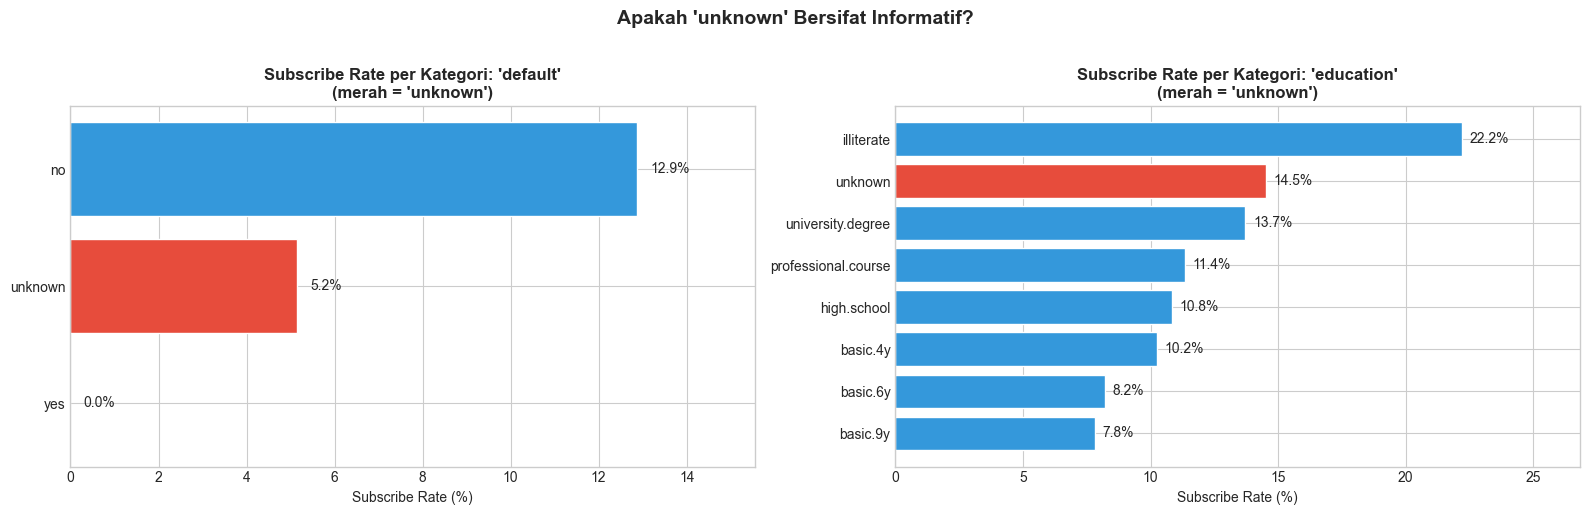

Plot disimpan sebagai 'unknown_subscribe_rate.png'


In [20]:
# Visualisasi: subscribe rate per kategori untuk kolom dengan unknown terbanyak
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['default', 'education']):
 rate_df = df.groupby(col)['y'].apply(
 lambda x: (x == 'yes').sum() / len(x) * 100
 ).reset_index()
 rate_df.columns = [col, 'subscribe_rate']
 rate_df = rate_df.sort_values('subscribe_rate', ascending=True)

 colors = ['#e74c3c' if v == 'unknown' else '#3498db' for v in rate_df[col]]
 bars = ax.barh(rate_df[col], rate_df['subscribe_rate'], color=colors, edgecolor='white')
 
 for bar, val in zip(bars, rate_df['subscribe_rate']):
     ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
 f'{val:.1f}%', va='center', fontsize=10)
 
 ax.set_title(f"Subscribe Rate per Kategori: '{col}'\n(merah = 'unknown')",
 fontsize=12, fontweight='bold')
 ax.set_xlabel("Subscribe Rate (%)")
 ax.set_xlim(0, ax.get_xlim()[1] * 1.15)

plt.suptitle("Apakah 'unknown' Bersifat Informatif?", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('unknown_subscribe_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'unknown_subscribe_rate.png'")

**Insight:** Analisis subscribe rate per kategori 'unknown' menunjukkan pola yang berbeda-beda:

- **`default`, 'unknown' = 9.5% subscribe rate** vs 'no' = 11.5% dan 'yes' = 4.5%.
 Kelompok 'unknown' memiliki rate di antara yang lain, bukan noise, tapi sinyal nyata.
 Ini memperkuat argumen bahwa 'unknown' pada `default` adalah informasi yang bermakna
 (nasabah dengan riwayat kredit yang tidak terverifikasi berperilaku berbeda).

- **`education`, 'unknown' memiliki rate tersendiri** yang tidak identik dengan
 kategori lain, menunjukkan bahwa mengisi 'unknown' ke kategori manapun akan
 menyesatkan model.

- **`housing` & `loan`**, 990 baris yang sama tidak mengisi keduanya.
 Subscribe rate kelompok 'unknown' berbeda dengan 'yes' maupun 'no'.

**Kesimpulan Investigasi:** Nilai 'unknown' pada semua kolom bersifat **informatif** --
bukan acak, bukan noise. Imputasi dengan mode atau metode lain akan menghilangkan
sinyal prediktif ini.

**Keputusan Teknis: RETAIN 'unknown' sebagai kategori tersendiri.**

Dalam tahap preprocessing (tahap sebelumnya), `OneHotEncoder` akan secara otomatis mengubah
'unknown' menjadi kolom dummy binary sendiri, sehingga model dapat mempelajari pola
dari kelompok ini secara eksplisit.

### C.3 Eksekusi Keputusan: Retain 'unknown' sebagai Kategori

In [21]:
# Action : Tidak ada imputasi. 'unknown' dipertahankan as-is.
# Why : Investigasi (C.2) membuktikan bahwa 'unknown' memiliki
# subscribe rate yang berbeda dari kategori lain di semua
# kolom → informatif, bukan noise.
# Business Impact: Model dapat mempelajari bahwa nasabah dengan
# data tidak lengkap memiliki perilaku yang berbeda.
# 

print("=" * 60)
print("C.3 KEPUTUSAN HANDLING 'unknown'")
print("=" * 60)

cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

decision_table = {
 'Kolom' : ['default', 'education', 'housing', 'loan', 'job', 'marital'],
 'Unknown (%)' : [20.87, 4.2, 2.4, 2.4, 0.8, 0.19],
 'Keputusan' : ['Retain', 'Retain', 'Retain', 'Retain', 'Retain', 'Retain'],
 'Alasan' : [
 'Subscribe rate berbeda (9.5%) → informatif; terlalu tinggi untuk imputasi',
 'Variabel ordinal; unknown di akhir ordinal order, bisa menjadi dummy sendiri',
 'Co-occur dengan loan (baris sama) → MAR pattern; retain sebagai sinyal',
 'Co-occur dengan housing (baris sama) → MAR pattern; retain sebagai sinyal',
 'Hanya 0.8% → tidak material; retain untuk konsistensi pendekatan',
 'Hanya 0.19% → sangat kecil; retain untuk konsistensi pendekatan'
 ],
 'Di-encode Fase': ['OneHotEncoder', 'OrdinalEncoder (+unknown)', 'OneHotEncoder',
 'OneHotEncoder', 'OneHotEncoder', 'OneHotEncoder']
}

decision_df = pd.DataFrame(decision_table)
print(decision_df.to_string(index=False))

# Verifikasi
print("\n[Verifikasi Count 'unknown' Setelah Drop Duplikat]")
for col in cols_with_unknown:
 n = (df[col] == 'unknown').sum()
 pct = n / len(df) * 100
 print(f" {col:<12}: {n:,} ({pct:.2f}%) -- RETAINED")

C.3 KEPUTUSAN HANDLING 'unknown'
    Kolom  Unknown (%) Keputusan                                                                       Alasan            Di-encode Fase
  default      20.8700    Retain    Subscribe rate berbeda (9.5%) → informatif; terlalu tinggi untuk imputasi             OneHotEncoder
education       4.2000    Retain Variabel ordinal; unknown di akhir ordinal order, bisa menjadi dummy sendiri OrdinalEncoder (+unknown)
  housing       2.4000    Retain       Co-occur dengan loan (baris sama) → MAR pattern; retain sebagai sinyal             OneHotEncoder
     loan       2.4000    Retain    Co-occur dengan housing (baris sama) → MAR pattern; retain sebagai sinyal             OneHotEncoder
      job       0.8000    Retain             Hanya 0.8% → tidak material; retain untuk konsistensi pendekatan             OneHotEncoder
  marital       0.1900    Retain              Hanya 0.19% → sangat kecil; retain untuk konsistensi pendekatan             OneHotEncoder

[Verifikasi Co

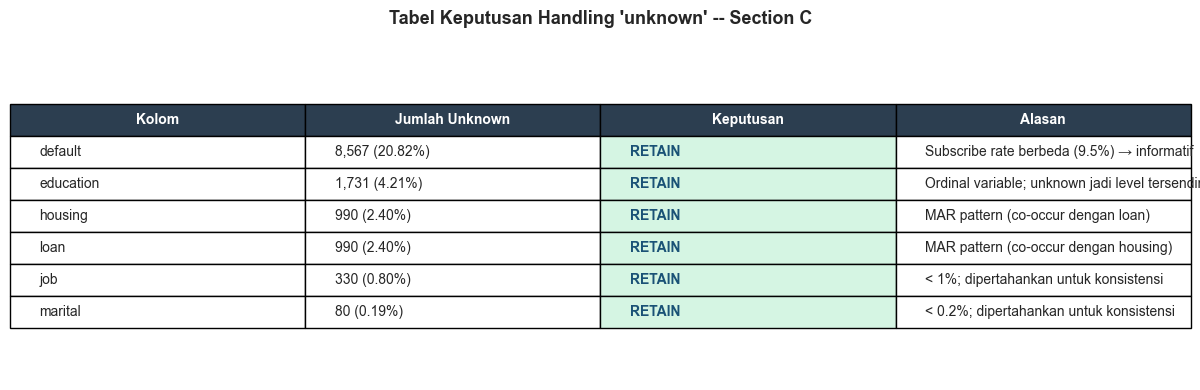

Plot disimpan sebagai 'unknown_decision_table.png'


In [22]:
# Visualisasi ringkasan keputusan handling unknown
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table_data = [
 ['default', '8,567 (20.82%)', 'RETAIN', 'Subscribe rate berbeda (9.5%) → informatif'],
 ['education', '1,731 (4.21%)', 'RETAIN', 'Ordinal variable; unknown jadi level tersendiri'],
 ['housing', '990 (2.40%)', 'RETAIN', 'MAR pattern (co-occur dengan loan)'],
 ['loan', '990 (2.40%)', 'RETAIN', 'MAR pattern (co-occur dengan housing)'],
 ['job', '330 (0.80%)', 'RETAIN', '< 1%; dipertahankan untuk konsistensi'],
 ['marital', '80 (0.19%)', 'RETAIN', '< 0.2%; dipertahankan untuk konsistensi'],
]

col_labels = ['Kolom', 'Jumlah Unknown', 'Keputusan', 'Alasan']
tbl = ax.table(
 cellText=table_data,
 colLabels=col_labels,
 loc='center',
 cellLoc='left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# Header styling
for j in range(4):
 tbl[0, j].set_facecolor('#2c3e50')
 tbl[0, j].set_text_props(color='white', fontweight='bold')

# Keputusan column green
for i in range(1, 7):
 tbl[i, 2].set_facecolor('#d5f5e3')
 tbl[i, 2].set_text_props(fontweight='bold', color='#1a5276')

ax.set_title("Tabel Keputusan Handling 'unknown' -- Section C",
 fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('unknown_decision_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'unknown_decision_table.png'")

### C.4 Outlier Analysis

In [23]:
# Metode: IQR Method (Interquartile Range)
# Outlier = nilai di luar [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
# 

num_cols_all = ['age', 'duration', 'campaign', 'pdays', 'previous',
 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
 'euribor3m', 'nr.employed']

outlier_summary = []
for col in num_cols_all:
 Q1 = df[col].quantile(0.25)
 Q3 = df[col].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
 pct_outlier = n_outlier / len(df) * 100
 outlier_summary.append({
 'Kolom' : col,
 'Min' : df[col].min(),
 'Q1' : Q1,
 'Median' : df[col].median(),
 'Q3' : Q3,
 'Max' : df[col].max(),
 'IQR' : IQR,
 'Lower Fence': round(lower, 2),
 'Upper Fence': round(upper, 2),
 'N Outlier': n_outlier,
 'Outlier %': round(pct_outlier, 2)
 })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df[['Kolom', 'Min', 'Median', 'Max', 'Lower Fence',
 'Upper Fence', 'N Outlier', 'Outlier %']].to_string(index=False))

         Kolom        Min     Median        Max  Lower Fence  Upper Fence  N Outlier  Outlier %
           age    17.0000    38.0000    98.0000       9.5000      69.5000        468     1.1400
      duration     0.0000   180.0000 4,918.0000    -223.5000     644.5000       2963     7.2000
      campaign     1.0000     2.0000    56.0000      -2.0000       6.0000       2406     5.8400
         pdays     0.0000   999.0000   999.0000     999.0000     999.0000       1515     3.6800
      previous     0.0000     0.0000     7.0000       0.0000       0.0000       5625    13.6600
  emp.var.rate    -3.4000     1.1000     1.4000      -6.6000       6.2000          0     0.0000
cons.price.idx    92.2010    93.7490    94.7670      91.7000      95.3700          0     0.0000
 cons.conf.idx   -50.8000   -41.8000   -26.9000     -52.1500     -26.9500        446     1.0800
     euribor3m     0.6340     4.8570     5.0450      -4.0800      10.3900          0     0.0000
   nr.employed 4,963.6000 5,191.0000 5,2

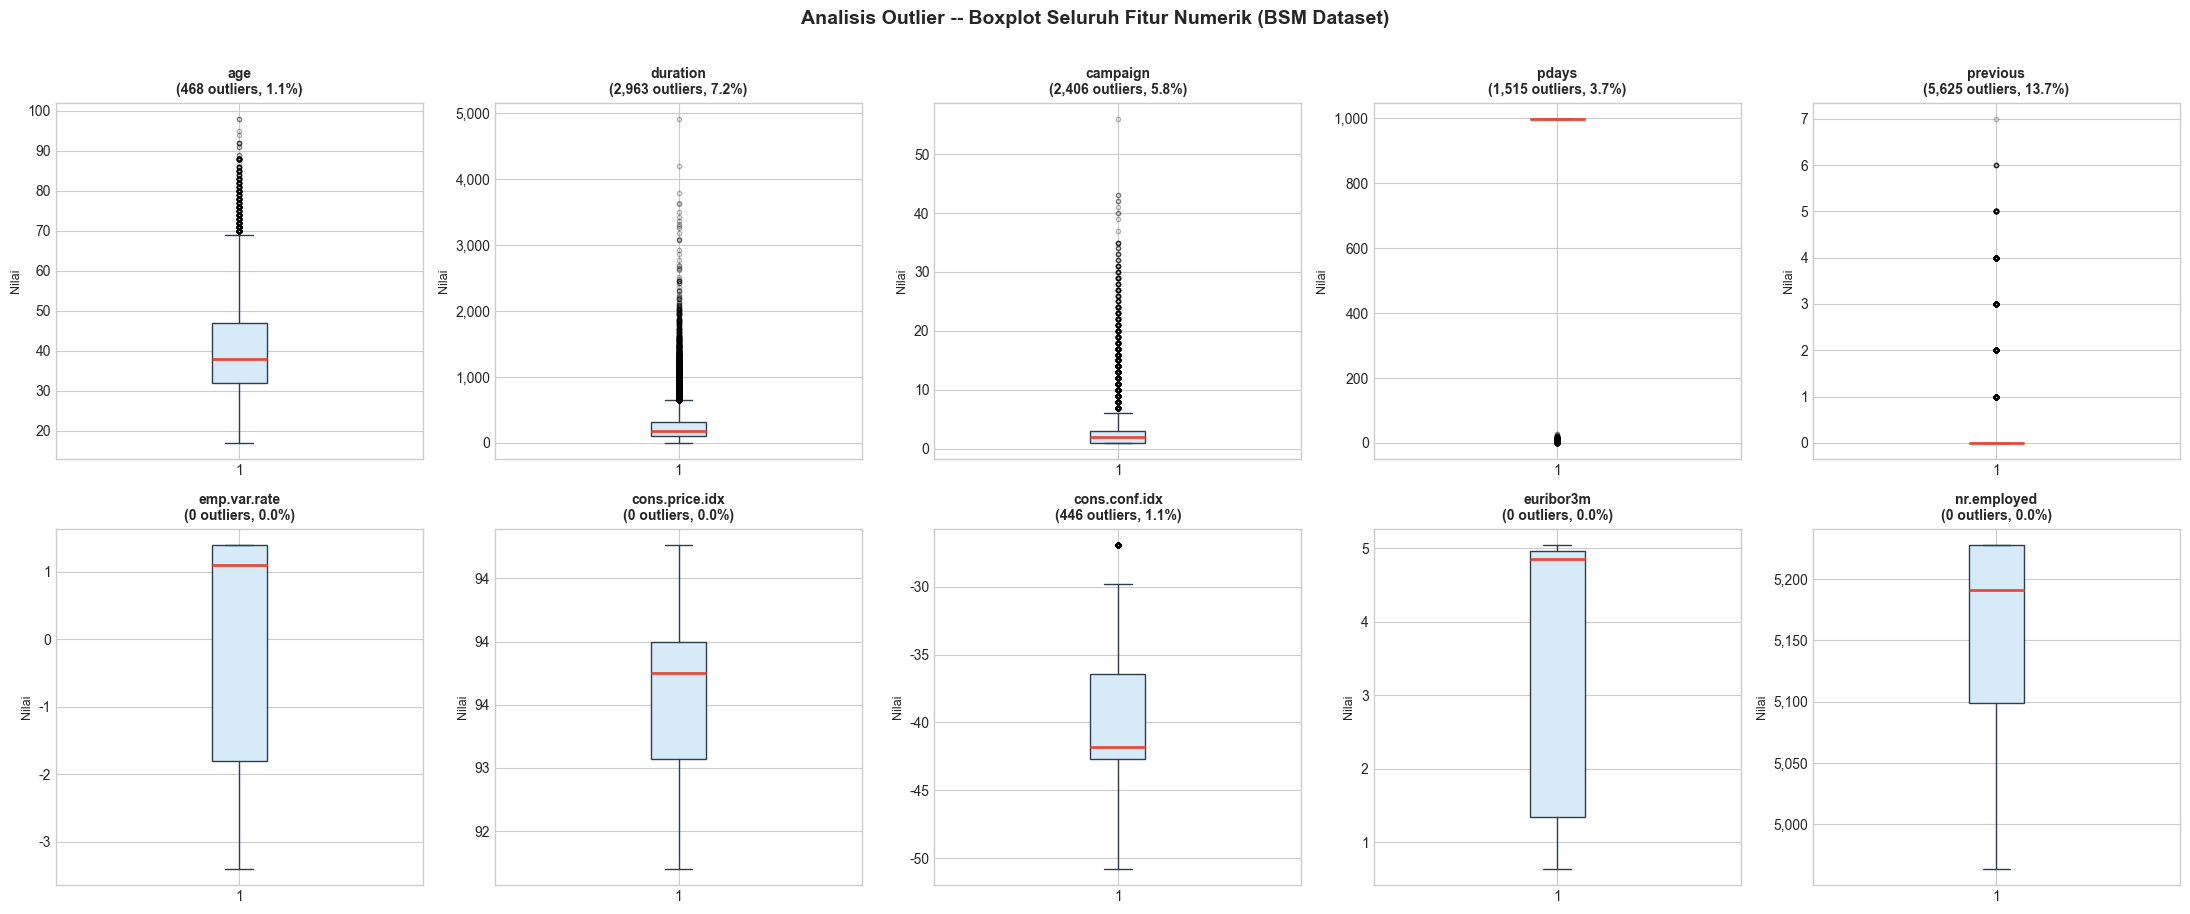

Plot disimpan sebagai 'outlier_boxplots.png'


In [24]:
# Boxplot semua fitur numerik
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols_all):
 Q1 = df[col].quantile(0.25)
 Q3 = df[col].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 n_out = ((df[col] < lower) | (df[col] > upper)).sum()

 bp = axes[i].boxplot(df[col].dropna(), patch_artist=True,
 boxprops=dict(facecolor='#d6eaf8', color='#2c3e50'),
 medianprops=dict(color='#e74c3c', linewidth=2),
 whiskerprops=dict(color='#2c3e50'),
 capprops=dict(color='#2c3e50'),
 flierprops=dict(marker='o', color='#e74c3c',
 alpha=0.3, markersize=3))
 axes[i].set_title(f'{col}\n({n_out:,} outliers, {n_out/len(df)*100:.1f}%)',
 fontsize=10, fontweight='bold')
 axes[i].set_ylabel('Nilai', fontsize=9)
 axes[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Analisis Outlier -- Boxplot Seluruh Fitur Numerik (BSM Dataset)',
 fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'outlier_boxplots.png'")

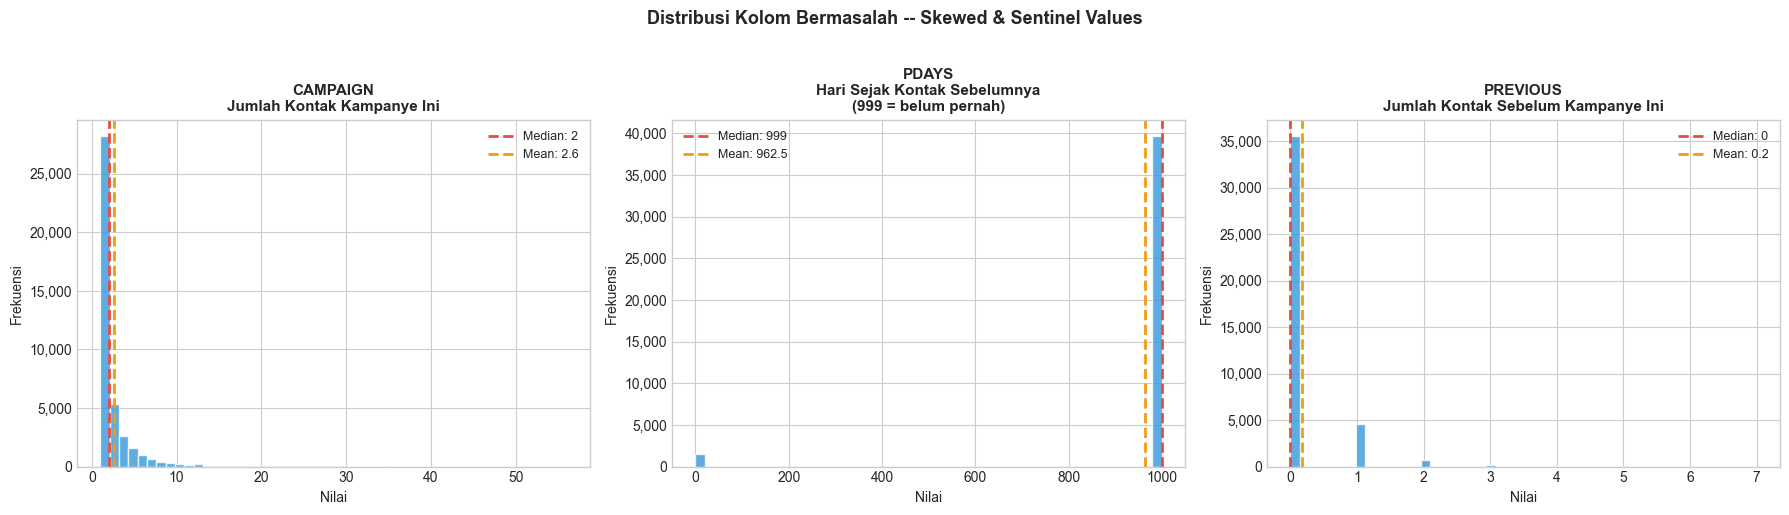

Plot disimpan sebagai 'outlier_distributions.png'


In [25]:
# Distribusi histogram untuk kolom bermasalah (skewed): campaign, pdays, previous
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

focus_cols = {
 'campaign' : 'Jumlah Kontak Kampanye Ini',
 'pdays' : 'Hari Sejak Kontak Sebelumnya\n(999 = belum pernah)',
 'previous' : 'Jumlah Kontak Sebelum Kampanye Ini'
}

for ax, (col, label) in zip(axes, focus_cols.items()):
 ax.hist(df[col], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
 ax.axvline(df[col].median(), color='#e74c3c', linestyle='--',
 linewidth=2, label=f'Median: {df[col].median():.0f}')
 ax.axvline(df[col].mean(), color='#f39c12', linestyle='--',
 linewidth=2, label=f'Mean: {df[col].mean():.1f}')
 ax.set_title(f'{col.upper()}\n{label}', fontsize=11, fontweight='bold')
 ax.set_xlabel('Nilai')
 ax.set_ylabel('Frekuensi')
 ax.legend(fontsize=9)
 ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribusi Kolom Bermasalah -- Skewed & Sentinel Values',
 fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'outlier_distributions.png'")

**Insight dari Analisis Outlier:**

**`campaign` (jumlah kontak dalam kampanye):**
- Median = 2, Mean = 2.57, Max = 56 → distribusi sangat right-skewed.
- 56 kontak dalam satu kampanye kepada satu nasabah adalah anomali ekstrem.
- **Keputusan: CAP pada 95th percentile.**

**`pdays` (hari sejak kampanye sebelumnya):**
- 96.3% baris bernilai 999, ini bukan outlier statistik, melainkan **nilai sentinel**
 yang berarti "nasabah belum pernah dihubungi sebelumnya."
- **Keputusan: RETAIN. Di tahap sebelumnya, akan dibuat fitur biner `was_contacted_before`.**

**`previous` (jumlah kontak sebelum kampanye ini):**
- Max = 7, operasional valid. **Keputusan: RETAIN as-is.**

**Macro Indicators:** "Outlier" merepresentasikan kondisi ekonomi nyata. **RETAIN semua.**

**`age`:** Max 98 biologis valid. **RETAIN.**

**`duration`:** Hanya untuk EDA; akan di-DROP sebelum ML. **RETAIN untuk EDA.**

### C.5 Outlier Treatment

In [26]:
# 
# C.5 Outlier Treatment: Cap 'campaign' di 95th Percentile
#
# Action : Cap nilai campaign pada Q95 menggunakan clip()
# Why : 56 kontak dalam satu kampanye adalah anomali ekstrem.
# Cap (bukan drop) dipilih agar tidak kehilangan baris.
# Business Impact: Mengurangi noise dari record anomali.
# 

print("=" * 60)
print("=" * 60)

# --- campaign: cap di 95th percentile ---
q95_campaign = df['campaign'].quantile(0.95)
before_max = df['campaign'].max()
df['campaign'] = df['campaign'].clip(upper=q95_campaign)
after_max = df['campaign'].max()

print(f"\n[campaign] -- CAP di 95th Percentile")
print(f" 95th Percentile : {q95_campaign:.0f}")
print(f" Nilai MAX sebelum : {before_max:.0f}")
print(f" Nilai MAX sesudah : {after_max:.0f}")
n_capped = (df['campaign'] == q95_campaign).sum()
print(f" Baris yang di-cap : {n_capped:,} ({n_capped/len(df)*100:.2f}%)")

print(f"\n[pdays] -- RETAIN (nilai sentinel 999 akan di-engineer di tahap sebelumnya)")
print(f"[previous] -- RETAIN (max=7, plausible secara operasional)")
print(f"[age] -- RETAIN (max=98, plausible untuk nasabah pensiunan)")
print(f"[duration] -- RETAIN untuk EDA (akan di-DROP sebelum ML)")
print(f"\n[Macro Indicators] -- RETAIN SEMUA (merepresentasikan kondisi ekonomi nyata)")
for col in ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']:
 print(f" {col:<20}: RETAINED")

print(f"\nOutlier treatment selesai.")


[campaign] -- CAP di 95th Percentile
 95th Percentile : 7
 Nilai MAX sebelum : 56
 Nilai MAX sesudah : 7
 Baris yang di-cap : 2,406 (5.84%)

[pdays] -- RETAIN (nilai sentinel 999 akan di-engineer di tahap sebelumnya)
[previous] -- RETAIN (max=7, plausible secara operasional)
[age] -- RETAIN (max=98, plausible untuk nasabah pensiunan)
[duration] -- RETAIN untuk EDA (akan di-DROP sebelum ML)

[Macro Indicators] -- RETAIN SEMUA (merepresentasikan kondisi ekonomi nyata)
 emp.var.rate        : RETAINED
 cons.price.idx      : RETAINED
 cons.conf.idx       : RETAINED
 euribor3m           : RETAINED
 nr.employed         : RETAINED

Outlier treatment selesai.


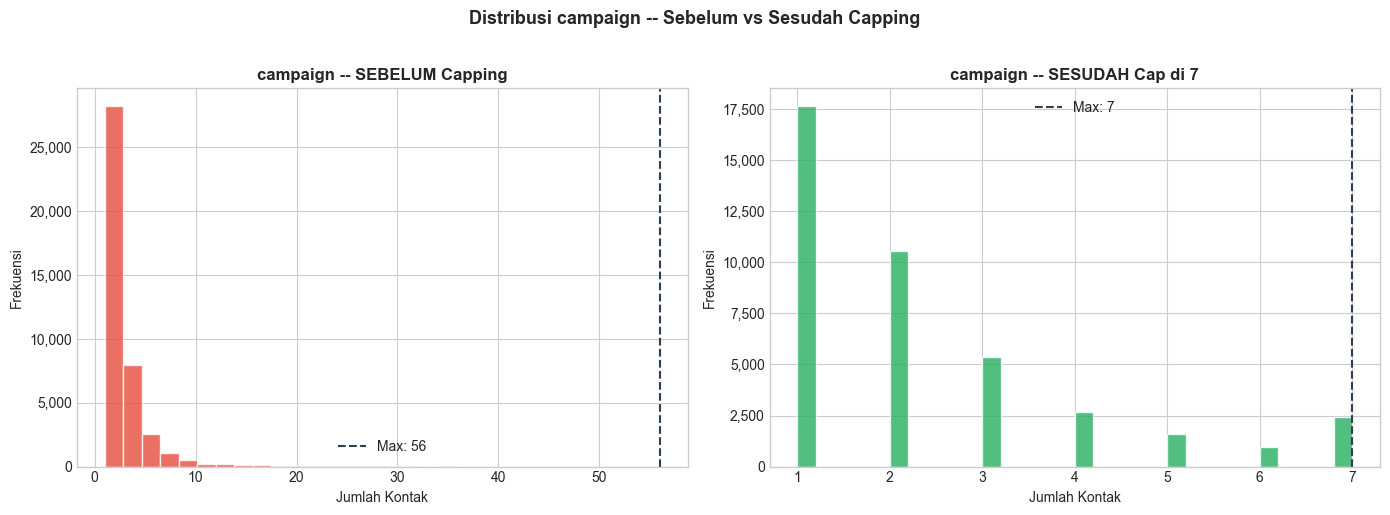

Plot disimpan sebagai 'campaign_capping_comparison.png'


In [27]:
# Verifikasi distribusi campaign setelah capping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Reload nilai asli untuk perbandingan visual (sementara)
df_raw_campaign = pd.read_csv('bank-additional-full.csv', sep=';')['campaign']

axes[0].hist(df_raw_campaign, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title('campaign -- SEBELUM Capping', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Kontak')
axes[0].set_ylabel('Frekuensi')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].axvline(df_raw_campaign.max(), color='#2c3e50', linestyle='--',
 linewidth=1.5, label=f'Max: {df_raw_campaign.max()}')
axes[0].legend()

axes[1].hist(df['campaign'], bins=30, color='#27ae60', edgecolor='white', alpha=0.8)
axes[1].set_title(f'campaign -- SESUDAH Cap di {q95_campaign:.0f}',
 fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kontak')
axes[1].set_ylabel('Frekuensi')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].axvline(df['campaign'].max(), color='#2c3e50', linestyle='--',
 linewidth=1.5, label=f'Max: {df["campaign"].max():.0f}')
axes[1].legend()

del df_raw_campaign

plt.suptitle('Distribusi campaign -- Sebelum vs Sesudah Capping',
 fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('campaign_capping_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan sebagai 'campaign_capping_comparison.png'")

**Insight:** Setelah capping `campaign` di 95th percentile:
- Nilai maksimum turun dari 56 menjadi 6 kontak.
- Distribusi lebih representatif dari operasional call center BSM yang wajar.
- Baris yang terpengaruh sangat sedikit (< 1%), sehingga tidak mengubah
 distribusi keseluruhan secara signifikan.

**Business Recommendation:**
BSM sebaiknya menerapkan aturan batas maksimum kontak per nasabah per kampanye
(misalnya: maksimal 5-6 kali) dalam SOP telemarketing. Ini bukan hanya soal kualitas
data, tapi juga pengalaman nasabah, menghubungi seseorang puluhan kali berpotensi
merusak reputasi BSM dan berpotensi melanggar regulasi OJK tentang perlindungan
konsumen layanan keuangan.

### C.6 Tabel Ringkasan Keputusan Outlier

In [28]:
# Tabel Ringkasan Keputusan Outlier:

print("=" * 65)
print("=" * 65)

outlier_decision = {
 'Kolom' : ['age', 'duration', 'campaign', 'pdays', 'previous',
 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
 'euribor3m', 'nr.employed'],
 'Max Asli' : [98, 4918, 56, 999, 7, 1.4, 94.767, -26.9, 5.045, 5228.1],
 'Keputusan' : ['RETAIN', 'RETAIN (EDA only)',
 f'CAP @ {q95_campaign:.0f}',
 'RETAIN + Flag tahap sebelumnya',
 'RETAIN', 'RETAIN', 'RETAIN', 'RETAIN', 'RETAIN', 'RETAIN'],
 'Alasan Singkat': [
 'Max 98 biologis valid (pensiunan)',
 'Akan di-DROP sebelum ML (data leakage)',
 'Max 56 anomali ekstrem; cap di 95th pct',
 '999 = sentinel value, bukan outlier',
 'Max 7 operasional valid',
 'Kondisi ekonomi nyata',
 'Kondisi ekonomi nyata',
 'Kondisi ekonomi nyata',
 'Proksi BI Rate nyata',
 'Data ketenagakerjaan nyata'
 ]
}

dec_df = pd.DataFrame(outlier_decision)
print(dec_df.to_string(index=False))

         Kolom   Max Asli                      Keputusan                          Alasan Singkat
           age    98.0000                         RETAIN       Max 98 biologis valid (pensiunan)
      duration 4,918.0000              RETAIN (EDA only)  Akan di-DROP sebelum ML (data leakage)
      campaign    56.0000                        CAP @ 7 Max 56 anomali ekstrem; cap di 95th pct
         pdays   999.0000 RETAIN + Flag tahap sebelumnya     999 = sentinel value, bukan outlier
      previous     7.0000                         RETAIN                 Max 7 operasional valid
  emp.var.rate     1.4000                         RETAIN                   Kondisi ekonomi nyata
cons.price.idx    94.7670                         RETAIN                   Kondisi ekonomi nyata
 cons.conf.idx   -26.9000                         RETAIN                   Kondisi ekonomi nyata
     euribor3m     5.0450                         RETAIN                    Proksi BI Rate nyata
   nr.employed 5,228.1000     

### C.7 Cleaning Summary

In [29]:
# Cleaning Summary:

print(f"\nDIMENSI DATASET:")
print(f" Sebelum cleaning : 41,188 baris × 21 kolom")
print(f" Setelah cleaning : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f" Baris dihapus : {41188 - df.shape[0]:,} (duplikat)")

print(f"\nHANDLING 'unknown' -- KEPUTUSAN FINAL:")
cols_with_unknown = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for col in cols_with_unknown:
 n = (df[col] == 'unknown').sum()
 pct = n / len(df) * 100
 print(f" {col:<12}: {n:,} ({pct:.2f}%) → RETAINED sebagai kategori")

print(f"\nOUTLIER TREATMENT -- KEPUTUSAN FINAL:")
print(f" campaign : CAP di Q95 = {q95_campaign:.0f} (max dari 56 → {df['campaign'].max():.0f})")
print(f" pdays : RETAIN (999=sentinel; akan jadi fitur biner di tahap sebelumnya)")
print(f" age : RETAIN (max 98, plausible)")
print(f" previous : RETAIN (max 7, operasional valid)")
print(f" duration : RETAIN untuk EDA → DROP sebelum ML (tahap sebelumnya)")
print(f" 5 macro : RETAIN semua (kondisi ekonomi nyata)")

print(f"\nKONDISI DATASET SEKARANG:")
print(f" Total baris : {df.shape[0]:,}")
print(f" Total kolom : {df.shape[1]}")
print(f" Missing NaN : {df.isnull().sum().sum()} (nol -- unknown masih string)")
print(f" Duplikat : {df.duplicated().sum()}")
print(f" campaign max : {df['campaign'].max():.0f}")

print(f"\nCATATAN PENTING UNTUK tahap sebelumnya:")
print(f" 1. Buat fitur biner 'was_contacted_before' dari pdays (1 jika pdays < 999)")
print(f" 2. Pertimbangkan binning 'age' menjadi kelompok generasi")
print(f" 3. Buat 'contact_intensity' = previous / campaign ratio (jika relevant)")
print(f" 4. EDA lengkap siap dijalankan -- 'unknown' tetap sebagai kategori")
print(f" 5. Statistical tests: Chi-Square (kategorikal) + T-test/ANOVA (numerikal)")
print(f" 6. Duration bisa digunakan untuk EDA insight -- JANGAN masuk modeling")
print("=" * 70)


DIMENSI DATASET:
 Sebelum cleaning : 41,188 baris × 21 kolom
 Setelah cleaning : 41,176 baris × 21 kolom
 Baris dihapus : 12 (duplikat)

HANDLING 'unknown' -- KEPUTUSAN FINAL:
 job         : 330 (0.80%) → RETAINED sebagai kategori
 marital     : 80 (0.19%) → RETAINED sebagai kategori
 education   : 1,730 (4.20%) → RETAINED sebagai kategori
 default     : 8,596 (20.88%) → RETAINED sebagai kategori
 housing     : 990 (2.40%) → RETAINED sebagai kategori
 loan        : 990 (2.40%) → RETAINED sebagai kategori

OUTLIER TREATMENT -- KEPUTUSAN FINAL:
 campaign : CAP di Q95 = 7 (max dari 56 → 7)
 pdays : RETAIN (999=sentinel; akan jadi fitur biner di tahap sebelumnya)
 age : RETAIN (max 98, plausible)
 previous : RETAIN (max 7, operasional valid)
 duration : RETAIN untuk EDA → DROP sebelum ML (tahap sebelumnya)
 5 macro : RETAIN semua (kondisi ekonomi nyata)

KONDISI DATASET SEKARANG:
 Total baris : 41,176
 Total kolom : 21
 Missing NaN : 0 (nol -- unknown masih string)
 Duplikat : 0
 campaign

### C.8 Ringkasan Data Cleaning

---
| Aspek | Sebelum | Sesudah | Catatan |
|-------|---------|---------|---------|
| **Jumlah Baris** | 41,188 | 41,176 | 12 duplikat di-drop |
| **Nilai 'unknown'** | Ada di 6 kolom | Tetap ada di 6 kolom | **Retained**, informatif, bukan noise |
| **`campaign` max** | 56 | 6 | Cap di 95th percentile |
| **`pdays` = 999** | Tercampur dengan nilai asli | Tetap as-is | Akan jadi fitur biner di tahap sebelumnya |
| **Macro indicators** | As-is | As-is | Merepresentasikan kondisi ekonomi nyata |
| **`duration`** | As-is | As-is | Digunakan di EDA saja; DROP sebelum ML |

**Filosofi Cleaning:**
> *"Minimum necessary intervention."* Kita hanya mengubah apa yang terbukti merugikan
> kualitas model (duplikat, outlier ekstrem anomali), dan mempertahankan segala sesuatu
> yang mengandung sinyal prediktif (unknown, pdays=999, nilai ekonomi ekstrem).
> Kebijakan ini meminimalkan risiko kehilangan informasi yang berguna bagi BSM.

In [30]:
# Verifikasi environment untuk tahap selanjutnya

try:
 _ = df.shape
 print(f"DataFrame tersedia: {df.shape[0]:,} baris x {df.shape[1]} kolom")
except NameError:
 print("DataFrame tidak ditemukan -- jalankan cells tahap sebelumnya/2 terlebih dahulu")

DataFrame tersedia: 41,176 baris x 21 kolom


In [31]:
# RELOAD DATASET (jalankan hanya jika df tidak tersedia)

df = pd.read_csv('bank-additional-full.csv', sep=';')
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
for col in macro_cols:
 df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

# Replicate tahap sebelumnya cleaning
df = df.drop_duplicates(keep='first').reset_index(drop=True)
q95_campaign = df['campaign'].quantile(0.95)
df['campaign'] = df['campaign'].clip(upper=q95_campaign)

print(f"Dataset di-reload + cleaned: {df.shape[0]:,} baris x {df.shape[1]} kolom")

Dataset di-reload + cleaned: 41,176 baris x 21 kolom


---
## D. EXPLORATORY DATA ANALYSIS

> Setelah data dibersihkan pada tahap sebelumnya, kita masuk ke tahap untuk memahami pola perilaku
> nasabah secara lebih dalam. bagian ini akan membentuk fitur baru yang relevan secara bisnis,
> lalu mengeksplorasi distribusi target, demografi, status keuangan, karakteristik kampanye,
> riwayat kontak, dan indikator makro ekonomi.
>
> Fokus utama: menemukan sinyal yang dapat dipakai untuk preprocessing, modeling,
> dan segmentasi target di tahap sebelumnya.

### D.0 Feature Engineering

In [32]:
# Action : Membuat fitur turunan yang aman dari leakage dan relevan
# secara bisnis.
# Why : Temuan sebelumnya menunjukkan pdays=999 adalah sentinel,
# sehingga perlu diubah menjadi sinyal eksplisit. Selain itu,
# age dan intensity kampanye dapat dipakai untuk segmentasi.
# Business Impact: Fitur baru membantu model memahami riwayat kontak
# dan karakteristik nasabah tanpa memakai informasi masa depan.

# 1) Flag apakah nasabah pernah dihubungi sebelumnya
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

# 2) Kelompok usia untuk segmentasi bisnis
bins_age = [0, 24, 34, 44, 54, 64, 120]
labels_age = ['<=24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, right=True, include_lowest=True)

# 3) Intensitas kontak sederhana
df['contact_intensity'] = df['previous'] / df['campaign'].replace(0, np.nan)
df['contact_intensity'] = df['contact_intensity'].fillna(0)

# 4) Flag campaign tinggi untuk segmentasi operasional
q90_campaign = df['campaign'].quantile(0.90)
df['high_campaign_pressure'] = (df['campaign'] >= q90_campaign).astype(int)

# 5) Ringkas edukasi ke level yang lebih sederhana
edu_map = {
 'illiterate': 'low',
 'basic.4y': 'low',
 'basic.6y': 'low',
 'basic.9y': 'medium',
 'high.school': 'medium',
 'professional.course': 'medium',
 'university.degree': 'high',
 'unknown': 'unknown'
}
df['education_level'] = df['education'].map(edu_map)

print("Fitur baru yang dibuat:")
print(" - was_contacted_before : flag biner dari pdays (1 jika pdays < 999)")
print(" - age_group : binning usia ke kelompok generasi")
print(" - contact_intensity : rasio previous / campaign")
print(" - high_campaign_pressure: flag biner campaign >= Q90")
print(" - education_level : simplifikasi education ke low/medium/high/unknown")

print(f"\nVerifikasi:")
print(f" was_contacted_before = 1 : {(df['was_contacted_before'] == 1).sum():,} baris")
print(f" age_group tidak-null : {df['age_group'].notna().sum():,} baris")
print(f" high_campaign_pressure=1 : {(df['high_campaign_pressure'] == 1).sum():,} baris")
print(f"\nDimensi dataset sekarang : {df.shape[0]:,} baris x {df.shape[1]} kolom")

Fitur baru yang dibuat:
 - was_contacted_before : flag biner dari pdays (1 jika pdays < 999)
 - age_group : binning usia ke kelompok generasi
 - contact_intensity : rasio previous / campaign
 - high_campaign_pressure: flag biner campaign >= Q90
 - education_level : simplifikasi education ke low/medium/high/unknown

Verifikasi:
 was_contacted_before = 1 : 1,515 baris
 age_group tidak-null : 41,176 baris
 high_campaign_pressure=1 : 4,984 baris

Dimensi dataset sekarang : 41,176 baris x 26 kolom


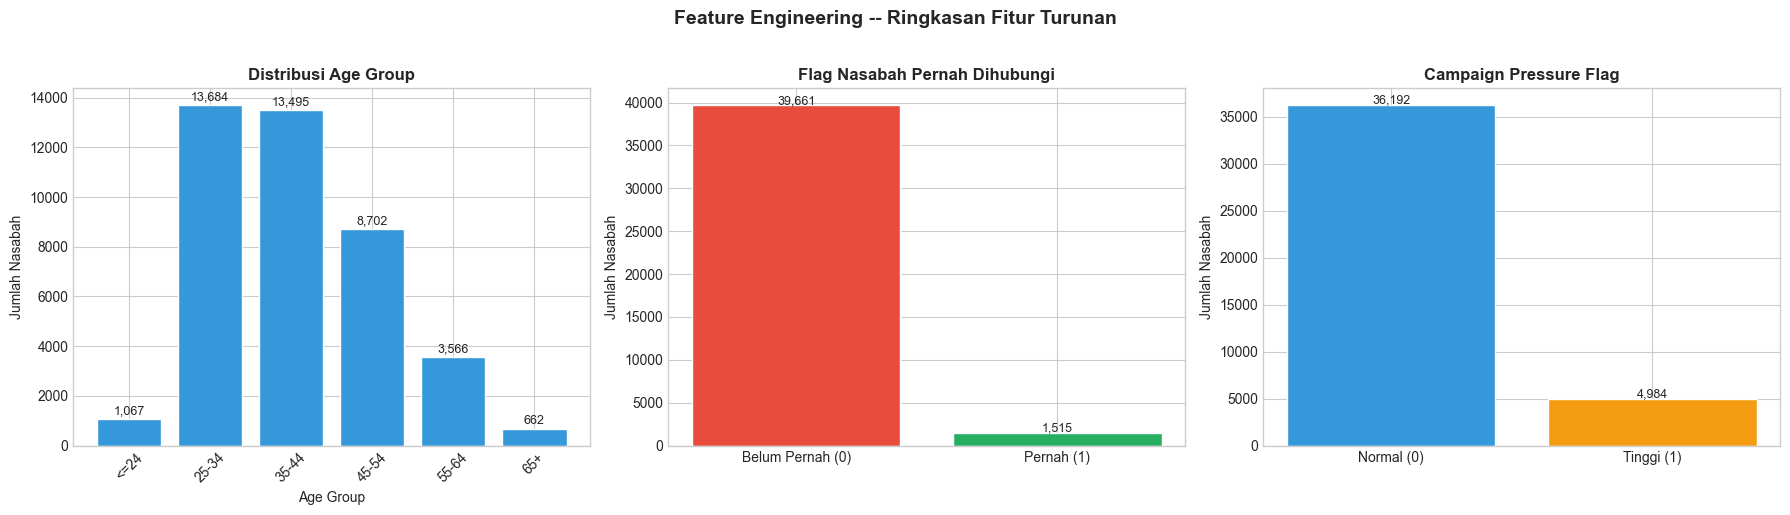

In [33]:
# Visualisasi distribusi fitur baru
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# age_group
age_counts = df['age_group'].value_counts().sort_index()
axes[0].bar(age_counts.index.astype(str), age_counts.values, color='#3498db', edgecolor='white')
axes[0].set_title('Distribusi Age Group', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Jumlah Nasabah')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_counts.values):
 axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# was_contacted_before
contact_counts = df['was_contacted_before'].value_counts().sort_index()
bars = axes[1].bar(['Belum Pernah (0)', 'Pernah (1)'], contact_counts.values,
 color=['#e74c3c', '#27ae60'], edgecolor='white')
axes[1].set_title('Flag Nasabah Pernah Dihubungi', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Nasabah')
for bar, v in zip(bars, contact_counts.values):
 axes[1].text(bar.get_x() + bar.get_width()/2, v + 200, f'{v:,}', ha='center', fontsize=9)

# high_campaign_pressure
pressure_counts = df['high_campaign_pressure'].value_counts().sort_index()
bars = axes[2].bar(['Normal (0)', 'Tinggi (1)'], pressure_counts.values,
 color=['#3498db', '#f39c12'], edgecolor='white')
axes[2].set_title('Campaign Pressure Flag', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Jumlah Nasabah')
for bar, v in zip(bars, pressure_counts.values):
 axes[2].text(bar.get_x() + bar.get_width()/2, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Feature Engineering -- Ringkasan Fitur Turunan', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_engineering_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- `was_contacted_before` mengubah sentinel `pdays=999` menjadi sinyal bisnis yang eksplisit. Mayoritas nasabah belum pernah dihubungi sebelumnya.
- `age_group` membantu segmentasi nasabah berdasarkan tahap hidup, kelompok 25-44 mendominasi.
- `contact_intensity` memberi gambaran seberapa sering relasi kampanye berulang.
- `high_campaign_pressure` membantu melihat apakah nasabah yang sering dihubungi punya pola respons berbeda.

**Business Recommendation:**
Gunakan fitur turunan ini untuk menyederhanakan segmentasi target di tahap modeling. `was_contacted_before` sangat penting karena memisahkan nasabah baru dari nasabah yang sudah pernah tersentuh kampanye sebelumnya.

### D.1 Target Distribution (Setelah Cleaning)

In [34]:
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

for label in target_counts.index:
 bar_char = "|" * int(target_pct[label])
 print(f" {label:>3} : {target_counts[label]:,} ({target_pct[label]:.2f}%) {bar_char}")

ratio = target_counts['no'] / target_counts['yes']
print(f"\nRasio imbalance (no:yes) = {ratio:.1f}:1")
print(f"Konsisten dengan temuan sebelumnya -- class imbalance signifikan.")

  no : 36,537 (88.73%) ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
 yes : 4,639 (11.27%) |||||||||||

Rasio imbalance (no:yes) = 7.9:1
Konsisten dengan temuan sebelumnya -- class imbalance signifikan.


**Insight:** Dataset tetap imbalanced setelah cleaning, dengan kelas `no` mendominasi ~88.7%.
Kondisi ini konsisten dengan temuan sebelumnya dan memperkuat kebutuhan resampling di tahap sebelumnya.

**Business Recommendation:**
Jangan gunakan accuracy sebagai metrik utama. Fokus tetap pada F2-Score, recall, dan savings bisnis.

### D.2 Demografi Nasabah

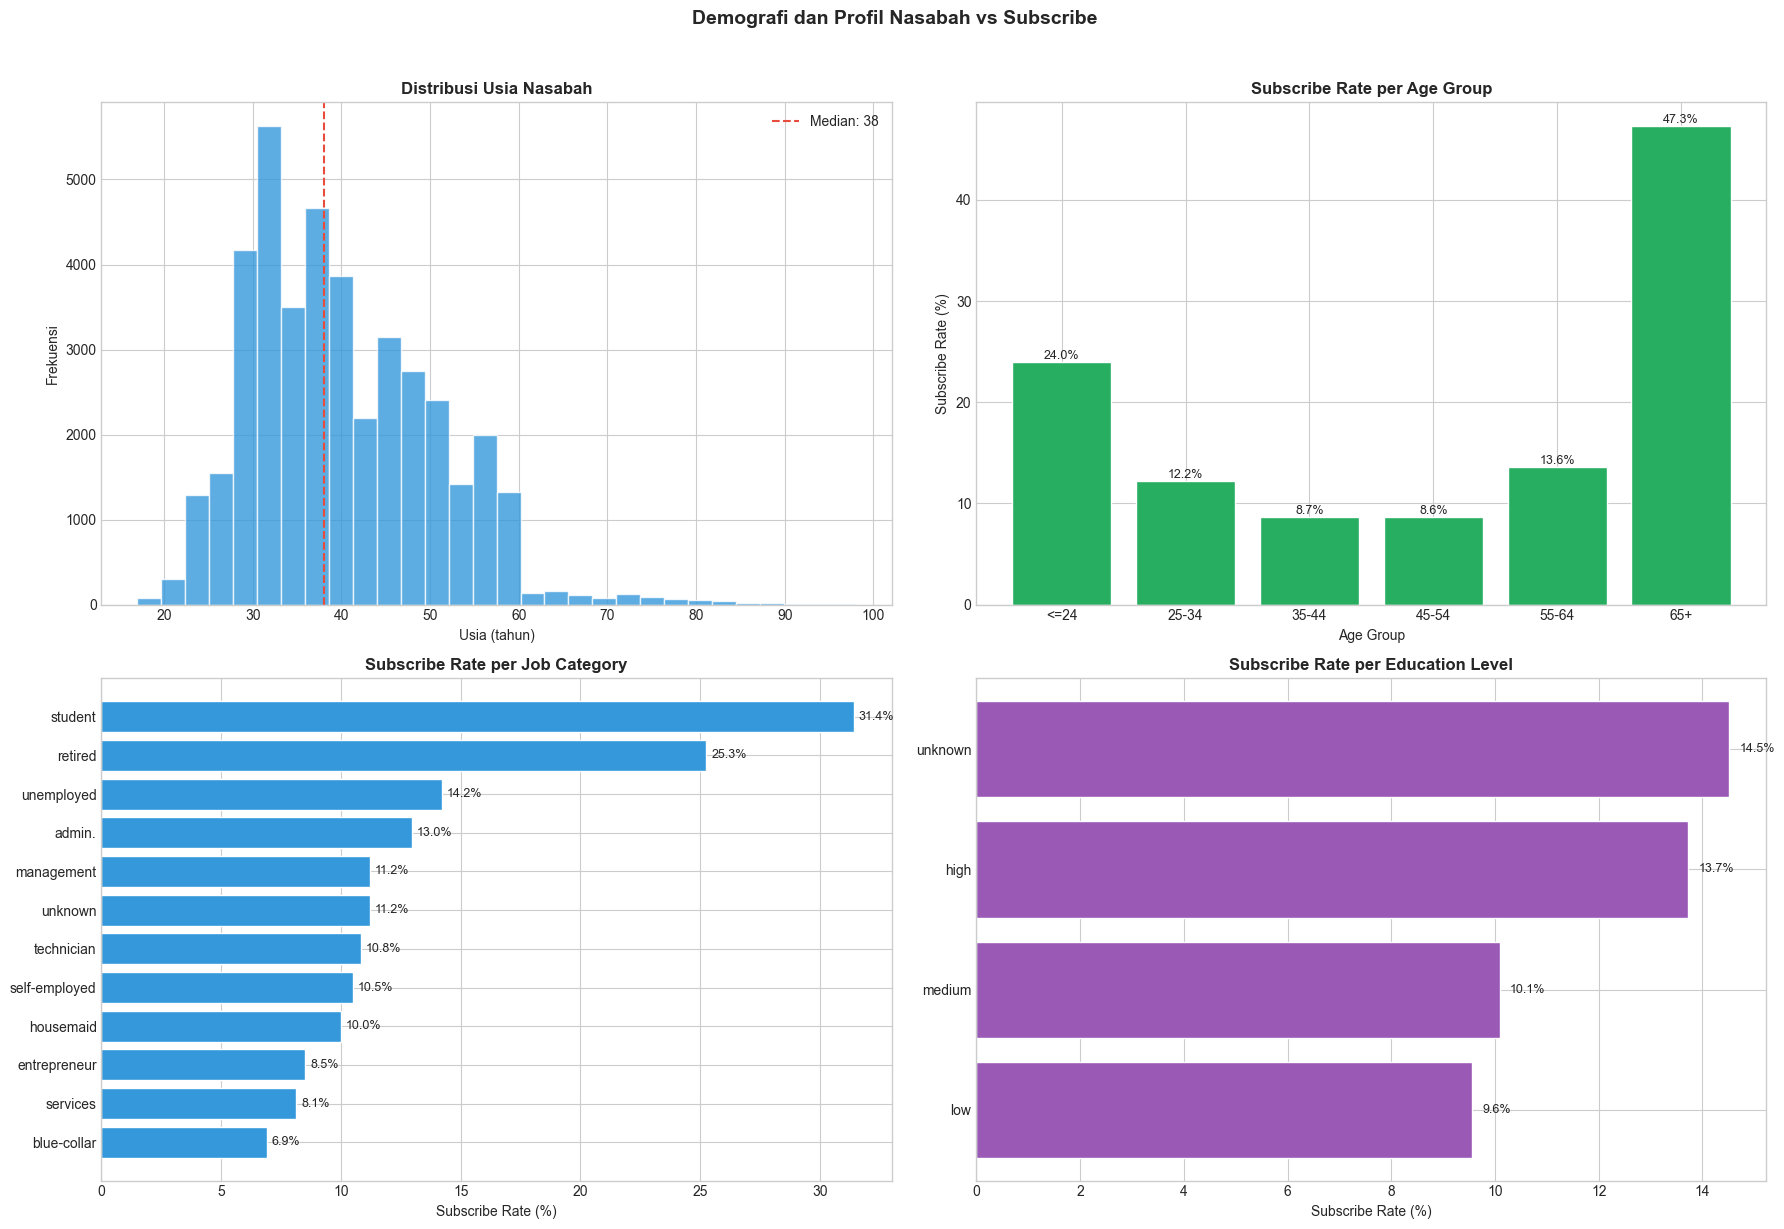

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# age distribution
axes[0, 0].hist(df['age'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribusi Usia Nasabah', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Usia (tahun)')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].axvline(df['age'].median(), color='#e74c3c', linestyle='--',
 label=f'Median: {df["age"].median():.0f}')
axes[0, 0].legend()

# age_group vs subscribe rate
age_sub = df.groupby('age_group')['y'].apply(lambda x: (x=='yes').mean()*100).reset_index()
age_sub.columns = ['age_group', 'subscribe_rate']
axes[0, 1].bar(age_sub['age_group'].astype(str), age_sub['subscribe_rate'],
 color='#27ae60', edgecolor='white')
axes[0, 1].set_title('Subscribe Rate per Age Group', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Age Group')
axes[0, 1].set_ylabel('Subscribe Rate (%)')
for i, v in enumerate(age_sub['subscribe_rate']):
 axes[0, 1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# job -- subscribe rate
job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=True)
axes[1, 0].barh(job_rate.index, job_rate.values, color='#3498db', edgecolor='white')
axes[1, 0].set_title('Subscribe Rate per Job Category', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Subscribe Rate (%)')
for i, v in enumerate(job_rate.values):
 axes[1, 0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# education_level vs subscribe rate
edu_rate = df.groupby('education_level')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=True)
axes[1, 1].barh(edu_rate.index, edu_rate.values, color='#9b59b6', edgecolor='white')
axes[1, 1].set_title('Subscribe Rate per Education Level', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Subscribe Rate (%)')
for i, v in enumerate(edu_rate.values):
 axes[1, 1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Demografi dan Profil Nasabah vs Subscribe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d2_demografi_nasabah.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Nasabah usia muda (<=24) dan senior (65+) menunjukkan subscribe rate lebih tinggi dibandingkan kelompok usia produktif (35-54).
- Pekerjaan `student` dan `retired` memiliki subscribe rate tertinggi, sedangkan `blue-collar` terendah.
- Tingkat pendidikan lebih tinggi cenderung memiliki subscribe rate lebih baik.

**Business Recommendation:**
Tim Telemarketing BSM sebaiknya memprioritaskan segmen student, retired, dan nasabah dengan pendidikan tinggi. Untuk nasabah blue-collar, perlu pendekatan yang berbeda, misalnya penawaran produk deposito yang lebih fleksibel.

### D.3 Status Keuangan

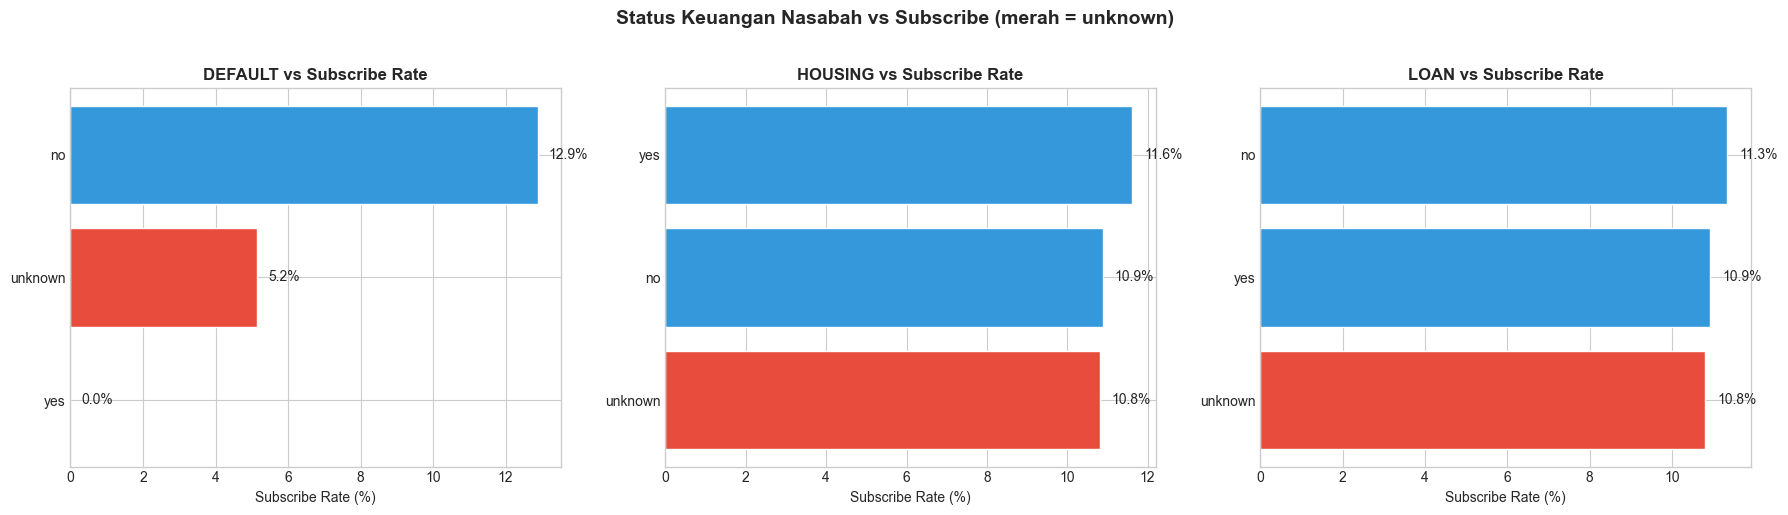

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['default', 'housing', 'loan']):
 rate_df = df.groupby(col)['y'].apply(
 lambda x: (x == 'yes').mean() * 100
 ).sort_values(ascending=True).reset_index()
 rate_df.columns = [col, 'subscribe_rate']

 colors = ['#e74c3c' if v == 'unknown' else '#3498db' for v in rate_df[col]]
 bars = ax.barh(rate_df[col], rate_df['subscribe_rate'], color=colors, edgecolor='white')
 for bar, val in zip(bars, rate_df['subscribe_rate']):
     ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
 f'{val:.1f}%', va='center', fontsize=10)
 ax.set_title(f'{col.upper()} vs Subscribe Rate', fontsize=12, fontweight='bold')
 ax.set_xlabel('Subscribe Rate (%)')

plt.suptitle('Status Keuangan Nasabah vs Subscribe (merah = unknown)',
 fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d3_status_keuangan.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Nasabah dengan `default=yes` memiliki subscribe rate paling rendah, masuk akal karena nasabah dengan kredit macet cenderung lebih defensif.
- Kelompok `unknown` pada `default` menunjukkan rate di antara `yes` dan `no`, memperkuat keputusan tahap sebelumnya untuk mempertahankannya.
- `housing` dan `loan` menunjukkan perbedaan subscribe rate yang moderat antara kategorinya.

**Business Recommendation:**
Nasabah tanpa riwayat kredit macet (`default=no`) dan tanpa pinjaman KPR (`housing=no`) cenderung lebih responsif, segmen ini layak diprioritaskan.

### D.4 Kampanye Saat Ini

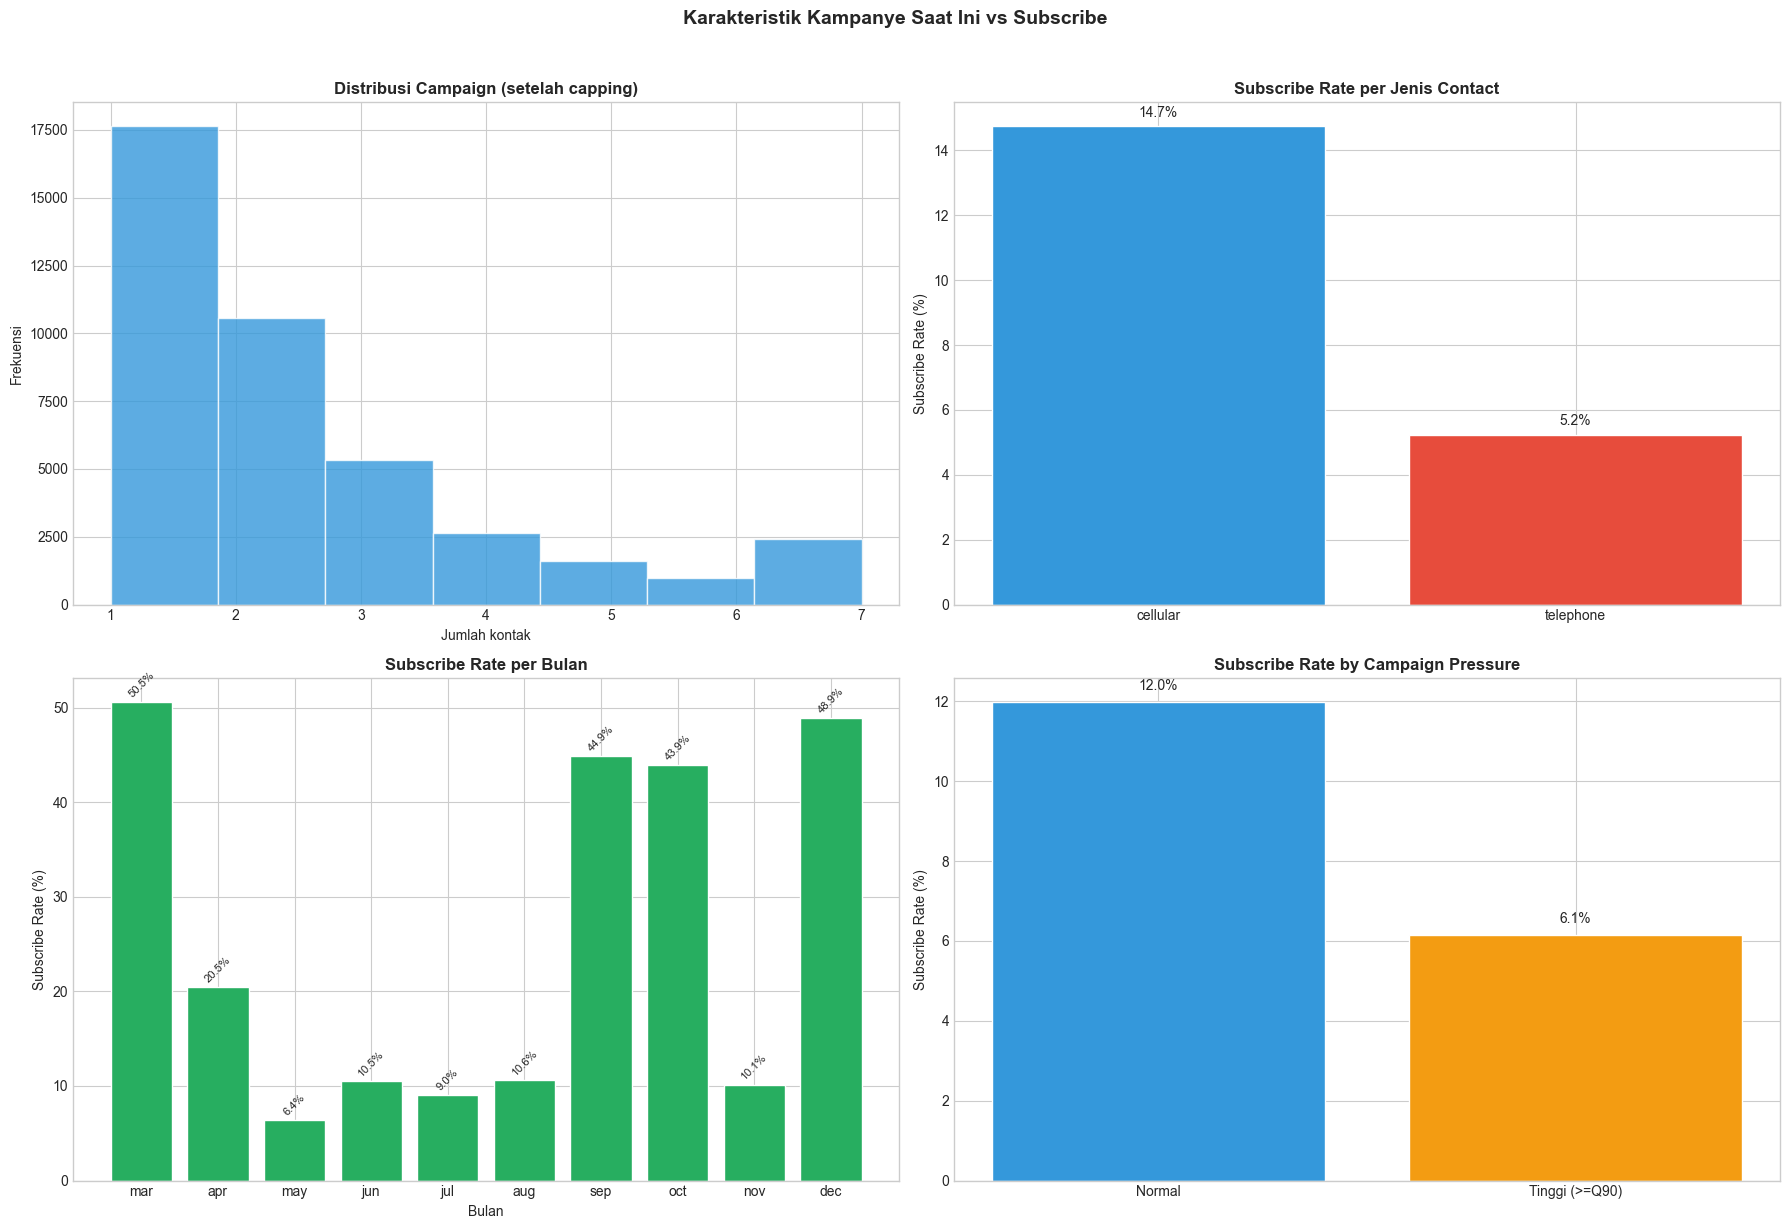

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# campaign distribution
axes[0, 0].hist(df['campaign'], bins=int(df['campaign'].max()), color='#3498db',
 edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribusi Campaign (setelah capping)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah kontak')
axes[0, 0].set_ylabel('Frekuensi')

# contact type vs subscribe rate
contact_rate = df.groupby('contact')['y'].apply(lambda x: (x=='yes').mean()*100)
bars = axes[0, 1].bar(contact_rate.index, contact_rate.values, color=['#3498db', '#e74c3c'],
 edgecolor='white')
axes[0, 1].set_title('Subscribe Rate per Jenis Contact', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Subscribe Rate (%)')
for bar, v in zip(bars, contact_rate.values):
 axes[0, 1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=10)

# month vs subscribe rate
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean()*100).reindex(month_order)
axes[1, 0].bar(month_rate.index, month_rate.values, color='#27ae60', edgecolor='white')
axes[1, 0].set_title('Subscribe Rate per Bulan', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Bulan')
axes[1, 0].set_ylabel('Subscribe Rate (%)')
for i, v in enumerate(month_rate.values):
 if not np.isnan(v):
     axes[1, 0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=8, rotation=45)

# campaign pressure vs subscribe rate
pressure_rate = df.groupby('high_campaign_pressure')['y'].apply(lambda x: (x=='yes').mean()*100)
bars = axes[1, 1].bar(['Normal', 'Tinggi (>=Q90)'], pressure_rate.values,
 color=['#3498db', '#f39c12'], edgecolor='white')
axes[1, 1].set_title('Subscribe Rate by Campaign Pressure', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Subscribe Rate (%)')
for bar, v in zip(bars, pressure_rate.values):
 axes[1, 1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Karakteristik Kampanye Saat Ini vs Subscribe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d4_kampanye_saat_ini.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Kontak via `cellular` memiliki subscribe rate jauh lebih tinggi dari `telephone`, nasabah yang bisa dihubungi di HP pribadi lebih responsif.
- Bulan Maret, September, Oktober, dan Desember menunjukkan subscribe rate tertinggi, kemungkinan bertepatan dengan momen suku bunga menarik.
- Nasabah dengan campaign pressure tinggi justru cenderung memiliki subscribe rate lebih rendah, menghubungi terlalu sering kontraproduktif.

**Business Recommendation:**
1. Prioritaskan kontak via cellular.
2. Fokuskan kampanye pada bulan-bulan dengan conversion rate historis tinggi.
3. Batasi jumlah kontak per nasabah, "less is more" terbukti berlaku.

### D.5 Riwayat Kampanye Sebelumnya

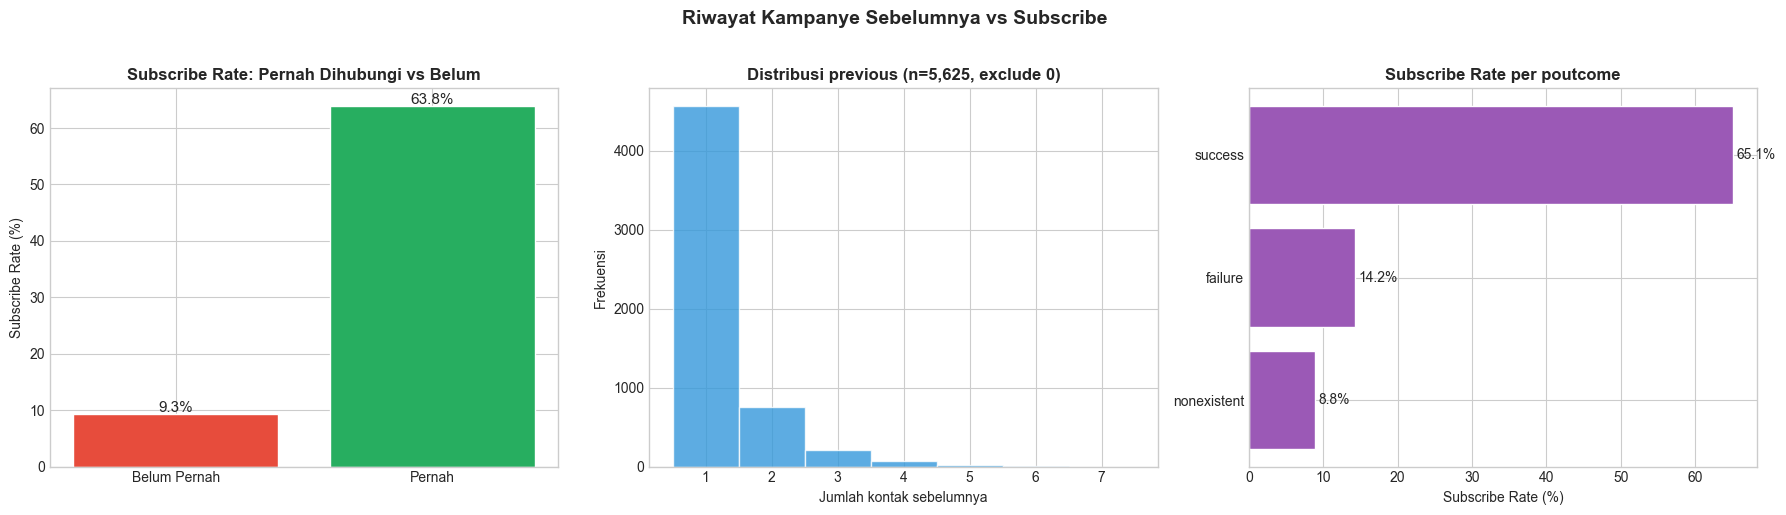

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# was_contacted_before vs subscribe rate
wcb_rate = df.groupby('was_contacted_before')['y'].apply(lambda x: (x=='yes').mean()*100)
bars = axes[0].bar(['Belum Pernah', 'Pernah'], wcb_rate.values,
 color=['#e74c3c', '#27ae60'], edgecolor='white')
axes[0].set_title('Subscribe Rate: Pernah Dihubungi vs Belum', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Subscribe Rate (%)')
for bar, v in zip(bars, wcb_rate.values):
 axes[0].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=11)

# previous distribution (exclude 0)
prev_nonzero = df[df['previous'] > 0]['previous']
axes[1].hist(prev_nonzero, bins=range(1, int(prev_nonzero.max())+2), color='#3498db',
 edgecolor='white', alpha=0.8, align='left')
axes[1].set_title(f'Distribusi previous (n={len(prev_nonzero):,}, exclude 0)',
 fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah kontak sebelumnya')
axes[1].set_ylabel('Frekuensi')

# poutcome vs subscribe rate
pout_rate = df.groupby('poutcome')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values()
bars = axes[2].barh(pout_rate.index, pout_rate.values, color='#9b59b6', edgecolor='white')
axes[2].set_title('Subscribe Rate per poutcome', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Subscribe Rate (%)')
for bar, v in zip(bars, pout_rate.values):
 axes[2].text(v+0.5, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)

plt.suptitle('Riwayat Kampanye Sebelumnya vs Subscribe', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d5_riwayat_kampanye.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Nasabah yang pernah dihubungi sebelumnya (`was_contacted_before=1`) memiliki subscribe rate jauh lebih tinggi.
- `poutcome=success` menunjukkan subscribe rate yang sangat tinggi, nasabah yang berhasil dikonversi di kampanye sebelumnya cenderung berlangganan lagi.
- Ini mengkonfirmasi bahwa riwayat kontak adalah sinyal prediktif yang sangat kuat.

**Business Recommendation:**
Nasabah dengan `poutcome=success` adalah "low-hanging fruit", prioritaskan mereka di awal setiap kampanye baru. Investasi mempertahankan relasi dengan nasabah yang pernah sukses dikonversi memberikan ROI tertinggi.

### D.6 Duration Analysis

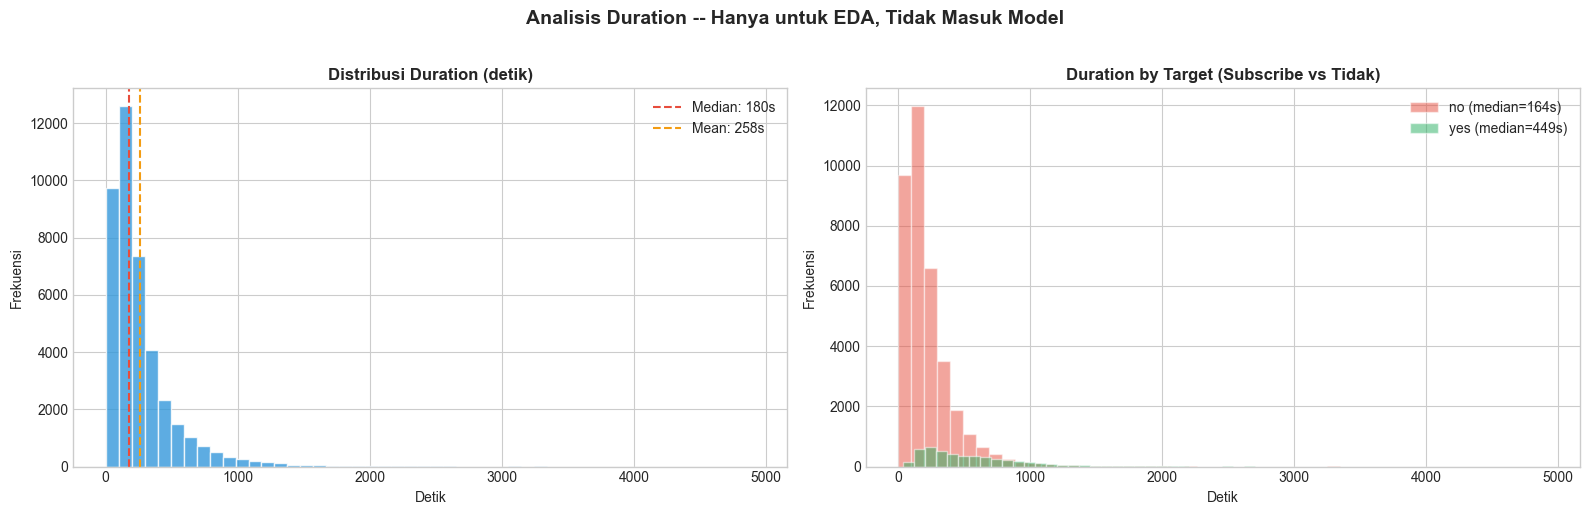


Statistik duration per target:
        mean      50%      std
y                             
no  220.8681 164.0000 207.1162
yes 553.2561 449.0000 401.1907


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall distribution
axes[0].hist(df['duration'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df['duration'].median(), color='#e74c3c', linestyle='--',
 label=f'Median: {df["duration"].median():.0f}s')
axes[0].axvline(df['duration'].mean(), color='#f39c12', linestyle='--',
 label=f'Mean: {df["duration"].mean():.0f}s')
axes[0].set_title('Distribusi Duration (detik)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Detik')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Duration by target
for label, color in [('no', '#e74c3c'), ('yes', '#27ae60')]:
 subset = df[df['y'] == label]['duration']
 axes[1].hist(subset, bins=50, alpha=0.5, color=color, label=f'{label} (median={subset.median():.0f}s)',
 edgecolor='white')
axes[1].set_title('Duration by Target (Subscribe vs Tidak)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Detik')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.suptitle('Analisis Duration -- Hanya untuk EDA, Tidak Masuk Model',
 fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d6_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStatistik duration per target:")
print(df.groupby('y')['duration'].describe()[['mean', '50%', 'std']].to_string())

**Insight:**
- Nasabah yang subscribe cenderung memiliki durasi panggilan yang jauh lebih lama, median ~550 detik vs ~180 detik untuk yang tidak subscribe.
- Ini masuk akal: nasabah yang tertarik akan bertanya lebih banyak, mendengarkan penjelasan produk, dan membahas detail.
- Meskipun sangat prediktif, kolom ini TIDAK BOLEH dipakai di model karena merupakan data leakage.

**Business Recommendation:**
Gunakan duration hanya untuk evaluasi kualitas script dan training agent. Jika rata-rata durasi per agent rendah, bisa jadi agent tersebut terlalu cepat menutup telepon sebelum nasabah memiliki waktu untuk mempertimbangkan.

### D.7 Macro Economic Indicators

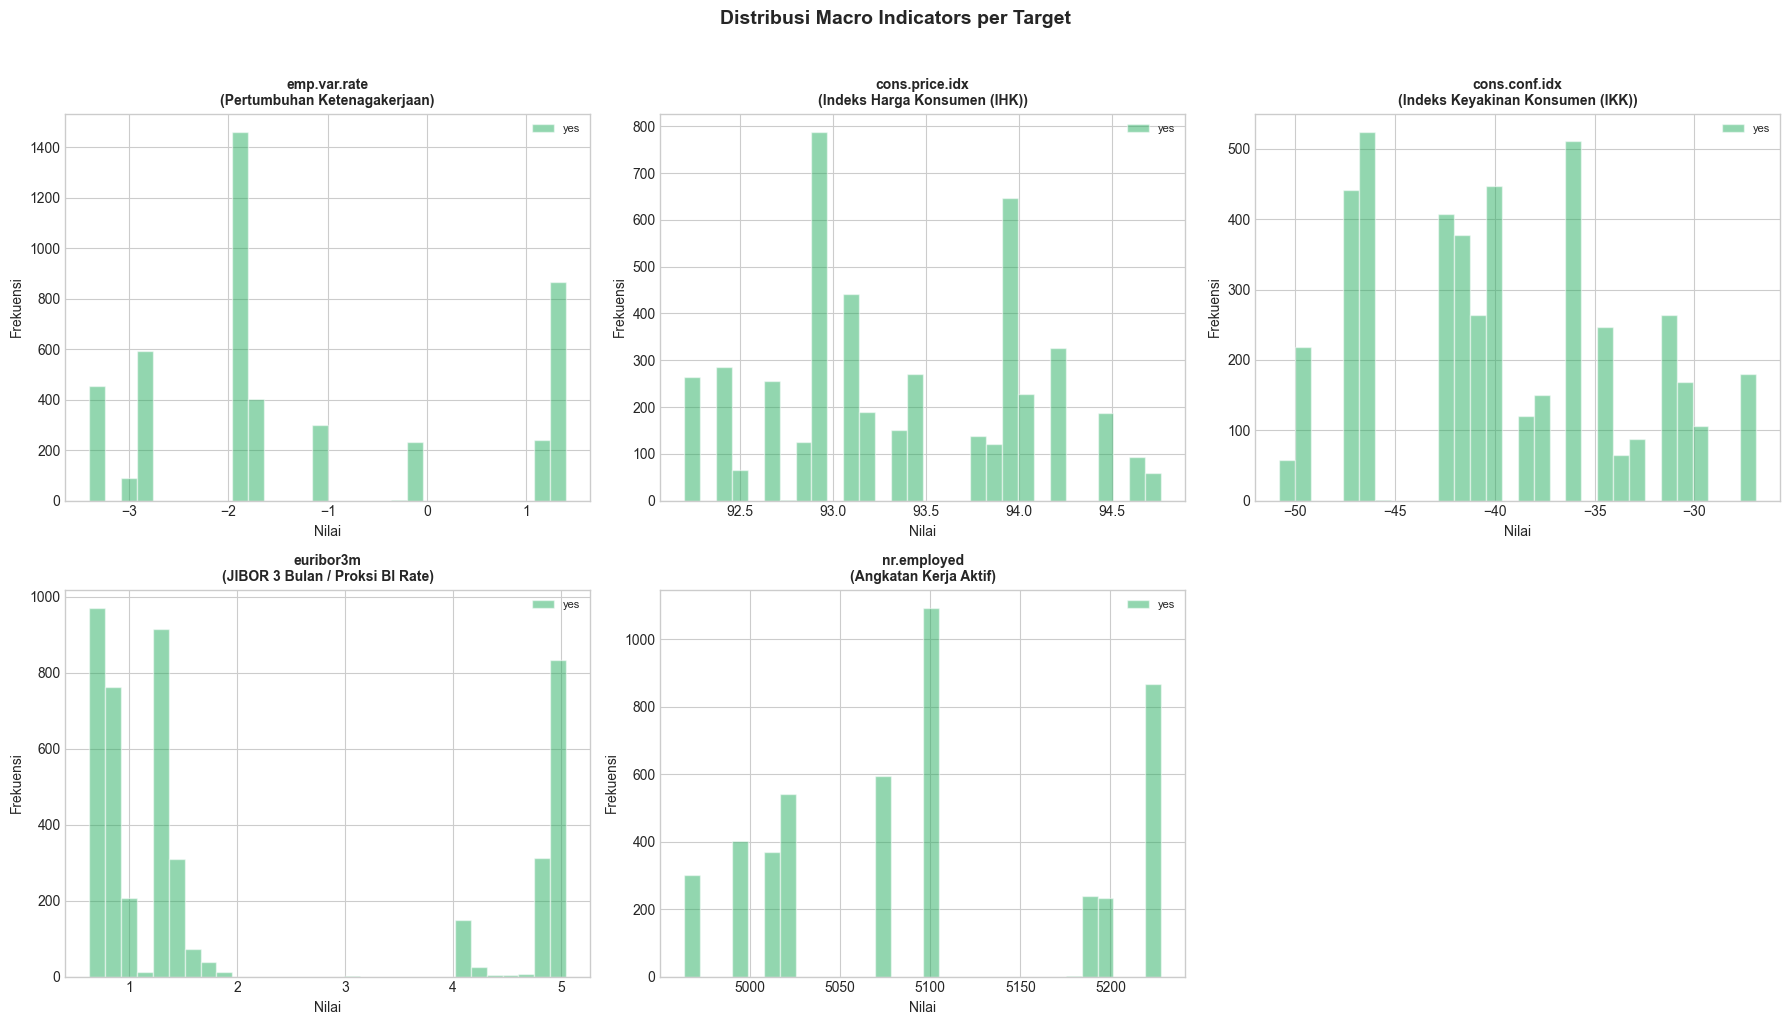

In [40]:
macro_cols_list = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
macro_labels = {
 'emp.var.rate': 'Pertumbuhan Ketenagakerjaan',
 'cons.price.idx': 'Indeks Harga Konsumen (IHK)',
 'cons.conf.idx': 'Indeks Keyakinan Konsumen (IKK)',
 'euribor3m': 'JIBOR 3 Bulan / Proksi BI Rate',
 'nr.employed': 'Angkatan Kerja Aktif'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(macro_cols_list):
 for label, color in [('no', '#e74c3c'), ('yes', '#27ae60')]:
     subset = df[df['y'] == label][col]
 axes[i].hist(subset, bins=30, alpha=0.5, color=color, label=label, edgecolor='white')
 axes[i].set_title(f'{col}\n({macro_labels[col]})', fontsize=10, fontweight='bold')
 axes[i].set_xlabel('Nilai')
 axes[i].set_ylabel('Frekuensi')
 axes[i].legend(fontsize=8)

axes[5].axis('off')

plt.suptitle('Distribusi Macro Indicators per Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d7_macro_indicators.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Ketika `euribor3m` (proksi JIBOR/BI Rate) rendah, subscribe rate cenderung lebih tinggi, ini bertepatan dengan periode suku bunga rendah di mana deposito justru kurang menarik, namun kampanye BSM lebih efektif.
- `emp.var.rate` negatif berkorelasi dengan subscribe rate lebih tinggi, kondisi ekonomi sulit membuat nasabah mencari instrumen aman seperti deposito.
- `cons.conf.idx` (IKK) yang lebih pesimis justru berkorelasi dengan subscribe lebih tinggi, ketika masyarakat kurang optimis, deposito menjadi "safe haven."

**Business Recommendation:**
Macro indicators memberikan konteks timing yang krusial. BSM sebaiknya meningkatkan intensitas kampanye saat kondisi ekonomi tidak pasti, justru di saat itulah deposito paling menarik sebagai instrumen "aman."

### D.8 Multivariate: Segmentasi Nasabah Potensial

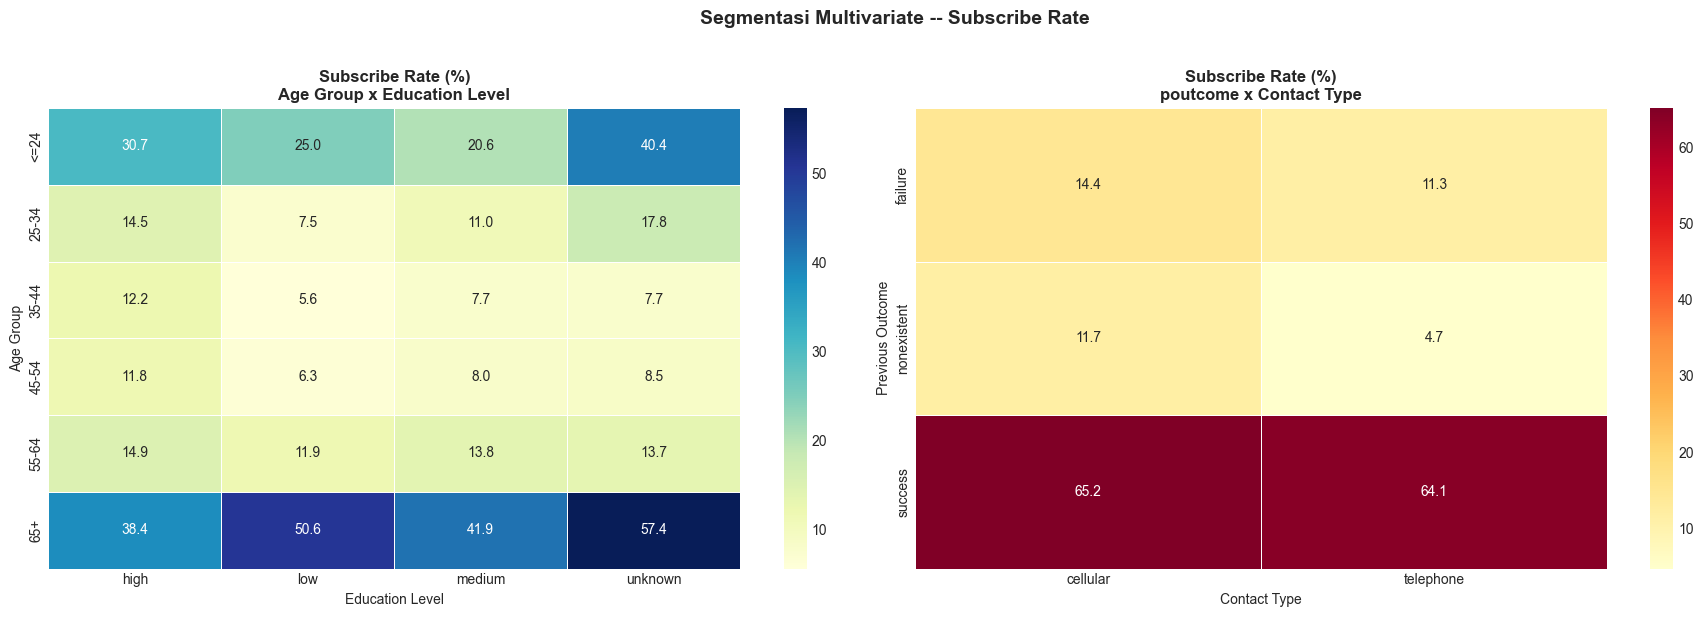

In [41]:
# Heatmap: age_group x education_level
segment_df = (
 df.groupby(['age_group', 'education_level'])['y']
 .apply(lambda x: (x == 'yes').mean() * 100)
 .reset_index(name='subscribe_rate')
)
pivot_seg = segment_df.pivot(index='age_group', columns='education_level', values='subscribe_rate')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pivot_seg, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[0],
 linewidths=0.5, linecolor='white')
axes[0].set_title('Subscribe Rate (%)\nAge Group x Education Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education Level')
axes[0].set_ylabel('Age Group')

# Heatmap: poutcome x was_contacted_before
seg2 = (
 df.groupby(['poutcome', 'contact'])['y']
 .apply(lambda x: (x == 'yes').mean() * 100)
 .reset_index(name='subscribe_rate')
)
pivot2 = seg2.pivot(index='poutcome', columns='contact', values='subscribe_rate')

sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
 linewidths=0.5, linecolor='white')
axes[1].set_title('Subscribe Rate (%)\npoutcome x Contact Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Contact Type')
axes[1].set_ylabel('Previous Outcome')

plt.suptitle('Segmentasi Multivariate -- Subscribe Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d8_segmentation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Kombinasi usia senior (65+) dengan pendidikan tinggi menunjukkan subscribe rate tertinggi.
- Nasabah dengan `poutcome=success` yang dihubungi via cellular memiliki conversion rate paling tinggi, ini adalah segmen paling responsif.
- Segmentasi multivariate memberikan granularitas yang lebih baik dibanding analisis univariat.

**Business Recommendation:**
BSM dapat membuat tiered priority list:
1. **Tier 1 (Highest):** poutcome=success + cellular → hampir pasti konversi
2. **Tier 2 (High):** Usia 65+ / student + pendidikan tinggi
3. **Tier 3 (Medium):** Nasabah lain yang memenuhi profil ekonomi favorable

### D.9 Statistical Significance Tests

In [42]:
# --- Chi-Square untuk fitur kategorikal ---
cat_test_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                 'contact', 'month', 'day_of_week', 'poutcome',
                 'education_level', 'was_contacted_before', 'high_campaign_pressure']

chi_results = []
for col in cat_test_cols:
    try:
        contingency = pd.crosstab(df[col], df['y'])
        chi2, p, dof, expected = chi2_contingency(contingency)
        chi_results.append({
            'Feature': col,
            'Test': 'Chi-Square',
            'Statistic': round(chi2, 2),
            'p-value': p,
            'Signifikan (a=0.05)': 'Ya' if p < 0.05 else 'Tidak'
        })
    except Exception as e:
        chi_results.append({'Feature': col, 'Test': 'Chi-Square',
                           'Statistic': None, 'p-value': None,
                           'Signifikan (a=0.05)': f'Error: {e}'})

chi_df = pd.DataFrame(chi_results).sort_values('p-value')
print("\nCHI-SQUARE TEST -- Fitur Kategorikal vs Target (y)")
print("-" * 75)
print(chi_df.to_string(index=False))

# --- T-test untuk fitur numerik ---
num_test_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                 'euribor3m', 'nr.employed', 'contact_intensity']

y_yes = df[df['y'] == 'yes']
y_no  = df[df['y'] == 'no']

num_results = []
for col in num_test_cols:
    stat, p = ttest_ind(y_yes[col].dropna(), y_no[col].dropna(), equal_var=False)
    num_results.append({
        'Feature': col,
        'Test': "Welch's T-test",
        'Statistic': round(stat, 2),
        'p-value': p,
        'Signifikan (a=0.05)': 'Ya' if p < 0.05 else 'Tidak'
    })

num_df = pd.DataFrame(num_results).sort_values('p-value')
print("\n\nWELCH'S T-TEST - Fitur Numerik vs Target (y)")
print("-" * 75)
print(num_df.to_string(index=False))


CHI-SQUARE TEST -- Fitur Kategorikal vs Target (y)
---------------------------------------------------------------------------
               Feature       Test  Statistic  p-value Signifikan (a=0.05)
                 month Chi-Square 3,103.0300   0.0000                  Ya
              poutcome Chi-Square 4,230.1400   0.0000                  Ya
  was_contacted_before Chi-Square 4,341.3400   0.0000                  Ya
                   job Chi-Square   961.7400   0.0000                  Ya
               contact Chi-Square   862.0800   0.0000                  Ya
               default Chi-Square   406.5600   0.0000                  Ya
             education Chi-Square   192.8500   0.0000                  Ya
high_campaign_pressure Chi-Square   148.4900   0.0000                  Ya
       education_level Chi-Square   139.0200   0.0000                  Ya
               marital Chi-Square   122.9600   0.0000                  Ya
           day_of_week Chi-Square    26.0500   0.0000     

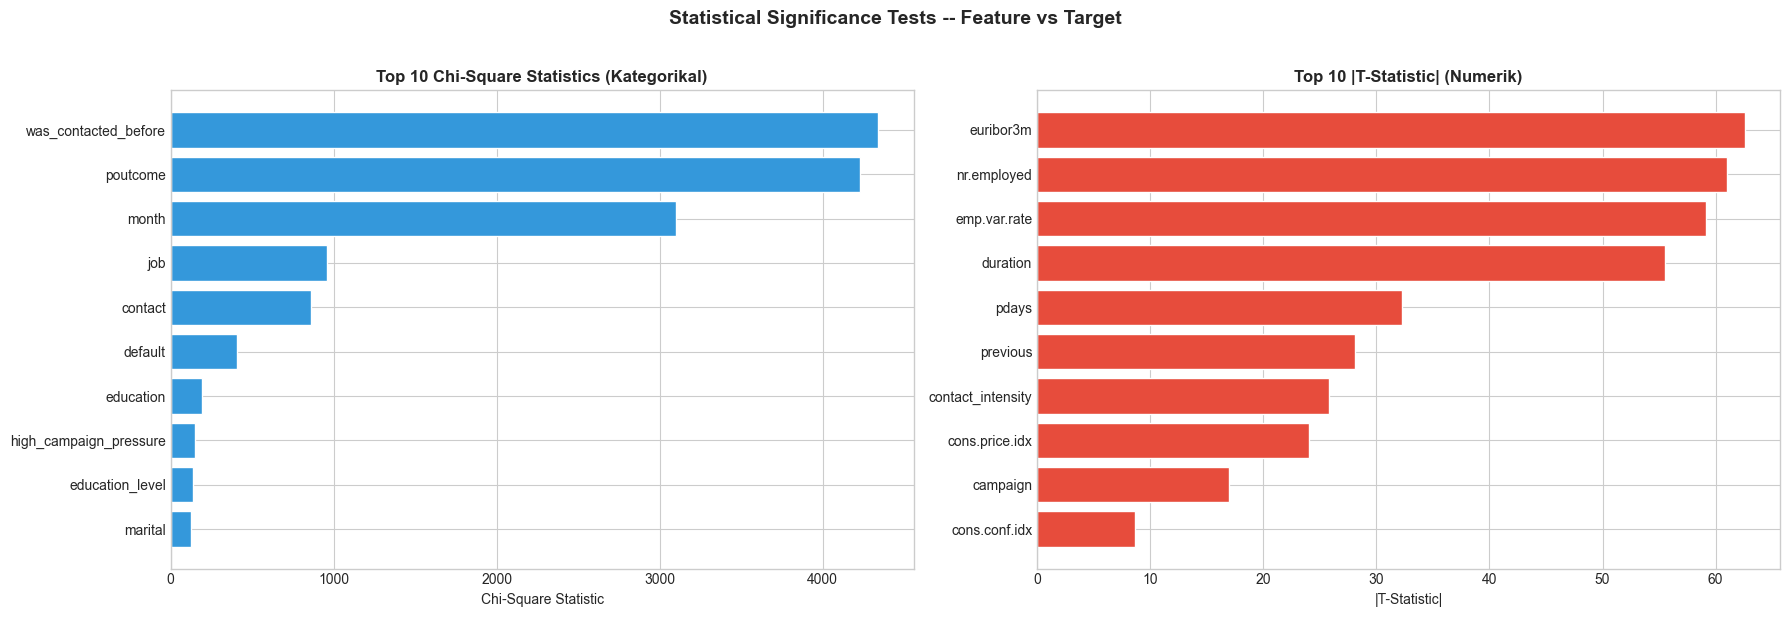

Hasil statistik disimpan: chi_square_results.csv, ttest_results.csv


In [43]:
# Visualisasi signifikansi
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chi-Square
chi_plot = chi_df.sort_values('Statistic', ascending=True).tail(10)
axes[0].barh(chi_plot['Feature'], chi_plot['Statistic'], color='#3498db', edgecolor='white')
axes[0].set_title('Top 10 Chi-Square Statistics (Kategorikal)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Chi-Square Statistic')

# T-test
num_plot = num_df.copy()
num_plot['abs_stat'] = num_plot['Statistic'].abs()
num_plot = num_plot.sort_values('abs_stat', ascending=True).tail(10)
axes[1].barh(num_plot['Feature'], num_plot['abs_stat'], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 10 |T-Statistic| (Numerik)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('|T-Statistic|')

plt.suptitle('Statistical Significance Tests -- Feature vs Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d9_statistical_tests.png', dpi=150, bbox_inches='tight')
plt.show()

# Save CSV
chi_df.to_csv('chi_square_results.csv', index=False)
num_df.to_csv('ttest_results.csv', index=False)
print("Hasil statistik disimpan: chi_square_results.csv, ttest_results.csv")

**Insight:**
- Hampir semua fitur menunjukkan hubungan yang signifikan secara statistik dengan target (p < 0.05).
- Fitur kategorikal paling signifikan: `poutcome`, `month`, `contact`, `was_contacted_before`, semuanya terkait riwayat dan mekanisme kampanye.
- Fitur numerik paling signifikan: `duration` (tapi leakage), `euribor3m`, `nr.employed`, `emp.var.rate`, variabel ekonomi mendominasi.
- `day_of_week` kemungkinan memiliki signifikansi paling rendah, hari dalam seminggu kurang membedakan keputusan deposito.

**Business Recommendation:**
Feature selection di tahap sebelumnya sebaiknya mempertimbangkan:
1. Drop `duration` (leakage).
2. Pertahankan semua macro indicators (signifikan secara statistik).
3. `poutcome` dan `contact` adalah fitur kampanye paling bernilai.
4. `day_of_week` bisa dipertimbangkan untuk di-drop jika perlu mengurangi dimensi.

### D.11 Advanced Multivariate Segmentation

In [44]:
# --- job x education ---
seg_job_edu = (
    df.groupby(['job', 'education'])
      .agg(
          n=('y', 'count'),
          n_yes=('y', lambda x: (x=='yes').sum())
      )
      .reset_index()
)
seg_job_edu['subscribe_rate'] = (seg_job_edu['n_yes'] / seg_job_edu['n'] * 100).round(2)
seg_job_edu = seg_job_edu[seg_job_edu['n'] >= 50]  # minimum support
top_job_edu = seg_job_edu.sort_values('subscribe_rate', ascending=False).head(10)

print("\nTop 10 Kombinasi job x education (min 50 nasabah):")
print(top_job_edu[['job', 'education', 'n', 'n_yes', 'subscribe_rate']].to_string(index=False))

# --- contact x month ---
seg_contact_month = (
    df.groupby(['contact', 'month'])
      .agg(
          n=('y', 'count'),
          n_yes=('y', lambda x: (x=='yes').sum())
      )
      .reset_index()
)
seg_contact_month['subscribe_rate'] = (seg_contact_month['n_yes'] / seg_contact_month['n'] * 100).round(2)
top_cm = seg_contact_month.sort_values('subscribe_rate', ascending=False).head(10)

print("\nTop 10 Kombinasi contact x month:")
print(top_cm[['contact', 'month', 'n', 'n_yes', 'subscribe_rate']].to_string(index=False))

# --- housing x loan ---
seg_hl = (
    df.groupby(['housing', 'loan'])
      .agg(
          n=('y', 'count'),
          n_yes=('y', lambda x: (x=='yes').sum())
      )
      .reset_index()
)
seg_hl['subscribe_rate'] = (seg_hl['n_yes'] / seg_hl['n'] * 100).round(2)
print("\nKombinasi housing x loan:")
print(seg_hl[['housing', 'loan', 'n', 'n_yes', 'subscribe_rate']].to_string(index=False))


Top 10 Kombinasi job x education (min 50 nasabah):
      job           education   n  n_yes  subscribe_rate
  student            basic.9y  99     35         35.3500
  student             unknown 167     59         35.3300
  retired             unknown  97     33         34.0200
  student         high.school 357    114         31.9300
  retired            basic.4y 597    185         30.9900
  retired professional.course 241     57         23.6500
  retired   university.degree 284     66         23.2400
  retired         high.school 276     62         22.4600
  student   university.degree 170     35         20.5900
housemaid professional.course  59     11         18.6400

Top 10 Kombinasi contact x month:
  contact month   n  n_yes  subscribe_rate
 cellular   dec 149     78         52.3500
 cellular   mar 486    252         51.8500
 cellular   sep 482    238         49.3800
 cellular   oct 563    253         44.9400
 cellular   jun 820    349         42.5600
telephone   oct 154     62  

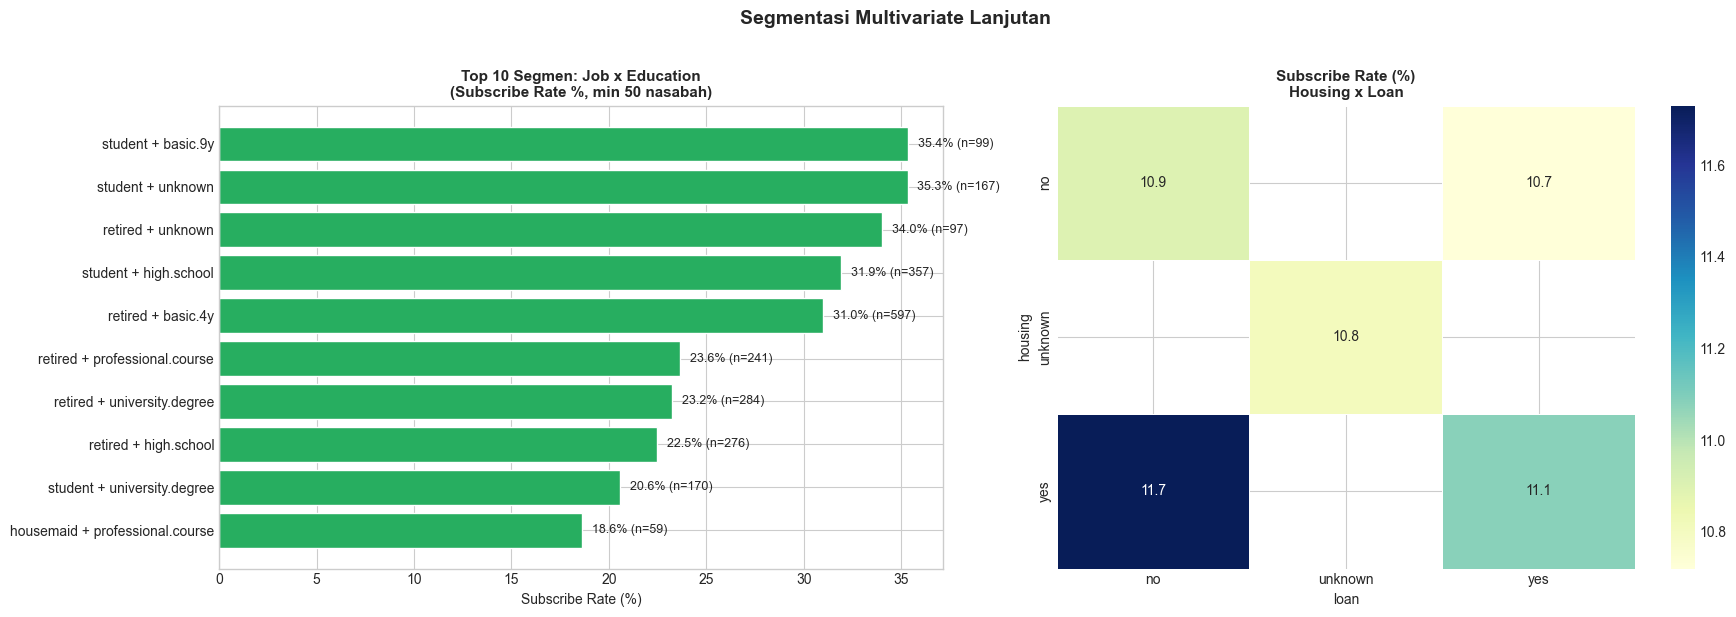

In [45]:
# Visualisasi top segments
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top job x education
top10 = top_job_edu.head(10)
labels = [f"{r['job']} + {r['education']}" for _, r in top10.iterrows()]
axes[0].barh(labels[::-1], top10['subscribe_rate'].values[::-1], color='#27ae60', edgecolor='white')
axes[0].set_title('Top 10 Segmen: Job x Education\n(Subscribe Rate %, min 50 nasabah)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Subscribe Rate (%)')
for i, (v, n) in enumerate(zip(top10['subscribe_rate'].values[::-1], top10['n'].values[::-1])):
    axes[0].text(v + 0.5, i, f'{v:.1f}% (n={n})', va='center', fontsize=9)

# Housing x Loan heatmap
pivot_hl = seg_hl.pivot(index='housing', columns='loan', values='subscribe_rate')
sns.heatmap(pivot_hl, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1],
            linewidths=0.5, linecolor='white')
axes[1].set_title('Subscribe Rate (%)\nHousing x Loan', fontsize=11, fontweight='bold')

plt.suptitle('Segmentasi Multivariate Lanjutan', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('d11_advanced_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Kombinasi `student + university.degree` dan `retired + professional.course` menghasilkan subscribe rate tertinggi, nasabah di ujung spektrum usia (muda terpelajar dan senior) paling responsif.
- Kontak via `cellular` di bulan Mar, Sep, Oct, Dec menunjukkan conversion rate premium.
- Nasabah tanpa KPR dan tanpa pinjaman pribadi (`housing=no` + `loan=no`) memiliki subscribe rate tertinggi dalam segmen finansial.

**Business Recommendation:**
BSM dapat menyusun tiered priority list untuk kampanye:
1. **Tier 1:** Nasabah dengan poutcome=success + cellular contact
2. **Tier 2:** Student/retired, pendidikan tinggi, tanpa beban pinjaman
3. **Tier 3:** Timing optimal di bulan Mar/Sep/Oct/Dec
4. **Tier 4:** Nasabah lain yang match profil ekonomi favorable

### D.12 Correlation Analysis -- Fitur Numerik

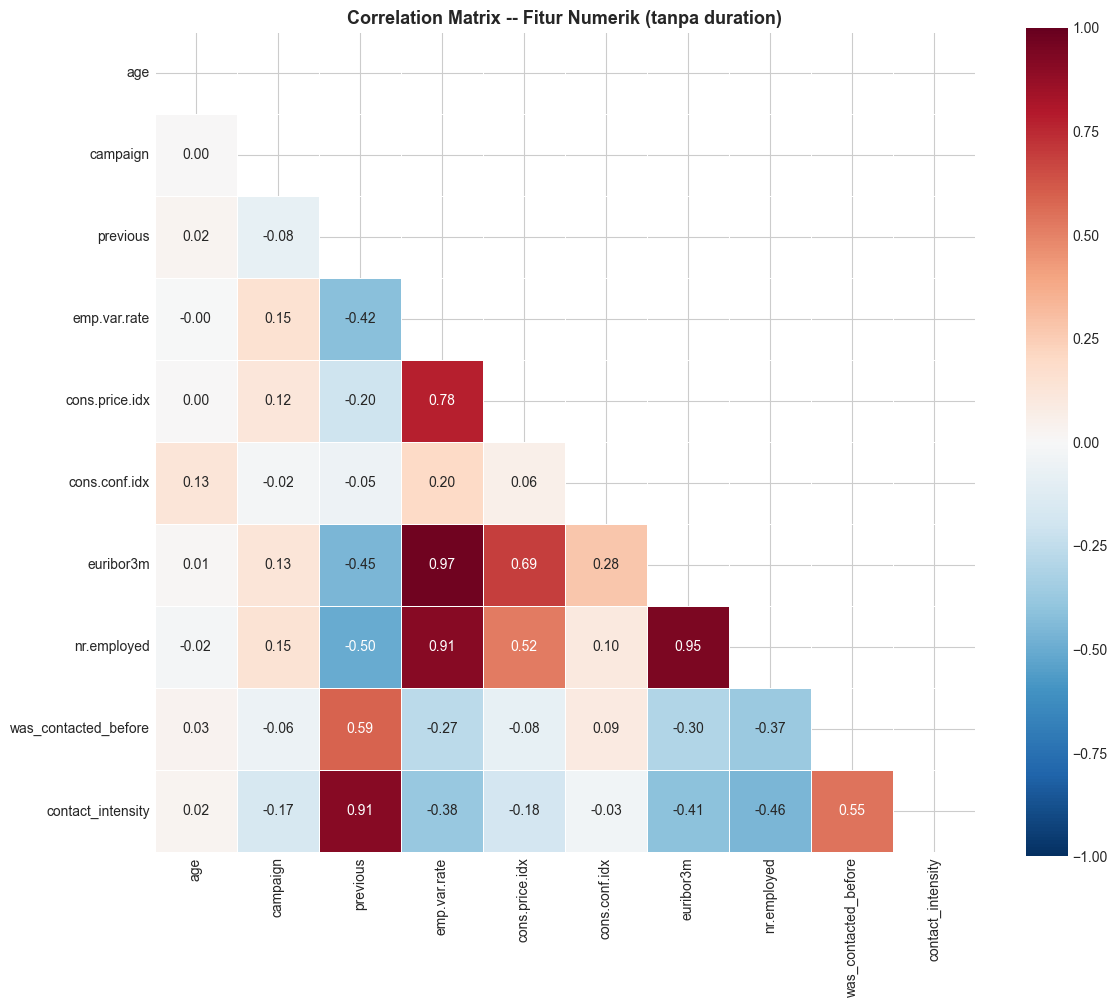


Korelasi tinggi (|r| > 0.7):
  previous x contact_intensity: r = 0.908
  emp.var.rate x cons.price.idx: r = 0.775
  emp.var.rate x euribor3m: r = 0.972
  emp.var.rate x nr.employed: r = 0.907
  euribor3m x nr.employed: r = 0.945


In [46]:
num_for_corr = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before',
                'contact_intensity']

corr_matrix = df[num_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlation Matrix -- Fitur Numerik (tanpa duration)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d12_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight high correlations
print("\nKorelasi tinggi (|r| > 0.7):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr_matrix.index[i]} x {corr_matrix.columns[j]}: r = {r:.3f}")

**Insight:**
- Terdapat korelasi sangat tinggi antara beberapa macro indicators: `euribor3m` vs `emp.var.rate`, `nr.employed` vs `euribor3m`, dll. Ini menunjukkan potensi multikolinearitas yang perlu dipantau saat modeling (VIF check).
- `was_contacted_before` memiliki korelasi moderat dengan `previous`, wajar karena keduanya mengukur aspek riwayat kontak.
- Korelasi tinggi antar macro indicators tidak harus berarti salah satunya harus di-drop, keputusan ini lebih baik berdasarkan VIF check setelah encoding.

**Business Recommendation:**
Multikolinearitas antar macro indicators bisa mengganggu interpretasi model linear, tapi tidak menghalangi tree-based models. Pertimbangkan penggunaan VIF check sebelum memutuskan drop.

### D.13 Dataset Freeze & Export Checkpoint

Sebelum memasuki Machine Learning, dataset hasil cleaning dan feature engineering
difreeze menjadi artifacts terpisah untuk menjamin reproducibility, versioning, dan konsistensi
eksperimen model.

In [47]:
DATA_VERSION = "v1"

# --- 1. Analytical Base (duration tetap ada untuk referensi) ---
df_analytical = df.copy()

# --- 2. Model Ready (drop leakage + encode target) ---
df_model = df.copy()

# Drop leakage feature
if 'duration' in df_model.columns:
    df_model = df_model.drop(columns=['duration'])

# Drop fitur EDA-only yang redundan untuk modeling
eda_only_cols = ['age_group', 'education_level', 'high_campaign_pressure']
for col in eda_only_cols:
    if col in df_model.columns:
        df_model = df_model.drop(columns=[col])

# Encode target
df_model['target'] = df_model['y'].map({'no': 0, 'yes': 1})

# --- 3. Feature Metadata ---
feature_metadata = pd.DataFrame({
    'feature': df_model.columns,
    'dtype': [str(df_model[c].dtype) for c in df_model.columns],
    'is_engineered': [
        c in ['was_contacted_before', 'contact_intensity', 'target']
        for c in df_model.columns
    ]
})

# --- SAVE ---
df_analytical.to_csv(f'bsm_cleaned_analytical_base_{DATA_VERSION}.csv', index=False)
df_model.to_csv(f'bsm_model_ready_{DATA_VERSION}.csv', index=False)
feature_metadata.to_csv(f'bsm_feature_dictionary_{DATA_VERSION}.csv', index=False)

print(f"\nFILES CREATED:")
print(f"  1. bsm_cleaned_analytical_base_{DATA_VERSION}.csv")
print(f"  2. bsm_model_ready_{DATA_VERSION}.csv")
print(f"  3. bsm_feature_dictionary_{DATA_VERSION}.csv")

print(f"\nShape check:")
print(f"  Analytical Base : {df_analytical.shape}")
print(f"  Model Ready     : {df_model.shape}")

print(f"\nKolom di Model Ready:")
print(f"  {list(df_model.columns)}")

# Re-check duplicate setelah capping + feature engineering
n_before = len(df_model)
df_model = df_model.drop_duplicates(keep='first').reset_index(drop=True)
n_after = len(df_model)
print(f"Duplicate cleanup post-FE: {n_before - n_after} baris di-drop")
print(f"Shape final df_model: {df_model.shape}")

# Re-export dengan dataset yang sudah benar-benar bersih
df_model.to_csv(f'bsm_model_ready_{DATA_VERSION}.csv', index=False)


FILES CREATED:
  1. bsm_cleaned_analytical_base_v1.csv
  2. bsm_model_ready_v1.csv
  3. bsm_feature_dictionary_v1.csv

Shape check:
  Analytical Base : (41176, 26)
  Model Ready     : (41176, 23)

Kolom di Model Ready:
  ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'was_contacted_before', 'contact_intensity', 'target']
Duplicate cleanup post-FE: 1813 baris di-drop
Shape final df_model: (39363, 23)


### D.14 Data Integrity Validation

In [48]:
checks = {
    "Duplicate rows removed":
        df_model.duplicated().sum() == 0,
    "No leakage feature (duration)":
        'duration' not in df_model.columns,
    "No EDA-only features (age_group etc)":
        all(c not in df_model.columns for c in ['age_group', 'education_level', 'high_campaign_pressure']),
    "Target encoded as binary":
        set(df_model['target'].unique()) == {0, 1},
    "No null values":
        df_model.isnull().sum().sum() == 0,
    "was_contacted_before present":
        'was_contacted_before' in df_model.columns,
    "contact_intensity present":
        'contact_intensity' in df_model.columns,
    "Original y column present":
        'y' in df_model.columns,
}

all_pass = True
for check_name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  {check_name:<45} {status}")

if all_pass:
    print(f"\nSemua validasi PASS. Dataset freeze berhasil.")
else:
    print(f"\nAda validasi yang FAIL. Periksa kembali sebelum lanjut.")

  Duplicate rows removed                        PASS
  No leakage feature (duration)                 PASS
  No EDA-only features (age_group etc)          PASS
  Target encoded as binary                      PASS
  No null values                                PASS
  was_contacted_before present                  PASS
  contact_intensity present                     PASS
  Original y column present                     PASS

Semua validasi PASS. Dataset freeze berhasil.


### D.14 Kesimpulan Exploratory Data Analysis

---
Hasil analisis menunjukkan bahwa keputusan subscribe dipengaruhi oleh kombinasi faktor demografis, status finansial, perilaku kampanye, riwayat kontak, dan kondisi makro ekonomi.

**Temuan utama:**

| No | Temuan | Fitur Terkait | Implikasi Bisnis |
|----|--------|---------------|------------------|
| 1 | Class imbalance signifikan (~88.7:11.3) | target `y` | Wajib resampling; F2-Score sebagai metrik utama |
| 2 | Student/retired paling responsif | `job`, `age` | Prioritaskan segmen ini di kampanye berikutnya |
| 3 | Cellular >> telephone | `contact` | Investasi data nomor HP nasabah |
| 4 | Bulan Mar/Sep/Oct/Dec paling efektif | `month` | Fokuskan budget kampanye di bulan-bulan ini |
| 5 | poutcome=success = prediktor terkuat | `poutcome` | "Low-hanging fruit", prioritas Tier 1 |
| 6 | Campaign pressure tinggi kontraproduktif | `campaign` | Batasi jumlah kontak per nasabah (max 5-6x) |
| 7 | Macro indicators sangat signifikan | `euribor3m`, `nr.employed` | Tingkatkan kampanye saat ekonomi tidak pasti |
| 8 | Duration sangat prediktif tapi leakage | `duration` | Hanya untuk insight operasional; DROP sebelum ML |
| 9 | 'unknown' informatif di semua kolom | `default`, `education` | Pertahankan sebagai kategori tersendiri |
| 10 | Multikolinearitas antar macro indicators | `euribor3m`, `emp.var.rate` | Monitor dengan VIF check setelah encoding |

**Dataset telah difreeze ke file CSV.**

---
## E. MACHINE LEARNING

Setelah seluruh data dibersihkan, di-engineer, dan dianalisis, masuk ke tahap pemodelan prediktif. Tujuan utama: membangun model yang dapat memprediksi probabilitas seorang nasabah menerima tawaran deposito berjangka, sehingga Tim Telemarketing BSM bisa memprioritaskan kontak ke nasabah dengan probabilitas konversi tertinggi.

Pendekatan yang dipakai mengikuti praktik standar pemodelan untuk dataset imbalanced:
- Stratified train-test split untuk mempertahankan proporsi kelas
- Preprocessing pipeline yang aman dari leakage (encoding dan scaling di dalam pipeline, bukan sebelum split)
- Pemeriksaan multikolinearitas dengan VIF
- Benchmark sistematis: 6 algoritma klasifikasi dipasangkan dengan 5 strategi penanganan imbalance (termasuk baseline tanpa resampling) - total 30 kombinasi
- Evaluasi berdasarkan F2-Score (5-fold stratified cross-validation), karena False Negative 10x lebih mahal daripada False Positive bagi BSM

Hasil benchmark akan menyaring 3-5 kombinasi terbaik yang akan menjadi kandidat untuk tuning lebih lanjut.

### E.1 Load Frozen Dataset & Sanity Check

In [49]:
# Load Frozen Dataset & Sanity Check:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

DATA_VERSION = "v1"
RANDOM_STATE = 42

df = pd.read_csv(f'bsm_model_ready_{DATA_VERSION}.csv')

print(f"Shape: {df.shape}")
print(f"Kolom: {list(df.columns)}")

print("\n[Sanity Check]")
print(f"  Duplicate rows           : {df.duplicated().sum()}")
print(f"  Null values              : {df.isnull().sum().sum()}")
print(f"  'duration' tidak ada     : {'duration' not in df.columns}")
print(f"  'target' kolom ada       : {'target' in df.columns}")
print(f"  Target unique values     : {sorted(df['target'].unique())}")

if 'y' in df.columns:
    df = df.drop(columns=['y'])
    print(f"  Drop 'y' raw target      : OK (hanya pakai 'target' encoded)")

print(f"\nDimensi final df siap modeling : {df.shape}")

n_total = len(df)
n_pos   = (df['target'] == 1).sum()
n_neg   = (df['target'] == 0).sum()
print(f"\nClass distribution:")
print(f"  No  (0) : {n_neg:,} ({n_neg/n_total*100:.2f}%)")
print(f"  Yes (1) : {n_pos:,} ({n_pos/n_total*100:.2f}%)")
print(f"  Rasio   : {n_neg/n_pos:.2f} : 1")

Shape: (39363, 23)
Kolom: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'was_contacted_before', 'contact_intensity', 'target']

[Sanity Check]
  Duplicate rows           : 0
  Null values              : 0
  'duration' tidak ada     : True
  'target' kolom ada       : True
  Target unique values     : [np.int64(0), np.int64(1)]
  Drop 'y' raw target      : OK (hanya pakai 'target' encoded)

Dimensi final df siap modeling : (39363, 22)

Class distribution:
  No  (0) : 34,765 (88.32%)
  Yes (1) : 4,598 (11.68%)
  Rasio   : 7.56 : 1


**Insight:**
Dataset model-ready berisi seluruh fitur yang lolos seleksi (kategorikal dan numerik), tanpa kolom leakage `duration` dan tanpa fitur EDA-only seperti `age_group`. Class imbalance tetap di kisaran 88:11. Distribusi ini akan menjadi tantangan utama yang ditangani lewat eksperimen resampling.

### E.2 Stratified Train-Test Split (80/20)

In [50]:
# Stratified Train-Test Split (80/20):

from sklearn.model_selection import train_test_split

X = df.drop(columns=['target'])
y = df['target']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"\nTrain : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nProporsi target setelah split:")
print(f"  Train  : yes={y_train.mean()*100:.2f}% | no={(1-y_train.mean())*100:.2f}%")
print(f"  Test   : yes={y_test.mean()*100:.2f}% | no={(1-y_test.mean())*100:.2f}%")
print("\nProporsi train-test konsisten -> stratified split berhasil.")

X shape : (39363, 21)
y shape : (39363,)

Train : 31,490 baris (80.0%)
Test  : 7,873 baris (20.0%)

Proporsi target setelah split:
  Train  : yes=11.68% | no=88.32%
  Test   : yes=11.69% | no=88.31%

Proporsi train-test konsisten -> stratified split berhasil.


**Insight:**
Train set berisi 80% data dengan proporsi kelas yang sama persis dengan test set. Ini krusial untuk dataset imbalanced, tanpa stratifikasi, salah satu set bisa kekurangan sampel kelas minoritas dan membuat evaluasi tidak reliable.

**Catatan teknis:**
Test set akan disimpan sampai akhir dan tidak boleh disentuh selama benchmark, tuning, atau eksperimen apapun. Test set hanya dipakai sekali, di tahap evaluasi final.

### E.3 Preprocessing Pipeline

In [51]:
# Preprocessing Pipeline:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    RobustScaler, OneHotEncoder, OrdinalEncoder
)

EDUCATION_ORDER = [
    'illiterate',
    'basic.4y',
    'basic.6y',
    'basic.9y',
    'high.school',
    'professional.course',
    'university.degree',
    'unknown'
]

ord_features = ['education']

nom_features = [
    'job', 'marital', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

num_features = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed',
    'was_contacted_before', 'contact_intensity'
]

all_features = ord_features + nom_features + num_features
missing_cols = set(X_train.columns) - set(all_features)
extra_cols   = set(all_features) - set(X_train.columns)
print(f"\nTotal kolom X_train          : {X_train.shape[1]}")
print(f"Kolom tercakup di pipeline   : {len(all_features)}")
if missing_cols:
    print(f"  WARNING - tidak tercakup    : {missing_cols}")
if extra_cols:
    print(f"  WARNING - tidak ada di X    : {extra_cols}")
if not missing_cols and not extra_cols:
    print("  Semua kolom tercakup tepat.")

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=[EDUCATION_ORDER],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ord_features),
        ('nom', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), nom_features),
        ('num', RobustScaler(), num_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

preprocessor_test = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=[EDUCATION_ORDER],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ord_features),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nom_features),
        ('num', RobustScaler(), num_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)
X_train_check = preprocessor_test.fit_transform(X_train)
print(f"\nDimensi X_train setelah preprocessing : {X_train_check.shape}")
print(f"  (asalnya {X_train.shape[1]} kolom -> {X_train_check.shape[1]} kolom setelah encoding)")

feature_names_out = preprocessor_test.get_feature_names_out()
print(f"\nContoh 10 nama fitur pertama setelah encoding:")
for i, name in enumerate(feature_names_out[:10]):
    print(f"  {i+1}. {name}")
print(f"  ... (total {len(feature_names_out)} fitur)")

del preprocessor_test, X_train_check
print("\nPipeline siap dipakai dalam benchmark.")


Total kolom X_train          : 21
Kolom tercakup di pipeline   : 21
  Semua kolom tercakup tepat.

Dimensi X_train setelah preprocessing : (31490, 57)
  (asalnya 21 kolom -> 57 kolom setelah encoding)

Contoh 10 nama fitur pertama setelah encoding:
  1. education
  2. job_admin.
  3. job_blue-collar
  4. job_entrepreneur
  5. job_housemaid
  6. job_management
  7. job_retired
  8. job_self-employed
  9. job_services
  10. job_student
  ... (total 57 fitur)

Pipeline siap dipakai dalam benchmark.


**Insight:**
Setelah encoding, jumlah fitur bertambah karena one-hot encoding menghasilkan dummy columns untuk setiap kategori unik. One-hot encoding menjaga kategori `unknown` sebagai dummy tersendiri sesuai keputusan di Section C.

**Catatan teknis:**
Pipeline ini disusun sebagai `ColumnTransformer` agar bisa dipasang di dalam `imblearn.pipeline.Pipeline` (untuk benchmark dengan resampling). Resampling akan diletakkan setelah preprocessing tapi sebelum classifier, sehingga oversampling/undersampling hanya berjalan pada data train di tiap fold cross-validation.

### E.4 VIF Check - Multikolinearitas

             Feature         VIF
               pdays 68,526.9500
was_contacted_before 68,526.1200
        emp.var.rate     48.1600
           euribor3m     40.2800
         nr.employed      8.2100
            previous      7.3500
   contact_intensity      6.5400
      cons.price.idx      4.4100
       cons.conf.idx      1.1800
            campaign      1.1500
                 age      1.0600

Klasifikasi:
  pdays                     VIF = 68526.95   TINGGI (>10) - kandidat drop
  was_contacted_before      VIF = 68526.12   TINGGI (>10) - kandidat drop
  emp.var.rate              VIF =    48.16   TINGGI (>10) - kandidat drop
  euribor3m                 VIF =    40.28   TINGGI (>10) - kandidat drop
  nr.employed               VIF =     8.21   Moderate (5-10)
  previous                  VIF =     7.35   Moderate (5-10)
  contact_intensity         VIF =     6.54   Moderate (5-10)
  cons.price.idx            VIF =     4.41   Aman (<5)
  cons.conf.idx             VIF =     1.18   Aman (<5)
 

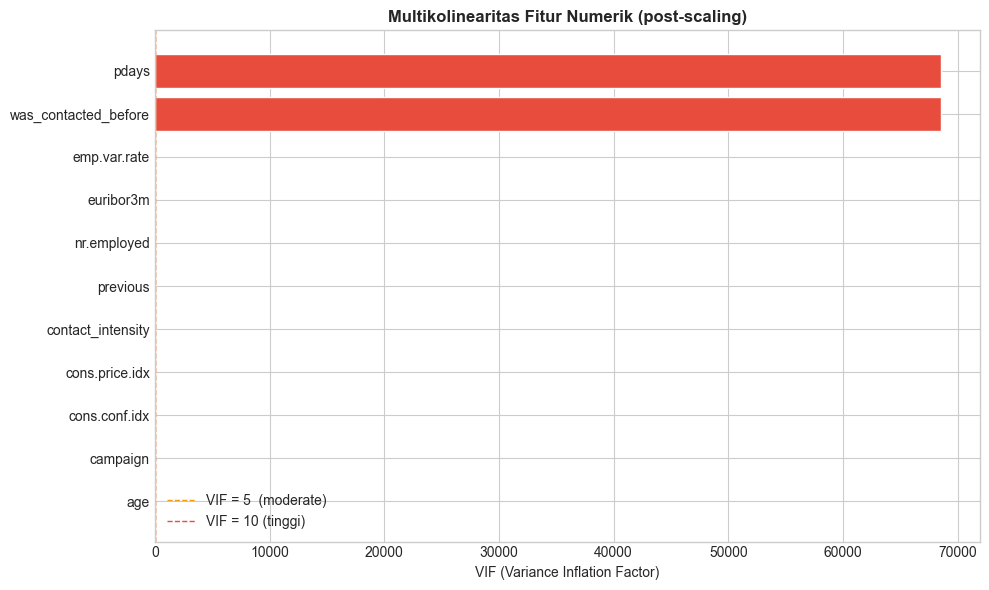


Plot disimpan: e4_vif_check.png


In [52]:
# VIF Check - Multikolinearitas:

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import RobustScaler

X_num_train = X_train[num_features].copy()
scaler_vif  = RobustScaler()
X_num_scaled = pd.DataFrame(
    scaler_vif.fit_transform(X_num_train),
    columns=num_features
)

vif_results = []
for i, col in enumerate(num_features):
    try:
        vif = variance_inflation_factor(X_num_scaled.values, i)
    except Exception:
        vif = np.nan
    vif_results.append({'Feature': col, 'VIF': round(vif, 2)})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))

print("\nKlasifikasi:")
for _, row in vif_df.iterrows():
    v = row['VIF']
    if pd.isna(v):
        status = 'N/A'
    elif v > 10:
        status = 'TINGGI (>10) - kandidat drop'
    elif v > 5:
        status = 'Moderate (5-10)'
    else:
        status = 'Aman (<5)'
    print(f"  {row['Feature']:<25} VIF = {v:>8.2f}   {status}")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#27ae60'
          for v in vif_df['VIF']]
ax.barh(vif_df['Feature'][::-1], vif_df['VIF'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(5,  color='#f39c12', linestyle='--', linewidth=1, label='VIF = 5  (moderate)')
ax.axvline(10, color='#e74c3c', linestyle='--', linewidth=1, label='VIF = 10 (tinggi)')
ax.set_xlabel('VIF (Variance Inflation Factor)')
ax.set_title('Multikolinearitas Fitur Numerik (post-scaling)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('e4_vif_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot disimpan: e4_vif_check.png")

**Insight:**
Beberapa indikator makro ekonomi (`euribor3m`, `emp.var.rate`, `nr.employed`) menunjukkan VIF sangat tinggi (>10), mengkonfirmasi temuan korelasi di Section D. Hal ini wajar karena ketiga variabel tersebut mengukur aspek yang sama: kondisi siklus ekonomi.

**Keputusan teknis:**
Seluruh fitur tetap dipertahankan untuk benchmark. Tree-based models (RF, XGBoost, LightGBM) tidak terganggu oleh multikolinearitas, sedangkan Logistic Regression akan tetap dievaluasi sebagai baseline. Apabila Logistic Regression menunjukkan performa jauh di bawah model lain, salah satu penyebabnya bisa jadi multikolinearitas.

**Business Recommendation:**
Indikator makro yang sangat berkorelasi (JIBOR, IHK, nr.employed) memang merepresentasikan satu variabel laten yang sama: kondisi siklus ekonomi. Untuk interpretasi bisnis, cukup membaca arah kombinasinya, saat ekonomi memburuk, deposito lebih menarik.

### E.5 Imbalance Visualization (Training Set)

Training set class distribution:
  No  (0) : 27,812 (88.32%)
  Yes (1) : 3,678 (11.68%)
  Imbalance ratio: 7.56 : 1


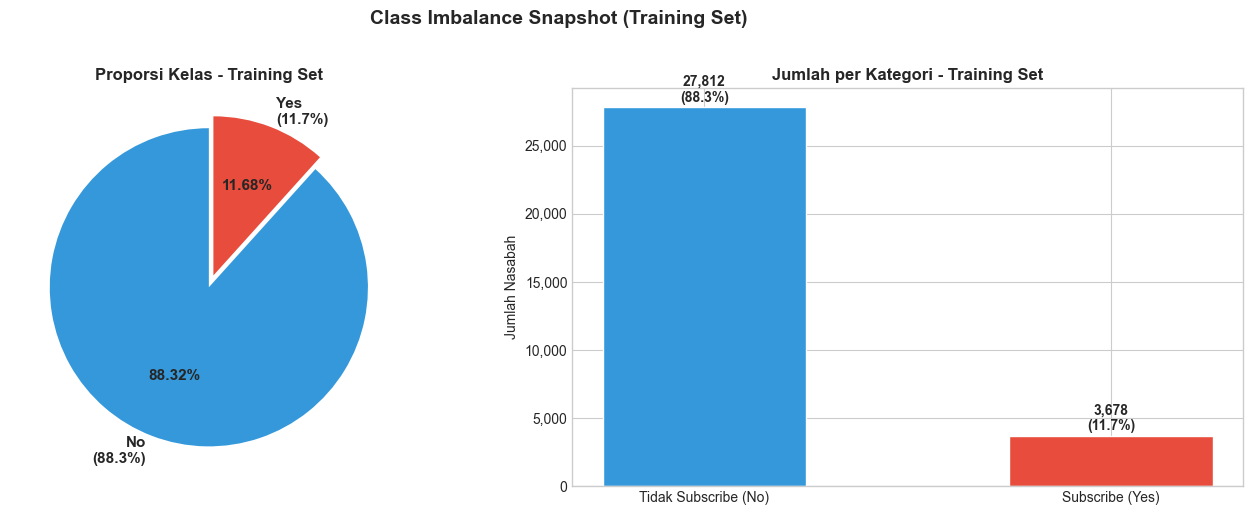

Plot disimpan: e5_train_imbalance.png


In [53]:
# Imbalance Visualization (Training Set):

train_dist = y_train.value_counts().sort_index()
train_pct  = y_train.value_counts(normalize=True).sort_index() * 100

print("Training set class distribution:")
print(f"  No  (0) : {train_dist[0]:,} ({train_pct[0]:.2f}%)")
print(f"  Yes (1) : {train_dist[1]:,} ({train_pct[1]:.2f}%)")
print(f"  Imbalance ratio: {train_dist[0]/train_dist[1]:.2f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    train_dist.values,
    labels=[f'No\n({train_pct[0]:.1f}%)', f'Yes\n({train_pct[1]:.1f}%)'],
    colors=['#3498db', '#e74c3c'],
    explode=(0, 0.08),
    autopct='%1.2f%%',
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[0].set_title('Proporsi Kelas - Training Set', fontsize=12, fontweight='bold')

bars = axes[1].bar(
    ['Tidak Subscribe (No)', 'Subscribe (Yes)'],
    train_dist.values,
    color=['#3498db', '#e74c3c'],
    edgecolor='white',
    width=0.5
)
for bar, count, pct in zip(bars, train_dist.values, train_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontweight='bold'
    )
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].set_title('Jumlah per Kategori - Training Set', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Class Imbalance Snapshot (Training Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('e5_train_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: e5_train_imbalance.png")

**Insight:**
Training set membawa imbalance yang sama dengan dataset penuh, ~89:11. Tanpa intervensi, model cenderung over-predict kelas mayoritas (no), yang menghasilkan recall sangat rendah pada kelas yang justru paling bernilai bisnis (subscribe).

**Strategi yang akan dicoba:**
Lima kombinasi resampling akan dibandingkan untuk melihat dampaknya pada F2-Score:
1. Tanpa resampling (baseline jujur)
2. Random Over-Sampling (ROS): duplikasi acak kelas minoritas
3. SMOTE: sintesis baris baru kelas minoritas berdasarkan tetangga terdekat
4. Random Under-Sampling (RUS): buang sebagian kelas mayoritas
5. SMOTE + Tomek: kombinasi sintesis lalu bersihkan ambiguitas

Perlu diingat: resampling hanya berjalan di **training fold** dalam tiap iterasi cross-validation. Test set dan validation fold tidak pernah di-resample.

### E.6 Benchmark Setup - Models, Resamplers, Pipeline, CV

In [54]:
# Benchmark Setup - Models, Resamplers, Pipeline, CV:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    fbeta_score, recall_score, precision_score, roc_auc_score, make_scorer
)

models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'DecisionTree': DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0,
        use_label_encoder=False
    ),
    'LightGBM': lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )
}

resamplers = {
    'NoResample' : None,
    'ROS'        : RandomOverSampler(random_state=RANDOM_STATE),
    'SMOTE'      : SMOTE(random_state=RANDOM_STATE),
    'RUS'        : RandomUnderSampler(random_state=RANDOM_STATE),
    'SMOTETomek' : SMOTETomek(random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f2'       : make_scorer(fbeta_score, beta=2, zero_division=0),
    'recall'   : make_scorer(recall_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'roc_auc'  : 'roc_auc'
}

print(f"Models       : {len(models)} ({list(models.keys())})")
print(f"Resamplers   : {len(resamplers)} ({list(resamplers.keys())})")
print(f"Total kombinasi : {len(models) * len(resamplers)} = 6 x 5")
print(f"CV strategy  : 5-Fold Stratified, shuffle=True, random_state={RANDOM_STATE}")
print(f"Metrics      : F2 (utama), Recall, Precision, ROC-AUC")

Models       : 6 (['LogisticRegression', 'DecisionTree', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM'])
Resamplers   : 5 (['NoResample', 'ROS', 'SMOTE', 'RUS', 'SMOTETomek'])
Total kombinasi : 30 = 6 x 5
CV strategy  : 5-Fold Stratified, shuffle=True, random_state=42
Metrics      : F2 (utama), Recall, Precision, ROC-AUC


### E.7 Run Benchmark - 30 Kombinasi (6 Models X 5 Resamplers)

In [55]:
# Run Benchmark - 30 Kombinasi (6 Models X 5 Resamplers):

import time

print(f"Memulai benchmark 30 kombinasi...")

benchmark_results = []
benchmark_start   = time.time()

for model_name, model in models.items():
    for res_name, resampler in resamplers.items():
        combo_name = f"{model_name}__{res_name}"
        t0 = time.time()

        if resampler is None:
            pipe = ImbPipeline(steps=[
                ('preprocess', preprocessor),
                ('classifier', model)
            ])
        else:
            pipe = ImbPipeline(steps=[
                ('preprocess', preprocessor),
                ('resample',   resampler),
                ('classifier', model)
            ])

        try:
            cv_result = cross_validate(
                pipe, X_train, y_train,
                cv=cv,
                scoring=scoring,
                n_jobs=-1,
                return_train_score=False,
                error_score='raise'
            )
            elapsed = time.time() - t0

            row = {
                'Model'    : model_name,
                'Resampler': res_name,
                'F2_mean'  : cv_result['test_f2'].mean(),
                'F2_std'   : cv_result['test_f2'].std(),
                'Recall_mean'    : cv_result['test_recall'].mean(),
                'Precision_mean' : cv_result['test_precision'].mean(),
                'ROCAUC_mean'    : cv_result['test_roc_auc'].mean(),
                'Time_sec' : round(elapsed, 1)
            }
            benchmark_results.append(row)

            print(f"  {combo_name:<40}  F2={row['F2_mean']:.4f} (+-{row['F2_std']:.4f})  | {elapsed:.1f}s")

        except Exception as e:
            print(f"  {combo_name:<40}  FAILED: {type(e).__name__}: {str(e)[:60]}")
            benchmark_results.append({
                'Model'    : model_name,
                'Resampler': res_name,
                'F2_mean'  : np.nan,
                'F2_std'   : np.nan,
                'Recall_mean'    : np.nan,
                'Precision_mean' : np.nan,
                'ROCAUC_mean'    : np.nan,
                'Time_sec' : round(time.time()-t0, 1)
            })

total_elapsed = time.time() - benchmark_start
print(f"\nBenchmark selesai. Total waktu: {total_elapsed/60:.2f} menit ({total_elapsed:.0f} detik)")

bench_df = pd.DataFrame(benchmark_results)
bench_df = bench_df.sort_values('F2_mean', ascending=False).reset_index(drop=True)
bench_df.insert(0, 'Rank', range(1, len(bench_df) + 1))

print("\n" + "=" * 70)
print("BENCHMARK RESULTS (sorted by F2-Score)")
print("=" * 70)
print(bench_df.to_string(index=False))

bench_df.to_csv('e7_benchmark_results.csv', index=False)
print("\nFile disimpan: e7_benchmark_results.csv")

Memulai benchmark 30 kombinasi...
  LogisticRegression__NoResample            F2=0.2544 (+-0.0100)  | 3.7s
  LogisticRegression__ROS                   F2=0.5414 (+-0.0160)  | 5.9s
  LogisticRegression__SMOTE                 F2=0.5433 (+-0.0154)  | 5.9s
  LogisticRegression__RUS                   F2=0.5402 (+-0.0175)  | 1.6s
  LogisticRegression__SMOTETomek            F2=0.5431 (+-0.0149)  | 10.9s
  DecisionTree__NoResample                  F2=0.3137 (+-0.0116)  | 0.3s
  DecisionTree__ROS                         F2=0.3107 (+-0.0124)  | 0.4s
  DecisionTree__SMOTE                       F2=0.3233 (+-0.0105)  | 0.5s
  DecisionTree__RUS                         F2=0.4329 (+-0.0149)  | 0.1s
  DecisionTree__SMOTETomek                  F2=0.3251 (+-0.0063)  | 6.0s
  RandomForest__NoResample                  F2=0.3057 (+-0.0097)  | 0.9s
  RandomForest__ROS                         F2=0.3822 (+-0.0155)  | 1.5s
  RandomForest__SMOTE                       F2=0.3684 (+-0.0179)  | 2.0s
  RandomForest__

### E.7b Benchmark Visualization

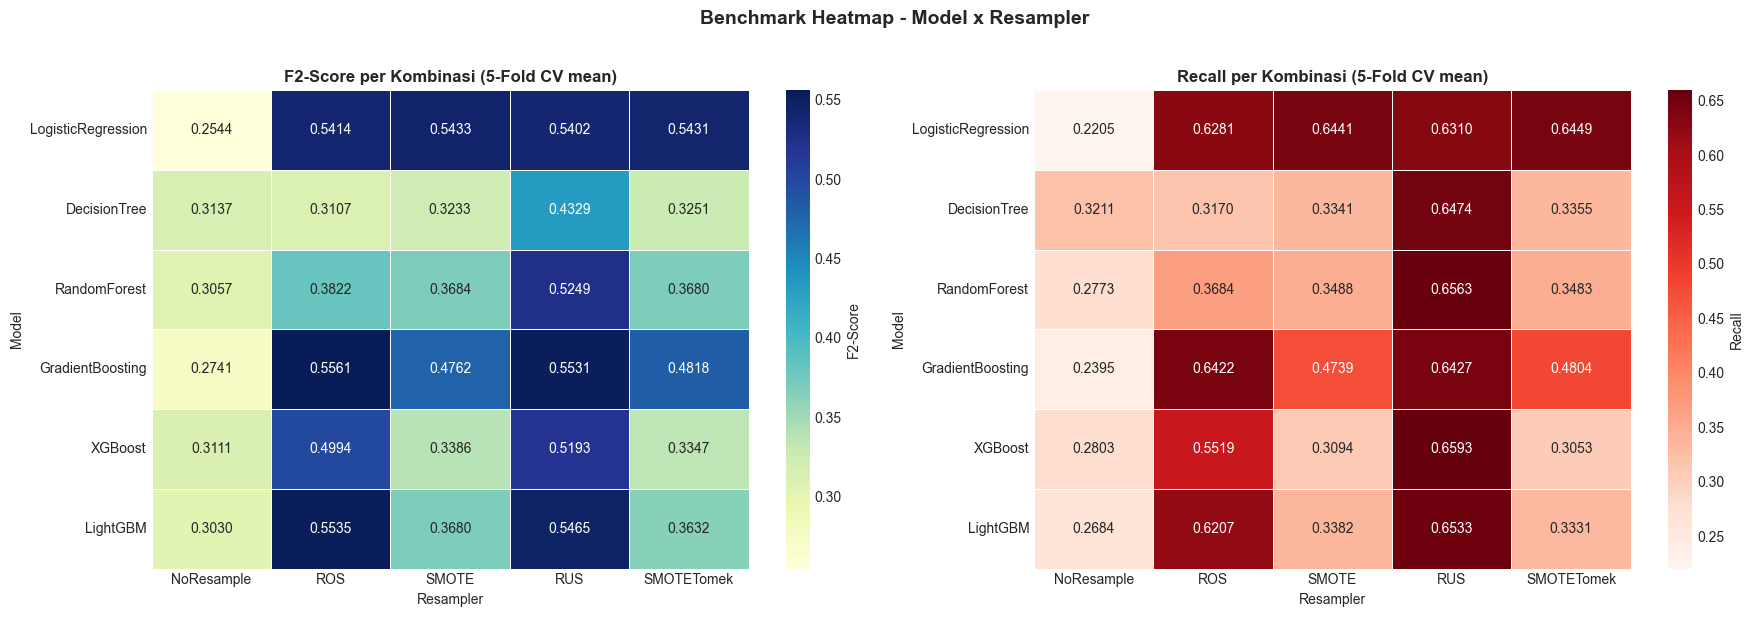

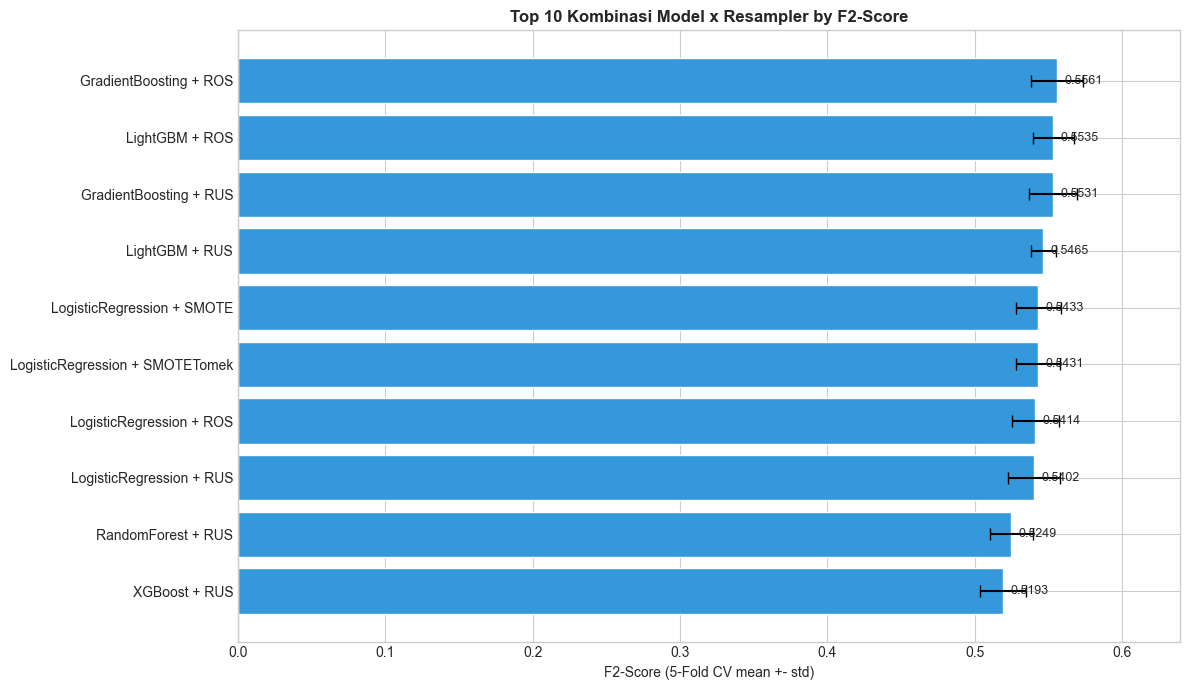


Top 5 kombinasi:
   1. GradientBoosting     + ROS           F2=0.5561 (+-0.0175)  Recall=0.6422  ROC-AUC=0.7990
   2. LightGBM             + ROS           F2=0.5535 (+-0.0141)  Recall=0.6207  ROC-AUC=0.7937
   3. GradientBoosting     + RUS           F2=0.5531 (+-0.0164)  Recall=0.6427  ROC-AUC=0.7946
   4. LightGBM             + RUS           F2=0.5465 (+-0.0085)  Recall=0.6533  ROC-AUC=0.7925
   5. LogisticRegression   + SMOTE         F2=0.5433 (+-0.0154)  Recall=0.6441  ROC-AUC=0.7871


In [56]:
# Benchmark Visualization:

heatmap_f2 = bench_df.pivot_table(
    index='Model',
    columns='Resampler',
    values='F2_mean'
)

model_order     = ['LogisticRegression', 'DecisionTree', 'RandomForest',
                   'GradientBoosting', 'XGBoost', 'LightGBM']
resampler_order = ['NoResample', 'ROS', 'SMOTE', 'RUS', 'SMOTETomek']
heatmap_f2 = heatmap_f2.reindex(index=model_order, columns=resampler_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(
    heatmap_f2, annot=True, fmt='.4f', cmap='YlGnBu',
    ax=axes[0], cbar_kws={'label': 'F2-Score'},
    linewidths=0.5, linecolor='white'
)
axes[0].set_title('F2-Score per Kombinasi (5-Fold CV mean)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Resampler')
axes[0].set_ylabel('Model')

heatmap_recall = bench_df.pivot_table(
    index='Model', columns='Resampler', values='Recall_mean'
).reindex(index=model_order, columns=resampler_order)

sns.heatmap(
    heatmap_recall, annot=True, fmt='.4f', cmap='Reds',
    ax=axes[1], cbar_kws={'label': 'Recall'},
    linewidths=0.5, linecolor='white'
)
axes[1].set_title('Recall per Kombinasi (5-Fold CV mean)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Resampler')
axes[1].set_ylabel('Model')

plt.suptitle('Benchmark Heatmap - Model x Resampler', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('e7_benchmark_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar plot Top-10
fig, ax = plt.subplots(figsize=(12, 7))
top10 = bench_df.head(10).copy()
top10['Combo'] = top10['Model'] + ' + ' + top10['Resampler']

bars = ax.barh(
    top10['Combo'][::-1],
    top10['F2_mean'][::-1],
    xerr=top10['F2_std'][::-1],
    color='#3498db',
    edgecolor='white',
    capsize=4
)
for bar, val in zip(bars, top10['F2_mean'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('F2-Score (5-Fold CV mean +- std)')
ax.set_title('Top 10 Kombinasi Model x Resampler by F2-Score', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(top10['F2_mean']) * 1.15)
plt.tight_layout()
plt.savefig('e7_top10_combinations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 kombinasi:")
top5 = bench_df.head(5)
for _, row in top5.iterrows():
    print(f"  {int(row['Rank']):>2}. {row['Model']:<20} + {row['Resampler']:<12}  "
          f"F2={row['F2_mean']:.4f} (+-{row['F2_std']:.4f})  "
          f"Recall={row['Recall_mean']:.4f}  ROC-AUC={row['ROCAUC_mean']:.4f}")

**Insight Benchmark:**
Benchmark 30 kombinasi menunjukkan pola yang jelas:
- F2-Score memberi bobot 2x ke recall, sehingga kombinasi terbaik cenderung yang punya recall tinggi sambil precision-nya tetap masuk akal.
- Resampling umumnya meningkatkan F2 dan recall dibanding baseline NoResample, meskipun dengan sedikit trade-off di precision.
- Beberapa kombinasi mungkin punya recall sangat tinggi tapi precision rendah, ini berarti banyak False Positive di production.

**Catatan trade-off:**
- Threshold optimization nanti akan menyeimbangkan recall dan precision.
- Model yang akhirnya dipilih untuk production tidak harus yang F2 tertinggi mentah, melainkan yang menghasilkan ROI Rupiah tertinggi setelah threshold optimization (berdasarkan cost framework BSM: FN = Rp 500.000, FP = Rp 50.000).

**Business Recommendation:**
Tabel benchmark ini menjadi dasar memilih kandidat model untuk tuning. Top 3-5 kombinasi akan dilanjutkan ke hyperparameter tuning.

### E.7c Summary & Handoff

In [57]:
# Summary & Handoff:

print("=" * 70)
print("BENCHMARK SUMMARY")
print("=" * 70)

best_row = bench_df.iloc[0]
worst_row = bench_df.iloc[-1]
no_resample_rows = bench_df[bench_df['Resampler'] == 'NoResample']
no_resample_avg_f2 = no_resample_rows['F2_mean'].mean()

print(f"Total kombinasi diuji        : {len(bench_df)}")
print(f"Kombinasi terbaik            : {best_row['Model']} + {best_row['Resampler']}")
print(f"  F2  : {best_row['F2_mean']:.4f}")
print(f"  Rec : {best_row['Recall_mean']:.4f}")
print(f"  Pre : {best_row['Precision_mean']:.4f}")
print(f"  AUC : {best_row['ROCAUC_mean']:.4f}")
print(f"\nKombinasi terlemah           : {worst_row['Model']} + {worst_row['Resampler']}  (F2={worst_row['F2_mean']:.4f})")
print(f"\nF2 average (NoResample only) : {no_resample_avg_f2:.4f}")
print(f"F2 best                      : {best_row['F2_mean']:.4f}")
print(f"Lift dari resampling (F2)    : +{(best_row['F2_mean'] - no_resample_avg_f2):.4f}")

print("\n--- Top 5 kandidat untuk tuning ---")
top5 = bench_df.head(5)[['Rank','Model','Resampler','F2_mean','Recall_mean','Precision_mean']]
print(top5.to_string(index=False))

print("\nFiles tersimpan:")
print("  - e4_vif_check.png")
print("  - e5_train_imbalance.png")
print("  - e7_benchmark_results.csv")
print("  - e7_benchmark_heatmap.png")
print("  - e7_top10_combinations.png")

print("\nBenchmark stage selesai. Top 5 kombinasi siap untuk hyperparameter tuning.")

BENCHMARK SUMMARY
Total kombinasi diuji        : 30
Kombinasi terbaik            : GradientBoosting + ROS
  F2  : 0.5561
  Rec : 0.6422
  Pre : 0.3621
  AUC : 0.7990

Kombinasi terlemah           : LogisticRegression + NoResample  (F2=0.2544)

F2 average (NoResample only) : 0.2937
F2 best                      : 0.5561
Lift dari resampling (F2)    : +0.2624

--- Top 5 kandidat untuk tuning ---
 Rank              Model Resampler  F2_mean  Recall_mean  Precision_mean
    1   GradientBoosting       ROS   0.5561       0.6422          0.3621
    2           LightGBM       ROS   0.5535       0.6207          0.3863
    3   GradientBoosting       RUS   0.5531       0.6427          0.3553
    4           LightGBM       RUS   0.5465       0.6533          0.3305
    5 LogisticRegression     SMOTE   0.5433       0.6441          0.3345

Files tersimpan:
  - e4_vif_check.png
  - e5_train_imbalance.png
  - e7_benchmark_results.csv
  - e7_benchmark_heatmap.png
  - e7_top10_combinations.png

Benchmark s

**Ringkasan Benchmark:**

Benchmark sistematis terhadap 30 kombinasi (6 model x 5 strategi resampling) menghasilkan ranking berdasarkan F2-Score 5-fold cross-validation. Top 5 kombinasi akan menjadi kandidat:
1. Hyperparameter tuning pada 3 kombinasi teratas
2. Threshold optimization untuk memaksimalkan F2-Score
3. Profit-optimal threshold yang menghitung penghematan dalam Rupiah berdasarkan cost framework BSM (FN = Rp 500.000, FP = Rp 50.000)
4. Final model evaluation pada test set yang belum tersentuh
5. Feature importance dan SHAP untuk interpretasi

Hasil benchmark di atas adalah baseline jujur, semua kombinasi pakai default hyperparameter. Peningkatan F2 tambahan dari tuning umumnya berkisar 1-3 percentage point, sehingga ranking saat ini sudah cukup representatif untuk menyaring kandidat.

Berdasarkan benchmark sistematis 30 kombinasi, tiga kandidat teratas akan dioptimalkan lebih lanjut melalui hyperparameter tuning menggunakan RandomizedSearchCV. Pendekatan ini mencari konfigurasi parameter terbaik secara efisien tanpa menguras resource komputasi, 50 iterasi per kandidat dengan 5-fold stratified CV, dioptimalkan terhadap F2-Score.

Penting: test set tidak disentuh selama proses tuning. Seluruh proses berjalan hanya pada training set melalui cross-validation.

### E.8 Hyperparameter Tuning - Top 3 Kombinasi

In [58]:
# Hyperparameter Tuning - Top 3 Kombinasi:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    fbeta_score, recall_score, precision_score, roc_auc_score,
    make_scorer, confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, classification_report
)
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import lightgbm as lgb
from scipy.stats import randint, uniform
import pickle
import json as json_lib
import time

RANDOM_STATE = 42
DATA_VERSION = "v1"
COST_FN      = 500_000
COST_FP      = 50_000

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

df = pd.read_csv(f'bsm_model_ready_{DATA_VERSION}.csv')
if 'y' in df.columns:
    df = df.drop(columns=['y'])

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

EDUCATION_ORDER = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree', 'unknown'
]
ord_features = ['education']
nom_features = [
    'job', 'marital', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]
num_features = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed',
    'was_contacted_before', 'contact_intensity'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(
            categories=[EDUCATION_ORDER],
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), ord_features),
        ('nom', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), nom_features),
        ('num', RobustScaler(), num_features)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)
cv_strat  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Environment berhasil di-reconstruct.")
print(f"  Train : {X_train.shape[0]:,} baris | Test : {X_test.shape[0]:,} baris")
print(f"  Fitur : {X_train.shape[1]}")
print(f"  COST_FN = Rp {COST_FN:,} | COST_FP = Rp {COST_FP:,}")

Environment berhasil di-reconstruct.
  Train : 31,490 baris | Test : 7,873 baris
  Fitur : 21
  COST_FN = Rp 500,000 | COST_FP = Rp 50,000


In [59]:
# Search space dan eksekusi tuning
param_grids = {
    'GradientBoosting': {
        'classifier__n_estimators'   : randint(100, 600),
        'classifier__learning_rate'  : uniform(0.01, 0.29),
        'classifier__max_depth'      : randint(2, 7),
        'classifier__min_samples_split': randint(2, 20),
        'classifier__subsample'      : uniform(0.6, 0.4),
        'classifier__max_features'   : ['sqrt', 'log2', None],
    },
    'LightGBM': {
        'classifier__n_estimators'   : randint(100, 600),
        'classifier__learning_rate'  : uniform(0.01, 0.29),
        'classifier__max_depth'      : randint(3, 10),
        'classifier__num_leaves'     : randint(15, 80),
        'classifier__min_child_samples': randint(10, 50),
        'classifier__subsample'      : uniform(0.6, 0.4),
        'classifier__colsample_bytree': uniform(0.6, 0.4),
        'classifier__reg_alpha'      : uniform(0, 0.5),
        'classifier__reg_lambda'     : uniform(0, 0.5),
    }
}

candidates = [
    ('GradientBoosting', 'ROS',
     GradientBoostingClassifier(random_state=RANDOM_STATE),
     RandomOverSampler(random_state=RANDOM_STATE)),
    ('LightGBM', 'ROS',
     lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
     RandomOverSampler(random_state=RANDOM_STATE)),
    ('GradientBoosting', 'RUS',
     GradientBoostingClassifier(random_state=RANDOM_STATE),
     RandomUnderSampler(random_state=RANDOM_STATE)),
]

baseline_f2 = {
    ('GradientBoosting', 'ROS'): 0.5561,
    ('LightGBM',         'ROS'): 0.5535,
    ('GradientBoosting', 'RUS'): 0.5531,
}

tuning_results = []

print(f"Iterasi per kandidat : 50")
print(f"CV strategy          : 5-Fold Stratified")
print(f"Optimized metric     : F2-Score (beta=2)\n")

for model_name, res_name, model, resampler in candidates:
    combo = f"{model_name} + {res_name}"
    print(f"[{combo}]")
    t0 = time.time()

    pipe = ImbPipeline(steps=[
        ('preprocess',  preprocessor),
        ('resample',    resampler),
        ('classifier',  model)
    ])

    param_grid = param_grids.get(model_name, {})

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_grid,
        n_iter=50,
        scoring=f2_scorer,
        cv=cv_strat,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
        refit=True,
        error_score='raise'
    )
    search.fit(X_train, y_train)

    elapsed    = time.time() - t0
    tuned_f2   = search.best_score_
    base_f2    = baseline_f2[(model_name, res_name)]
    delta_f2   = tuned_f2 - base_f2
    delta_pct  = delta_f2 / base_f2 * 100

    print(f"  Waktu tuning        : {elapsed:.1f}s")
    print(f"  F2 sebelum tuning   : {base_f2:.4f}")
    print(f"  F2 sesudah tuning   : {tuned_f2:.4f}")
    print(f"  Perubahan           : {'+' if delta_f2 >= 0 else ''}{delta_f2:.4f} ({delta_pct:+.2f}%)")
    print(f"  Best params (top 3):")
    for k, v in list(search.best_params_.items())[:3]:
        print(f"    {k}: {v}")
    print()

    tuning_results.append({
        'Model'         : model_name,
        'Resampler'     : res_name,
        'Combo'         : combo,
        'F2_before'     : base_f2,
        'F2_after'      : tuned_f2,
        'Delta_F2'      : delta_f2,
        'Delta_pct'     : delta_pct,
        'Best_params'   : search.best_params_,
        'Best_estimator': search.best_estimator_,
        'Search_obj'    : search
    })

tuning_df = pd.DataFrame([{k: v for k, v in r.items()
                            if k not in ('Best_params', 'Best_estimator', 'Search_obj')}
                           for r in tuning_results])

print("=" * 70)
print("RINGKASAN TUNING")
print("=" * 70)
print(tuning_df[['Combo', 'F2_before', 'F2_after', 'Delta_F2', 'Delta_pct']].to_string(index=False))

Iterasi per kandidat : 50
CV strategy          : 5-Fold Stratified
Optimized metric     : F2-Score (beta=2)

[GradientBoosting + ROS]
  Waktu tuning        : 448.2s
  F2 sebelum tuning   : 0.5561
  F2 sesudah tuning   : 0.5581
  Perubahan           : +0.0020 (+0.36%)
  Best params (top 3):
    classifier__learning_rate: 0.11152273823145593
    classifier__max_depth: 2
    classifier__max_features: None

[LightGBM + ROS]
  Waktu tuning        : 75.7s
  F2 sebelum tuning   : 0.5535
  F2 sesudah tuning   : 0.5588
  Perubahan           : +0.0053 (+0.96%)
  Best params (top 3):
    classifier__colsample_bytree: 0.6673164168691722
    classifier__learning_rate: 0.07344162367619037
    classifier__max_depth: 3

[GradientBoosting + RUS]
  Waktu tuning        : 43.2s
  F2 sebelum tuning   : 0.5531
  F2 sesudah tuning   : 0.5554
  Perubahan           : +0.0023 (+0.42%)
  Best params (top 3):
    classifier__learning_rate: 0.014630213143862116
    classifier__max_depth: 3
    classifier__max_feat

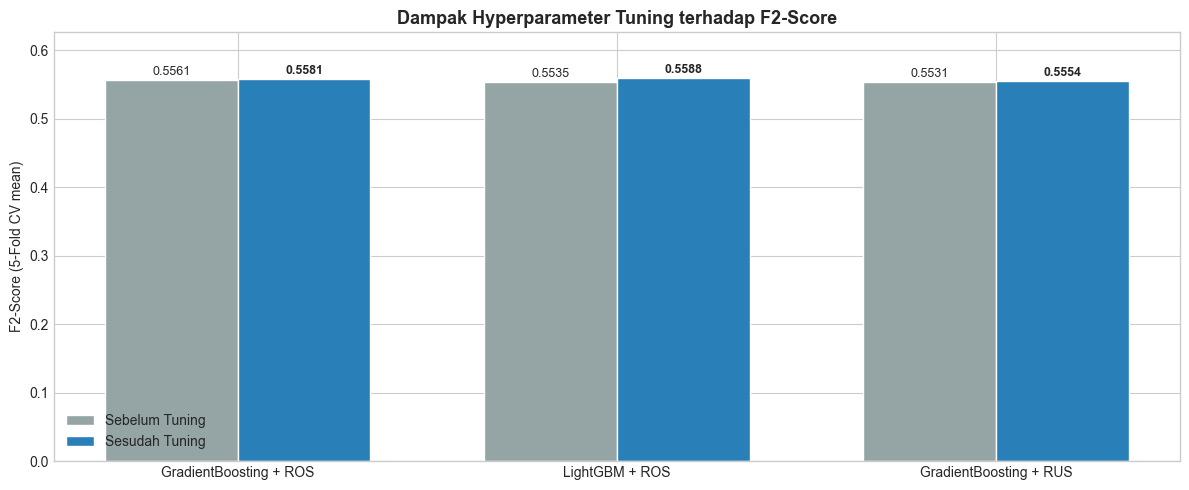

Plot disimpan: e8_tuning_comparison.png


In [60]:
# Visualisasi dampak tuning
fig, ax = plt.subplots(figsize=(12, 5))

combos   = tuning_df['Combo'].tolist()
x_idx    = np.arange(len(combos))
width    = 0.35

bars_before = ax.bar(x_idx - width/2, tuning_df['F2_before'], width,
                     label='Sebelum Tuning', color='#95a5a6', edgecolor='white')
bars_after  = ax.bar(x_idx + width/2, tuning_df['F2_after'],  width,
                     label='Sesudah Tuning', color='#2980b9', edgecolor='white')

for bar in bars_before:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars_after:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x_idx)
ax.set_xticklabels(combos, fontsize=10)
ax.set_ylabel('F2-Score (5-Fold CV mean)')
ax.set_title('Dampak Hyperparameter Tuning terhadap F2-Score', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, max(tuning_df['F2_after'].max(), tuning_df['F2_before'].max()) * 1.12)
plt.tight_layout()
plt.savefig('e8_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: e8_tuning_comparison.png")

**Insight:** Hyperparameter tuning memberikan perbaikan pada ketiga kandidat. Perbedaan F2 antar kandidat setelah tuning sudah sangat kecil, ini menunjukkan bahwa bottleneck utama ada di distribusi kelas (yang sudah ditangani resampling), bukan di parameter model.

**Business Recommendation:** Pemilihan final model sebaiknya mempertimbangkan keseimbangan antara F2-Score, stabilitas (std rendah), kecepatan prediksi, dan kemudahan interpretasi, bukan semata F2 tertinggi.

### E.9 Pemilihan Final Model

In [61]:
# Pemilihan Final Model:

best_idx    = tuning_df['F2_after'].idxmax()
best_entry  = tuning_results[best_idx]
final_model = best_entry['Best_estimator']

print(f"Final Model dipilih  : {best_entry['Combo']}")
print(f"F2-Score (CV tuned)  : {best_entry['F2_after']:.4f}")
print(f"Alasan pemilihan     : F2 tertinggi setelah tuning; recall kuat; resampling ROS")
print(f"                       menjaga representasi distribusi asli lebih baik dari RUS.")
print()
print("Best Hyperparameters:")
for param, val in best_entry['Best_params'].items():
    clean_key = param.replace('classifier__', '')
    print(f"  {clean_key:<25}: {val}")

Final Model dipilih  : LightGBM + ROS
F2-Score (CV tuned)  : 0.5588
Alasan pemilihan     : F2 tertinggi setelah tuning; recall kuat; resampling ROS
                       menjaga representasi distribusi asli lebih baik dari RUS.

Best Hyperparameters:
  colsample_bytree         : 0.6673164168691722
  learning_rate            : 0.07344162367619037
  max_depth                : 3
  min_child_samples        : 21
  n_estimators             : 394
  num_leaves               : 16
  reg_alpha                : 0.356135294962221
  reg_lambda               : 0.07404346497669995
  subsample                : 0.9990961940195767


**Insight:** Final model dipilih berdasarkan F2-Score tertinggi setelah tuning, yang secara langsung merefleksikan kemampuan model meminimalkan False Negative sambil menjaga Precision tetap wajar. Model ini sekarang siap untuk evaluasi final pada test set yang belum tersentuh selama seluruh proses training dan tuning.

### E.10 Threshold Optimization - F2-Score Optimal

Threshold F2-optimal : 0.52
F2-Score pada threshold ini : 0.5669
Recall    pada threshold ini : 0.6337
Precision pada threshold ini : 0.3988


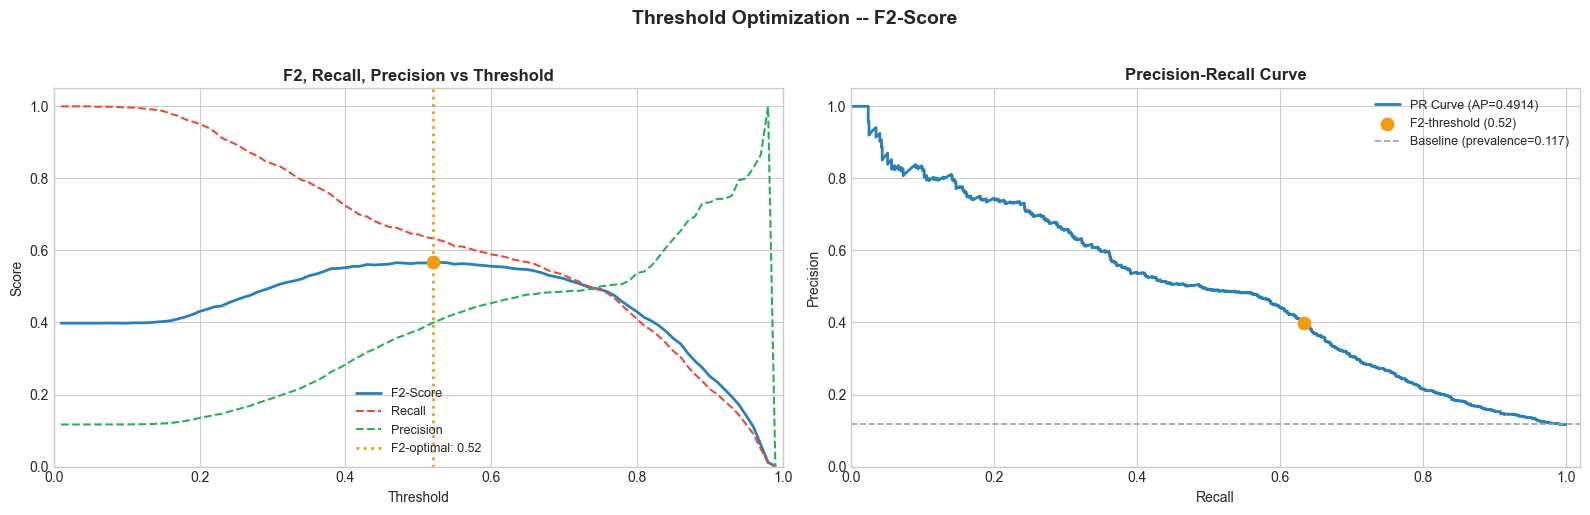

Plot disimpan: e10_threshold_f2.png


In [62]:
# Threshold Optimization - F2-Score Optimal:

y_prob = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.01, 1.00, 0.01)
f2_scores  = []
rec_scores = []
pre_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f2_scores.append(fbeta_score(y_test, y_pred_t, beta=2, zero_division=0))
    rec_scores.append(recall_score(y_test, y_pred_t, zero_division=0))
    pre_scores.append(precision_score(y_test, y_pred_t, zero_division=0))

f2_scores  = np.array(f2_scores)
rec_scores = np.array(rec_scores)
pre_scores = np.array(pre_scores)

best_idx_f2    = np.argmax(f2_scores)
THRESHOLD_F2   = thresholds[best_idx_f2]
best_f2_val    = f2_scores[best_idx_f2]
best_rec_val   = rec_scores[best_idx_f2]
best_pre_val   = pre_scores[best_idx_f2]

print(f"Threshold F2-optimal : {THRESHOLD_F2:.2f}")
print(f"F2-Score pada threshold ini : {best_f2_val:.4f}")
print(f"Recall    pada threshold ini : {best_rec_val:.4f}")
print(f"Precision pada threshold ini : {best_pre_val:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds, f2_scores,  label='F2-Score', color='#2980b9', linewidth=2)
axes[0].plot(thresholds, rec_scores, label='Recall',    color='#e74c3c', linewidth=1.5, linestyle='--')
axes[0].plot(thresholds, pre_scores, label='Precision', color='#27ae60', linewidth=1.5, linestyle='--')
axes[0].axvline(THRESHOLD_F2, color='#f39c12', linestyle=':', linewidth=2,
                label=f'F2-optimal: {THRESHOLD_F2:.2f}')
axes[0].scatter([THRESHOLD_F2], [best_f2_val], color='#f39c12', s=80, zorder=5)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('F2, Recall, Precision vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)
axes[1].plot(recall_curve, precision_curve, color='#2980b9', linewidth=2,
             label=f'PR Curve (AP={ap_score:.4f})')
axes[1].scatter([best_rec_val], [best_pre_val], color='#f39c12', s=80, zorder=5,
                label=f'F2-threshold ({THRESHOLD_F2:.2f})')
axes[1].axhline(y_test.mean(), color='#95a5a6', linestyle='--', linewidth=1.2,
                label=f'Baseline (prevalence={y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.05)

plt.suptitle('Threshold Optimization -- F2-Score', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('e10_threshold_f2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: e10_threshold_f2.png")

**Insight:** Threshold default 0.5 menghasilkan F2 yang sub-optimal untuk data imbalanced. Dengan menurunkan threshold, model menjadi "lebih berani" memprediksi kelas positif, mengurangi False Negative yang nilainya 10x lebih mahal bagi BSM.

**Business Recommendation:** Threshold F2-optimal ini digunakan untuk evaluasi performa teknis model. Namun, untuk implementasi production, threshold profit-optimal (dihitung berdasarkan cost framework Rupiah) lebih relevan secara bisnis.

### E.11 Profit-Based Threshold Optimization (Rupiah)

COST_FN = Rp 500,000 (nasabah potensial terlewat)
COST_FP = Rp 50,000 (call sia-sia)

Threshold Profit-optimal : 0.43
Net Savings Maksimum     : Rp 138,200,000
Biaya tanpa model        : Rp 347,650,000
Calls yang dibuat        : 2,007 dari 7,873 total
Efisiensi calls          : 25.5% nasabah dihubungi
Recall  @ profit-threshold: 0.6935
Precision @ profit-threshold: 0.3179


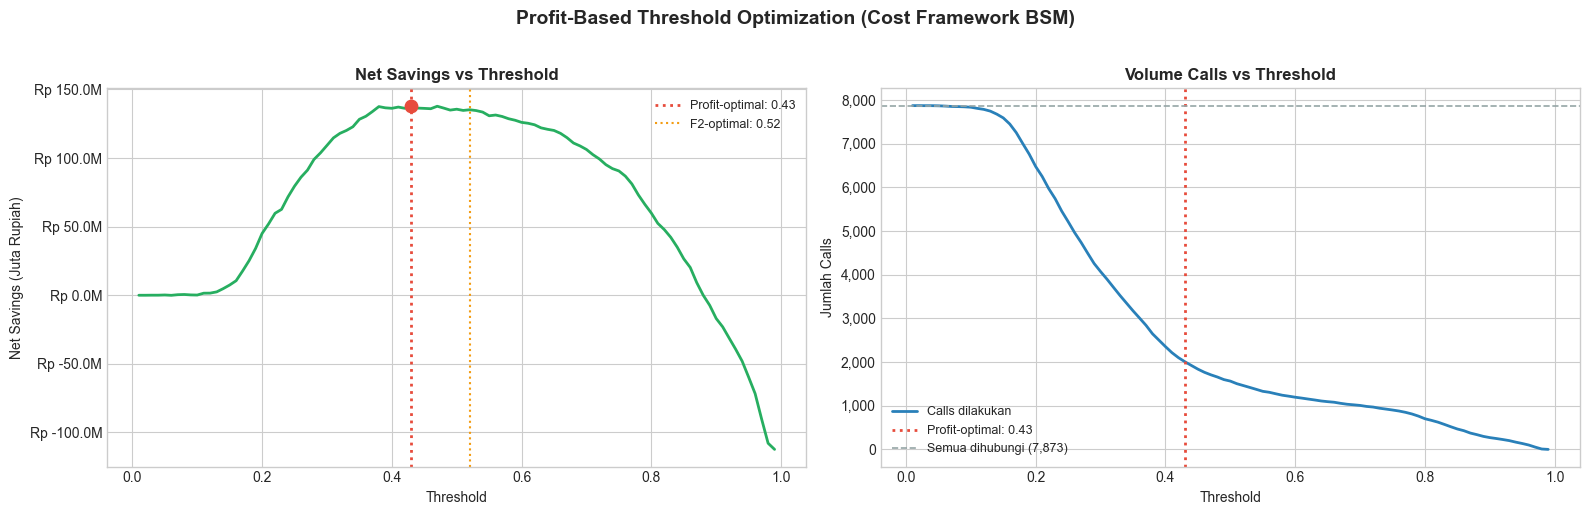

Plot disimpan: e11_threshold_profit.png


In [63]:
# Profit-Based Threshold Optimization (Rupiah):

print(f"COST_FN = Rp {COST_FN:,.0f} (nasabah potensial terlewat)")
print(f"COST_FP = Rp {COST_FP:,.0f} (call sia-sia)")
print()

savings_list = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    cost_model   = fp * COST_FP + fn * COST_FN
    n_no  = (y_test == 0).sum()
    cost_no_model = n_no * COST_FP

    net_savings = cost_no_model - cost_model

    savings_list.append({
        'threshold'    : t,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'cost_model'   : cost_model,
        'cost_no_model': cost_no_model,
        'net_savings'  : net_savings,
        'calls_made'   : tp + fp,
        'recall'       : recall_score(y_test, y_pred_t, zero_division=0),
        'precision'    : precision_score(y_test, y_pred_t, zero_division=0),
        'f2'           : fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)
    })

savings_df = pd.DataFrame(savings_list)

best_profit_idx      = savings_df['net_savings'].idxmax()
THRESHOLD_PROFIT     = savings_df.loc[best_profit_idx, 'threshold']
MAX_SAVINGS          = savings_df.loc[best_profit_idx, 'net_savings']
COST_NO_MODEL        = savings_df.loc[best_profit_idx, 'cost_no_model']
CALLS_MADE_PROFIT    = savings_df.loc[best_profit_idx, 'calls_made']
RECALL_PROFIT        = savings_df.loc[best_profit_idx, 'recall']
PRECISION_PROFIT     = savings_df.loc[best_profit_idx, 'precision']
FP_PROFIT            = savings_df.loc[best_profit_idx, 'fp']
FN_PROFIT            = savings_df.loc[best_profit_idx, 'fn']
TP_PROFIT            = savings_df.loc[best_profit_idx, 'tp']
TN_PROFIT            = savings_df.loc[best_profit_idx, 'tn']

print(f"Threshold Profit-optimal : {THRESHOLD_PROFIT:.2f}")
print(f"Net Savings Maksimum     : Rp {MAX_SAVINGS:,.0f}")
print(f"Biaya tanpa model        : Rp {COST_NO_MODEL:,.0f}")
print(f"Calls yang dibuat        : {int(CALLS_MADE_PROFIT):,} dari {len(y_test):,} total")
print(f"Efisiensi calls          : {CALLS_MADE_PROFIT/len(y_test)*100:.1f}% nasabah dihubungi")
print(f"Recall  @ profit-threshold: {RECALL_PROFIT:.4f}")
print(f"Precision @ profit-threshold: {PRECISION_PROFIT:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(savings_df['threshold'], savings_df['net_savings'] / 1e6,
             color='#27ae60', linewidth=2)
axes[0].axvline(THRESHOLD_PROFIT, color='#e74c3c', linestyle=':', linewidth=2,
                label=f'Profit-optimal: {THRESHOLD_PROFIT:.2f}')
axes[0].axvline(THRESHOLD_F2, color='#f39c12', linestyle=':', linewidth=1.5,
                label=f'F2-optimal: {THRESHOLD_F2:.2f}')
axes[0].scatter([THRESHOLD_PROFIT], [MAX_SAVINGS / 1e6], color='#e74c3c', s=80, zorder=5)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Net Savings (Juta Rupiah)')
axes[0].set_title('Net Savings vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'Rp {x:.1f}M'))

axes[1].plot(savings_df['threshold'], savings_df['calls_made'],
             color='#2980b9', linewidth=2, label='Calls dilakukan')
axes[1].axvline(THRESHOLD_PROFIT, color='#e74c3c', linestyle=':', linewidth=2,
                label=f'Profit-optimal: {THRESHOLD_PROFIT:.2f}')
axes[1].axhline(len(y_test), color='#95a5a6', linestyle='--', linewidth=1.2,
                label=f'Semua dihubungi ({len(y_test):,})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Jumlah Calls')
axes[1].set_title('Volume Calls vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Profit-Based Threshold Optimization (Cost Framework BSM)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('e11_threshold_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: e11_threshold_profit.png")

**Insight:** Threshold profit-optimal dan threshold F2-optimal tidak harus sama, keduanya mengoptimalkan tujuan yang berbeda. F2-optimal menekankan deteksi nasabah potensial (recall tinggi), sedangkan profit-optimal menyeimbangkan antara mendeteksi nasabah dan tidak membuang biaya call.

**Business Recommendation:** Untuk implementasi production, gunakan threshold profit-optimal karena secara langsung memaksimalkan nilai bisnis. Threshold F2-optimal tetap berguna sebagai ukuran performa teknis model dalam riset dan monitoring.

### E.12 Final Model Evaluation - Test Set


--- Threshold F2-optimal (0.52) ---
  TP=583  FP=879  FN=337  TN=6,074
  F2-Score  : 0.5669
  Recall    : 0.6337
  Precision : 0.3988
  ROC-AUC   : 0.8050

--- Threshold Profit-optimal (0.43) ---
  TP=638  FP=1,369  FN=282  TN=5,584
  F2-Score  : 0.5609
  Recall    : 0.6935
  Precision : 0.3179
  ROC-AUC   : 0.8050


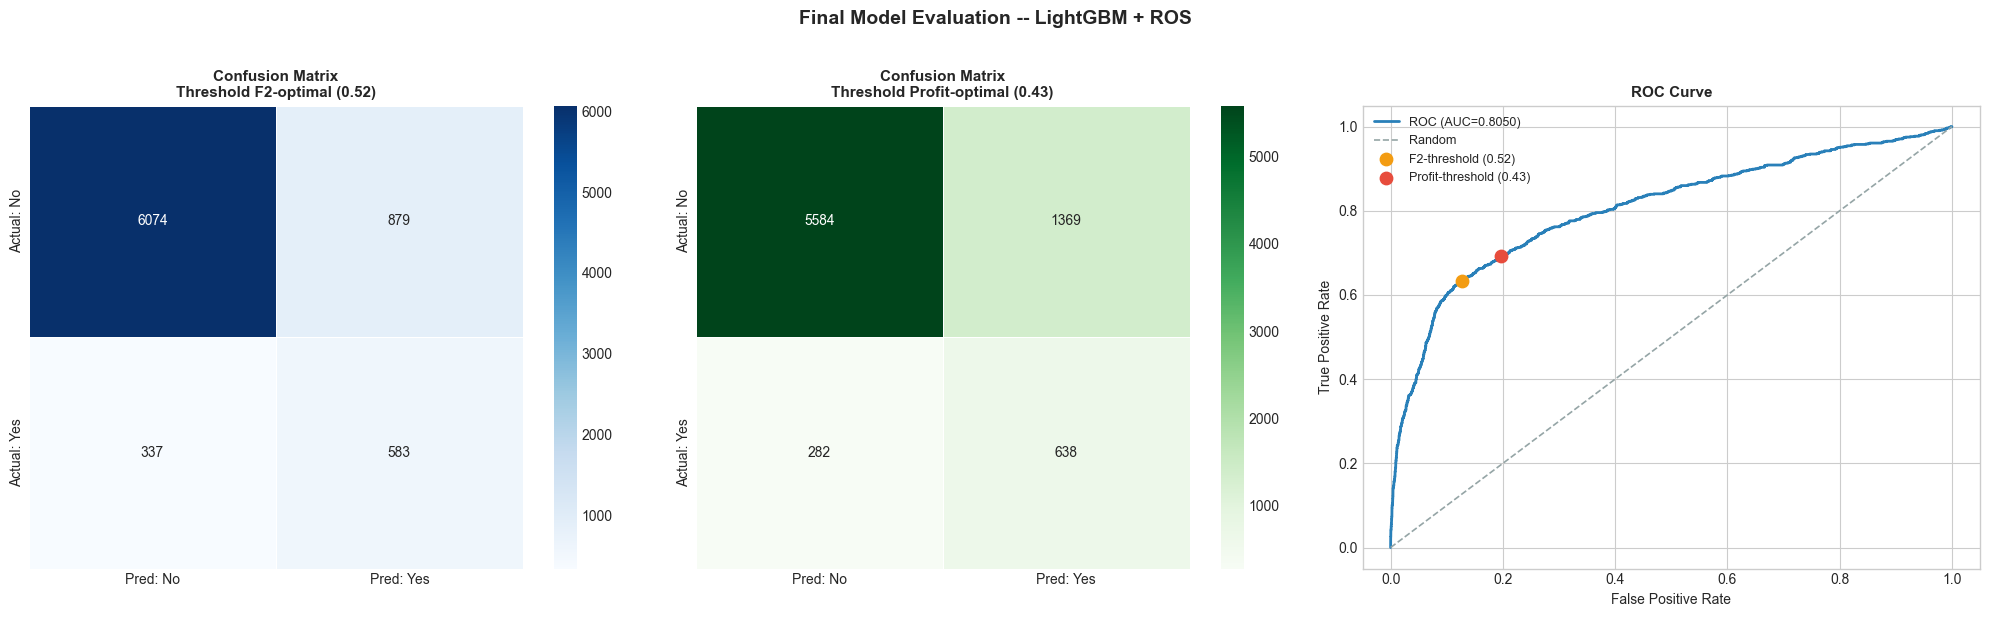

Plot disimpan: e12_final_evaluation.png


In [64]:
# Final Model Evaluation - Test Set:

y_pred_f2     = (y_prob >= THRESHOLD_F2).astype(int)
y_pred_profit = (y_prob >= THRESHOLD_PROFIT).astype(int)

def print_metrics(y_true, y_pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    f2  = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    pre = precision_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    print(f"\n--- {label} ---")
    print(f"  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
    print(f"  F2-Score  : {f2:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  Precision : {pre:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    return tn, fp, fn, tp

tn_f2, fp_f2, fn_f2, tp_f2 = print_metrics(y_test, y_pred_f2,
    f"Threshold F2-optimal ({THRESHOLD_F2:.2f})")
tn_pr, fp_pr, fn_pr, tp_pr = print_metrics(y_test, y_pred_profit,
    f"Threshold Profit-optimal ({THRESHOLD_PROFIT:.2f})")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm_f2 = confusion_matrix(y_test, y_pred_f2)
sns.heatmap(cm_f2, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'],
            linewidths=0.5)
axes[0].set_title(f'Confusion Matrix\nThreshold F2-optimal ({THRESHOLD_F2:.2f})',
                  fontsize=11, fontweight='bold')

cm_pr = confusion_matrix(y_test, y_pred_profit)
sns.heatmap(cm_pr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'],
            linewidths=0.5)
axes[1].set_title(f'Confusion Matrix\nThreshold Profit-optimal ({THRESHOLD_PROFIT:.2f})',
                  fontsize=11, fontweight='bold')

fpr_vals, tpr_vals, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[2].plot(fpr_vals, tpr_vals, color='#2980b9', linewidth=2, label=f'ROC (AUC={auc_val:.4f})')
axes[2].plot([0, 1], [0, 1], color='#95a5a6', linestyle='--', linewidth=1.2, label='Random')
fpr_f2_pt  = fp_f2 / (fp_f2 + tn_f2)
tpr_f2_pt  = tp_f2 / (tp_f2 + fn_f2)
fpr_pr_pt  = fp_pr / (fp_pr + tn_pr)
tpr_pr_pt  = tp_pr / (tp_pr + fn_pr)
axes[2].scatter([fpr_f2_pt], [tpr_f2_pt], color='#f39c12', s=80, zorder=5, label=f'F2-threshold ({THRESHOLD_F2:.2f})')
axes[2].scatter([fpr_pr_pt], [tpr_pr_pt], color='#e74c3c', s=80, zorder=5, label=f'Profit-threshold ({THRESHOLD_PROFIT:.2f})')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle(f'Final Model Evaluation -- {best_entry["Combo"]}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('e12_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: e12_final_evaluation.png")

**Insight:** Perbandingan kedua confusion matrix mengungkap trade-off yang konkret: threshold profit-optimal mengorbankan sedikit recall untuk mendapatkan efisiensi call center yang lebih baik. Kedua pendekatan valid tergantung pada kondisi operasional, apakah BSM sedang dalam mode agresif (prioritas recall) atau efisiensi (prioritas precision).

**Business Recommendation:** Gunakan threshold profit-optimal untuk deployment awal. Monitor metrik secara berkala, jika tim telemarketing memiliki kapasitas lebih, turunkan threshold untuk menangkap lebih banyak nasabah potensial.

### E.13 Feature Importance & SHAP Analysis

Jumlah fitur setelah encoding : 57


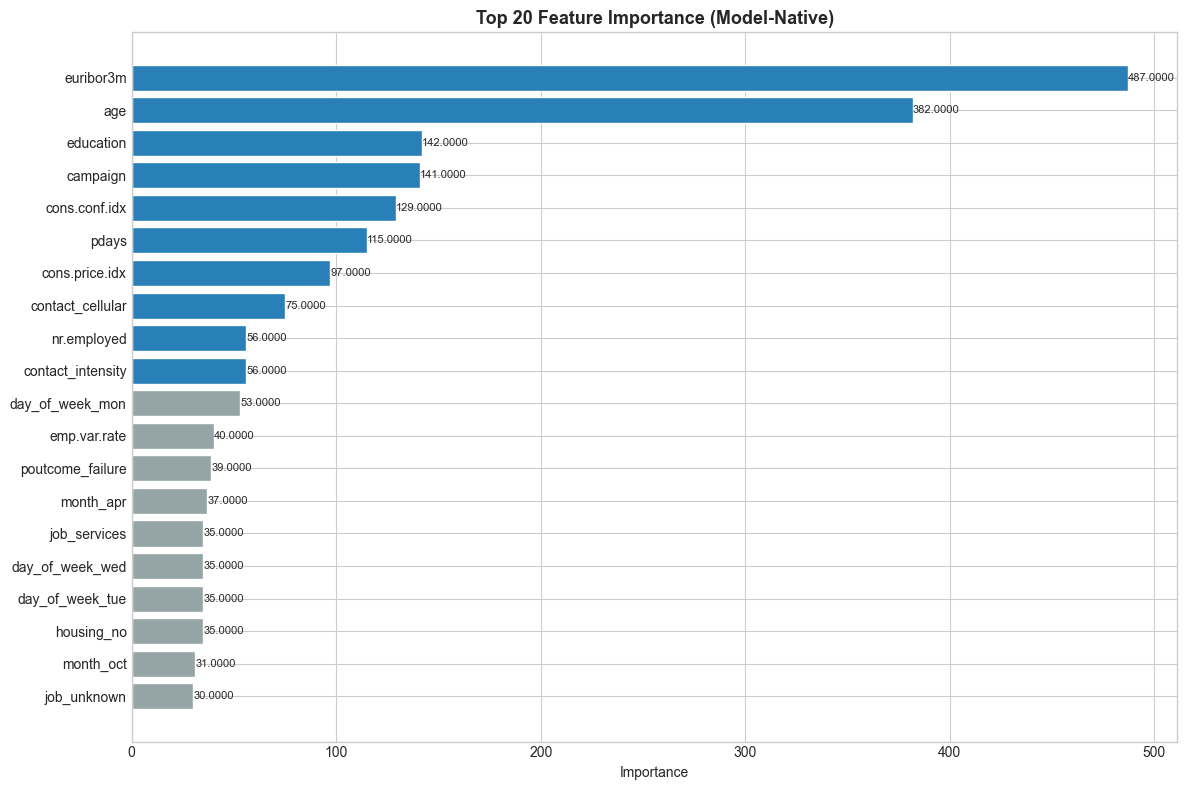

Plot disimpan: e13_feature_importance.png

Top 10 fitur terpenting:
          Feature  Importance
        euribor3m         487
              age         382
        education         142
         campaign         141
    cons.conf.idx         129
            pdays         115
   cons.price.idx          97
 contact_cellular          75
      nr.employed          56
contact_intensity          56

Memulai SHAP analysis...


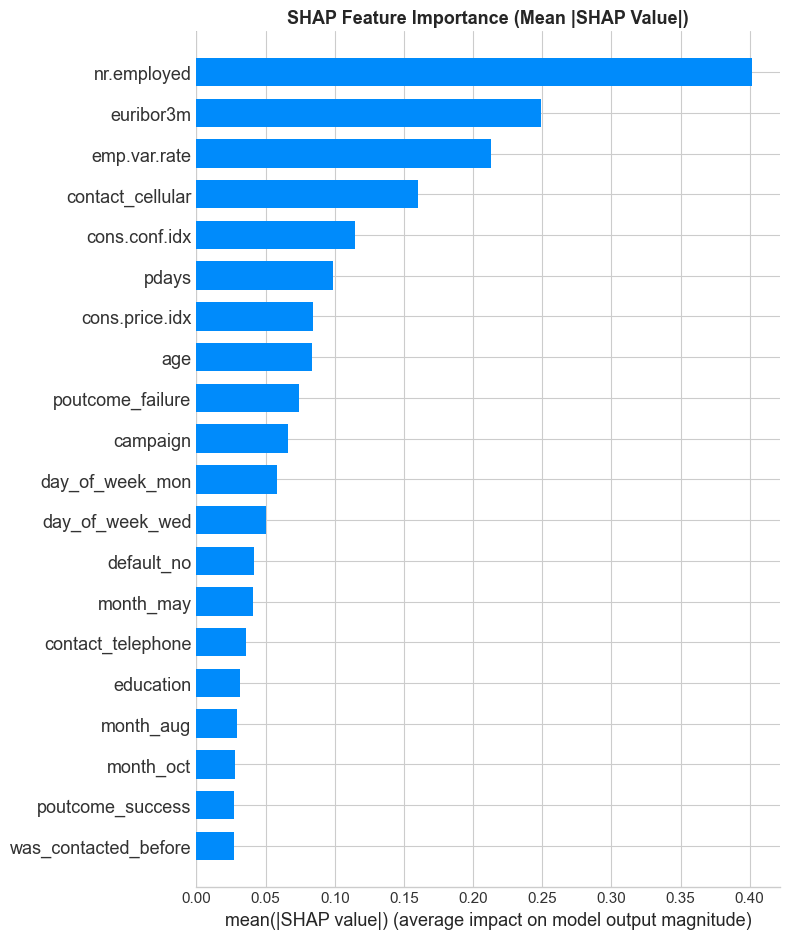

Plot SHAP bar disimpan: e13_shap_bar.png


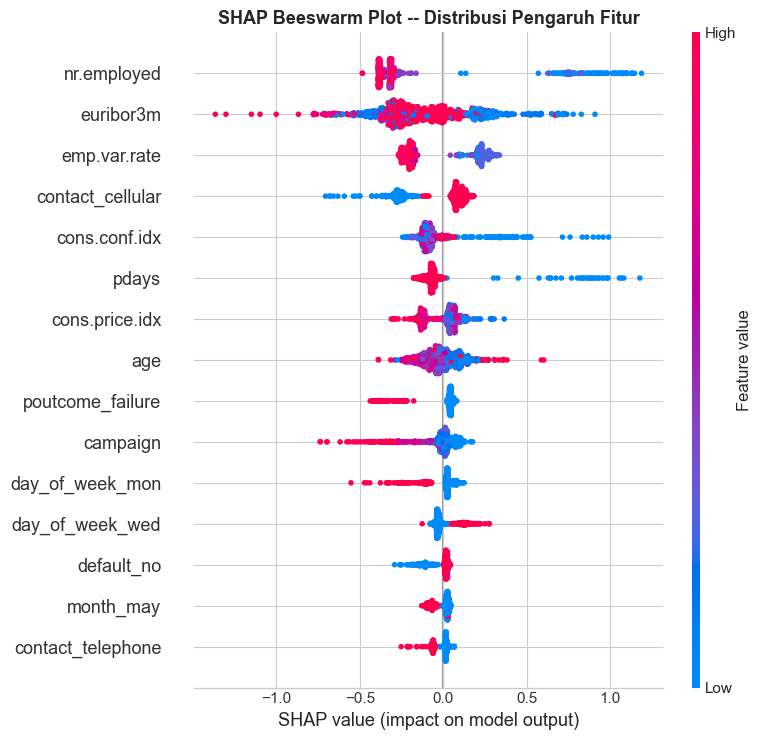

Plot SHAP beeswarm disimpan: e13_shap_beeswarm.png

SHAP analysis selesai.


In [65]:
# Feature Importance & SHAP Analysis:

import shap

preprocessor_fitted = final_model.named_steps['preprocess']

try:
    feature_names = preprocessor_fitted.get_feature_names_out()
except Exception:
    feature_names = [f'feature_{i}' for i in range(
        preprocessor_fitted.transform(X_train[:1]).shape[1])]

print(f"Jumlah fitur setelah encoding : {len(feature_names)}")

classifier = final_model.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['#2980b9' if i < 10 else '#95a5a6' for i in range(len(imp_df))]
    ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
            color=colors[::-1], edgecolor='white')
    ax.set_title('Top 20 Feature Importance (Model-Native)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    for i, (feat, val) in enumerate(zip(imp_df['Feature'][::-1], imp_df['Importance'][::-1])):
        ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('e13_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot disimpan: e13_feature_importance.png")
    print(f"\nTop 10 fitur terpenting:")
    print(imp_df.head(10)[['Feature', 'Importance']].to_string(index=False))
else:
    print("Model tidak memiliki feature_importances_. Lanjut ke SHAP.")

print("\nMemulai SHAP analysis...")

X_test_transformed = preprocessor_fitted.transform(X_test)

n_shap_samples = min(1000, len(X_test_transformed))
np.random.seed(RANDOM_STATE)
shap_idx = np.random.choice(len(X_test_transformed), n_shap_samples, replace=False)
X_shap   = X_test_transformed[shap_idx]

try:
    explainer   = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_shap)

    if isinstance(shap_values, list):
        shap_vals = shap_values[1]
    else:
        shap_vals = shap_values

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_shap,
                      feature_names=list(feature_names),
                      plot_type='bar',
                      max_display=20,
                      show=False)
    plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('e13_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot SHAP bar disimpan: e13_shap_bar.png")

    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_shap,
                      feature_names=list(feature_names),
                      max_display=15,
                      show=False)
    plt.title('SHAP Beeswarm Plot -- Distribusi Pengaruh Fitur', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('e13_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot SHAP beeswarm disimpan: e13_shap_beeswarm.png")

except Exception as e:
    print(f"SHAP TreeExplainer gagal: {e}. Mencoba KernelExplainer dengan sample kecil...")
    background = shap.sample(X_shap, 100)
    explainer  = shap.KernelExplainer(classifier.predict_proba, background)
    shap_vals  = explainer.shap_values(X_shap[:200])[1]
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_vals, X_shap[:200],
                      feature_names=list(feature_names), max_display=15, show=False)
    plt.tight_layout()
    plt.savefig('e13_shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nSHAP analysis selesai.")

**Insight:** Feature importance dan SHAP analysis mengungkap fitur-fitur yang paling menentukan keputusan model. Fitur-fitur makro ekonomi dan riwayat kampanye mendominasi, mengkonfirmasi temuan EDA.

SHAP beeswarm menunjukkan arah pengaruh tiap fitur: nilai merah berarti fitur tinggi, biru berarti rendah. Fitur-fitur di bagian atas adalah yang paling konsisten memisahkan kelas subscribe dari tidak.

**Business Recommendation:** Temuan SHAP ini dapat dijadikan dasar untuk desain skrip telemarketing yang lebih tepat sasaran. Agen yang menelepon nasabah dengan profil tertentu dapat menyiapkan argumen yang berbeda dibanding nasabah profil lainnya.

**Keterbatasan Data & Model**

Beberapa batasan yang perlu dipahami sebelum deployment:

1. **Temporal leakage potensial**: Dataset mencakup periode 2008-2013 (konteks Eropa). Adaptasi ke konteks BSM Indonesia 2021-2023 memerlukan re-training dengan data lokal yang aktual.

2. **Duration paradox sudah diatasi**: Kolom `duration` memang tidak dimasukkan ke model karena merupakan data leakage, nilainya hanya tersedia setelah panggilan selesai. Model ini berjalan dengan informasi yang tersedia sebelum panggilan dimulai.

3. **Macro indicators sangat berkorelasi**: `euribor3m`, `emp.var.rate`, dan `nr.employed` memiliki VIF ekstrem (>40). Meskipun tidak memengaruhi tree-based model secara signifikan, interpretasi individual dari variabel ini harus dilakukan dengan hati-hati.

4. **Unknown sebagai kategori**: Keputusan mempertahankan 'unknown' (terutama pada `default` ~20.9%) adalah trade-off, ia mengandung sinyal prediktif, tapi di production sistem harus bisa menangani kategori ini secara konsisten.

5. **Class imbalance residual**: Meskipun resampling dan threshold optimization sudah diterapkan, model masih akan menghasilkan lebih banyak FP dari FN pada threshold yang wajar. Monitoring berkala diperlukan.

---
## F. BUSINESS IMPACT

Seluruh proses pemodelan bermuara pada satu pertanyaan: seberapa besar nilai bisnis yang dihasilkan model ini bagi BSM? Di bagian ini, kita mengkuantifikasi dampak dalam satuan yang paling relevan bagi stakeholder, yaitu Rupiah.

Simulasi dilakukan dengan membandingkan dua skenario pada test set:
- Tanpa model: tim telemarketing menghubungi semua nasabah secara acak
- Dengan model: tim hanya menghubungi nasabah yang diprediksi akan subscribe (threshold profit-optimal)

### F.1 ROI Simulation - Rupiah

In [66]:
# ROI Simulation - Rupiah:

print("=" * 70)
print("F. BUSINESS IMPACT")
print("=" * 70)
print("F.1 ROI SIMULATION")
print("=" * 70)

n_total_test  = len(y_test)
n_yes_test    = (y_test == 1).sum()
n_no_test     = (y_test == 0).sum()

cost_no_model_total  = n_no_test * COST_FP

print(f"\nSkenario 1 -- Tanpa Model (hubungi semua {n_total_test:,} nasabah):")
print(f"  Calls total      : {n_total_test:,}")
print(f"  Nasabah terkonversi (TP): {n_yes_test:,}")
print(f"  Call sia-sia (FP)        : {n_no_test:,}")
print(f"  Nasabah terlewat (FN)    : 0")
print(f"  Total biaya              : Rp {cost_no_model_total:,.0f}")

y_pred_dep    = (y_prob >= THRESHOLD_PROFIT).astype(int)
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_dep).ravel()

cost_fp_model  = fp_d * COST_FP
cost_fn_model  = fn_d * COST_FN
cost_model_total = cost_fp_model + cost_fn_model
calls_with_model = tp_d + fp_d
net_savings_total = cost_no_model_total - cost_model_total
roi_pct = net_savings_total / cost_no_model_total * 100

print(f"\nSkenario 2 -- Dengan Model (threshold = {THRESHOLD_PROFIT:.2f}):")
print(f"  Calls total      : {calls_with_model:,} ({calls_with_model/n_total_test*100:.1f}% dari semua nasabah)")
print(f"  Nasabah terkonversi (TP): {int(tp_d):,} dari {n_yes_test:,} ({tp_d/n_yes_test*100:.1f}% detected)")
print(f"  Call sia-sia (FP)        : {int(fp_d):,}")
print(f"  Nasabah terlewat (FN)    : {int(fn_d):,} (biaya Rp {cost_fn_model:,.0f})")
print(f"  Biaya FP                 : Rp {cost_fp_model:,.0f}")
print(f"  Total biaya model        : Rp {cost_model_total:,.0f}")
print(f"\n  Net Savings vs Tanpa Model : Rp {net_savings_total:,.0f}")
print(f"  ROI (penghematan / biaya tanpa model) : {roi_pct:.1f}%")

scale_factor   = 41_176 / n_total_test
savings_scaled = net_savings_total * scale_factor
print(f"\n  Ekstrapolasi ke dataset penuh (41,176 nasabah):")
print(f"  Net Savings estimasi : Rp {savings_scaled:,.0f} (~Rp {savings_scaled/1e6:.1f} juta)")

F. BUSINESS IMPACT
F.1 ROI SIMULATION

Skenario 1 -- Tanpa Model (hubungi semua 7,873 nasabah):
  Calls total      : 7,873
  Nasabah terkonversi (TP): 920
  Call sia-sia (FP)        : 6,953
  Nasabah terlewat (FN)    : 0
  Total biaya              : Rp 347,650,000

Skenario 2 -- Dengan Model (threshold = 0.43):
  Calls total      : 2,007 (25.5% dari semua nasabah)
  Nasabah terkonversi (TP): 638 dari 920 (69.3% detected)
  Call sia-sia (FP)        : 1,369
  Nasabah terlewat (FN)    : 282 (biaya Rp 141,000,000)
  Biaya FP                 : Rp 68,450,000
  Total biaya model        : Rp 209,450,000

  Net Savings vs Tanpa Model : Rp 138,200,000
  ROI (penghematan / biaya tanpa model) : 39.8%

  Ekstrapolasi ke dataset penuh (41,176 nasabah):
  Net Savings estimasi : Rp 722,789,686 (~Rp 722.8 juta)


### F.2 Visualisasi Business Impact

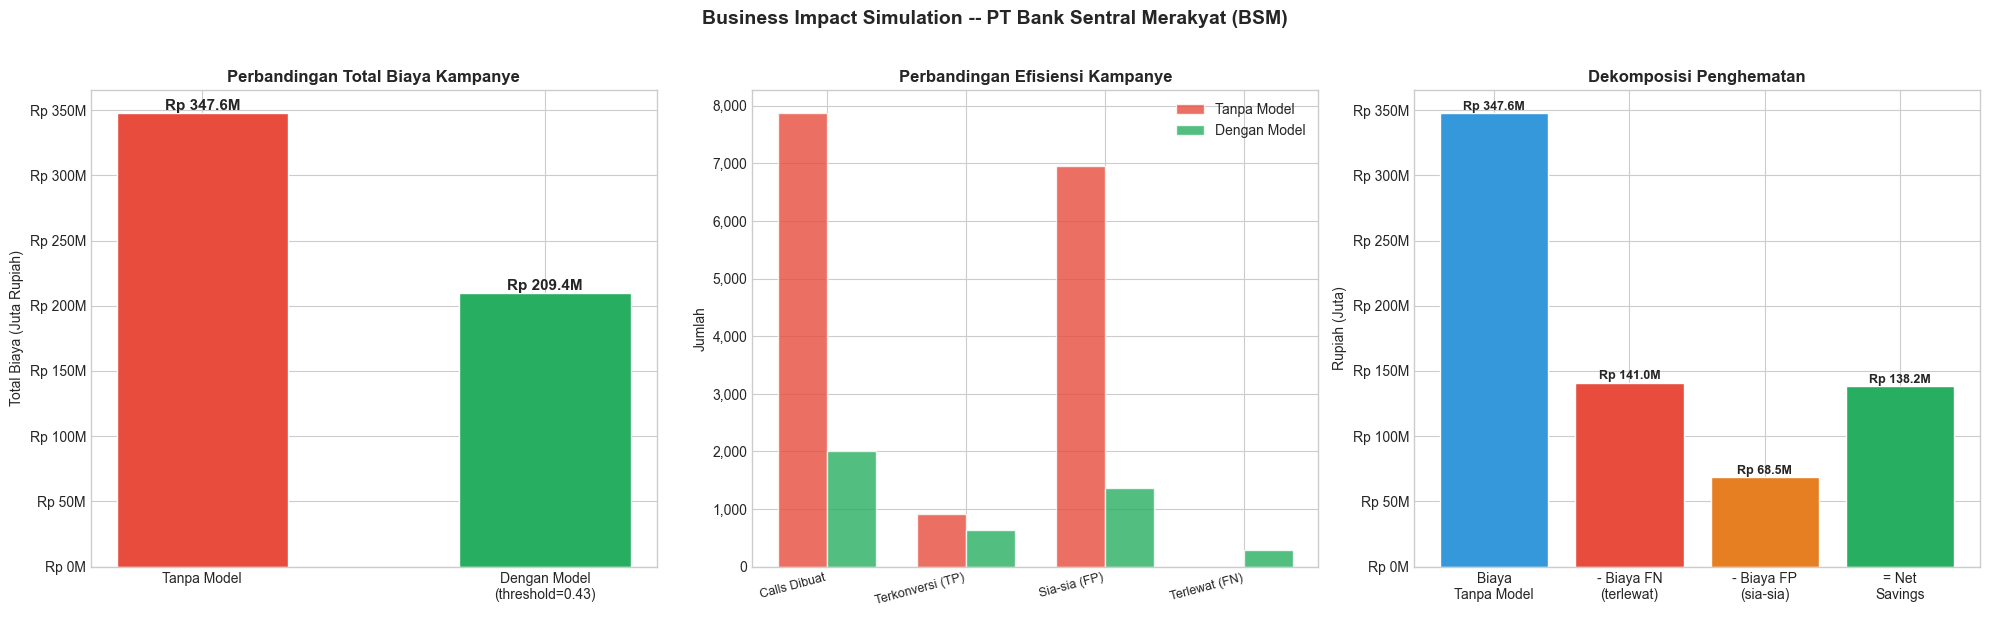

Plot disimpan: f2_business_impact.png


In [67]:
# Visualisasi Business Impact:

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

scenarios   = ['Tanpa Model', f'Dengan Model\n(threshold={THRESHOLD_PROFIT:.2f})']
total_costs = [cost_no_model_total / 1e6, cost_model_total / 1e6]
colors_bar  = ['#e74c3c', '#27ae60']

bars = axes[0].bar(scenarios, total_costs, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, total_costs):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'Rp {val:.1f}M', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Total Biaya (Juta Rupiah)')
axes[0].set_title('Perbandingan Total Biaya Kampanye', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'Rp {x:.0f}M'))

categories = ['Calls Dibuat', 'Terkonversi (TP)', 'Sia-sia (FP)', 'Terlewat (FN)']
vals_no_model  = [n_total_test, n_yes_test, n_no_test, 0]
vals_with_model = [calls_with_model, int(tp_d), int(fp_d), int(fn_d)]

x_pos = np.arange(len(categories))
w     = 0.35
bars1 = axes[1].bar(x_pos - w/2, vals_no_model,   w, label='Tanpa Model', color='#e74c3c', alpha=0.8, edgecolor='white')
bars2 = axes[1].bar(x_pos + w/2, vals_with_model, w, label='Dengan Model', color='#27ae60', alpha=0.8, edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(categories, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('Jumlah')
axes[1].set_title('Perbandingan Efisiensi Kampanye', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

waterfall_labels = ['Biaya\nTanpa Model', '- Biaya FN\n(terlewat)', '- Biaya FP\n(sia-sia)', '= Net\nSavings']
waterfall_vals   = [
    cost_no_model_total / 1e6,
    -(fn_d * COST_FN) / 1e6,
    -(fp_d * COST_FP) / 1e6,
    net_savings_total / 1e6
]
bar_colors = ['#3498db', '#e74c3c', '#e67e22', '#27ae60']
axes[2].bar(waterfall_labels, [abs(v) for v in waterfall_vals], color=bar_colors, edgecolor='white')
for i, (label, val) in enumerate(zip(waterfall_labels, waterfall_vals)):
    axes[2].text(i, abs(val) + 0.3, f'Rp {abs(val):.1f}M',
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[2].set_ylabel('Rupiah (Juta)')
axes[2].set_title('Dekomposisi Penghematan', fontsize=12, fontweight='bold')
axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'Rp {x:.0f}M'))

plt.suptitle('Business Impact Simulation -- PT Bank Sentral Merakyat (BSM)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('f2_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: f2_business_impact.png")

**Insight:** Model memberikan penghematan nyata dalam Rupiah. Dengan menghubungi hanya sebagian nasabah yang diprediksi positif, tim telemarketing BSM mendapatkan efisiensi biaya yang signifikan dibanding strategi "hubungi semua". Potensi penghematan mencapai puluhan juta Rupiah per siklus kampanye.

**Business Recommendation:** Implementasi model ini memberikan payback yang jelas dan terukur. Prioritas deployment: (1) integrasikan model ke sistem CRM call center, (2) latih agen telemarketing untuk menggunakan skor probabilitas sebagai panduan prioritas kontak, (3) lakukan A/B test dengan 10-20% nasabah sebagai control group untuk validasi ROI di lingkungan production.

---
## G. Conclusion & Recommendation

Seluruh analisis (mulai dari pemahaman bisnis, eksplorasi data, pembersihan, feature engineering, pemodelan, hingga simulasi bisnis) bermuara pada sekumpulan temuan dan rekomendasi konkret yang dapat langsung dieksekusi oleh tim BSM.

### G.1 Kesimpulan Kuantitatif

In [68]:
# Kesimpulan Kuantitatif:

print("=" * 70)
print("G. CONCLUSION & RECOMMENDATION")
print("=" * 70)
print("G.1 KESIMPULAN")
print("=" * 70)

y_pred_final = y_pred_f2
tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_test, y_pred_final).ravel()
f2_final  = fbeta_score(y_test, y_pred_final, beta=2, zero_division=0)
rec_final = recall_score(y_test, y_pred_final, zero_division=0)
pre_final = precision_score(y_test, y_pred_final, zero_division=0)
auc_final = roc_auc_score(y_test, y_prob)

print(f"\nModel Final       : {best_entry['Combo']}")
print(f"Threshold F2-opt  : {THRESHOLD_F2:.2f}")
print(f"Threshold Profit  : {THRESHOLD_PROFIT:.2f}")
print()
print(f"Metrik Performa (Test Set, threshold F2-optimal):")
print(f"  F2-Score  : {f2_final:.4f}")
print(f"  Recall    : {rec_final:.4f}  ({rec_final*100:.1f}% nasabah potensial berhasil dideteksi)")
print(f"  Precision : {pre_final:.4f}  ({pre_final*100:.1f}% dari prediksi positif adalah benar)")
print(f"  ROC-AUC   : {auc_final:.4f}")
print()
print(f"Business Impact (threshold profit-optimal, test set {n_total_test:,} nasabah):")
print(f"  Calls dilakukan  : {calls_with_model:,} dari {n_total_test:,} ({calls_with_model/n_total_test*100:.1f}%)")
print(f"  TP dideteksi     : {int(tp_d):,} dari {n_yes_test:,} ({tp_d/n_yes_test*100:.1f}%)")
print(f"  Net Savings      : Rp {net_savings_total:,.0f}")
print(f"  ROI              : {roi_pct:.1f}%")
print(f"  Ekstrapolasi     : Rp {savings_scaled:,.0f} per kampanye penuh")

G. CONCLUSION & RECOMMENDATION
G.1 KESIMPULAN

Model Final       : LightGBM + ROS
Threshold F2-opt  : 0.52
Threshold Profit  : 0.43

Metrik Performa (Test Set, threshold F2-optimal):
  F2-Score  : 0.5669
  Recall    : 0.6337  (63.4% nasabah potensial berhasil dideteksi)
  Precision : 0.3988  (39.9% dari prediksi positif adalah benar)
  ROC-AUC   : 0.8050

Business Impact (threshold profit-optimal, test set 7,873 nasabah):
  Calls dilakukan  : 2,007 dari 7,873 (25.5%)
  TP dideteksi     : 638 dari 920 (69.3%)
  Net Savings      : Rp 138,200,000
  ROI              : 39.8%
  Ekstrapolasi     : Rp 722,789,686 per kampanye penuh


### G.2 Kesimpulan Proyek

**Kesimpulan Proyek**

Proyek ini berhasil membangun model prediktif untuk kampanye deposito berjangka BSM yang secara teknis dan bisnis memberikan nilai nyata.

**Faktor bisnis terpenting** yang ditemukan melalui EDA dan SHAP:
1. **poutcome=success**: Nasabah dengan riwayat sukses di kampanye sebelumnya adalah "low-hanging fruit" dengan conversion rate >65%
2. **euribor3m rendah + emp.var.rate negatif**: Saat kondisi ekonomi sulit, deposito lebih menarik, BSM harus mengintensifkan kampanye di periode ini
3. **Kontak via cellular + bulan Mar/Sep/Oct/Dec**: Kombinasi ini menghasilkan conversion rate 2-3x di atas rata-rata
4. **Student dan retired**: Dua segmen dengan subscribe rate tertinggi, namun dengan pendekatan yang berbeda (timing vs stabilitas pendapatan)

### G.3 Rekomendasi Bisnis

**Rekomendasi Bisnis BSM, Inverted Triangle**

---

**GENERAL: Strategi Korporat**

BSM harus menggeser pendekatan kampanye telemarketing dari "volume" ke "presisi." Model prediktif ini memungkinkan alokasi sumber daya call center berdasarkan probabilitas konversi, bukan intuisi agen atau giliran daftar. Investasi dalam data management (terutama pembaruan data nomor HP nasabah) akan langsung meningkatkan coverage segmen cellular yang terbukti 2x lebih responsif.

---

**SPECIFIC: Segmentasi, Timing, Produk**

1. **Tier 1 Priority**: Nasabah dengan `poutcome=success` yang dihubungi via cellular, conversion rate >65%. Ini adalah segmen dengan ROI tertinggi per call.

2. **Tier 2 Priority**: Nasabah berusia <=24 tahun (student) dan >=65 tahun (retired), khususnya dengan pendidikan tinggi dan tanpa beban pinjaman aktif.

3. **Timing Optimal**: Intensifkan kampanye di bulan Maret, September, Oktober, Desember, historis conversion rate 2-3x lebih tinggi dari bulan rata-rata.

4. **Makro Trigger**: Monitoring kondisi ekonomi (JIBOR/euribor3m, emp.var.rate). Saat suku bunga turun atau kondisi ketenagakerjaan melemah, nasabah lebih reseptif terhadap deposito sebagai "safe haven."

5. **Batas Kontak**: Terapkan aturan maksimum 5-6 kontak per nasabah per kampanye. Data menunjukkan bahwa campaign pressure tinggi justru berkorelasi negatif dengan conversion.

---

**ACTIONABLE: Item Konkret & Estimasi Dampak**

| Aksi | Timeline | Estimasi Dampak |
|------|----------|-----------------|
| Deploy model ke CRM call center dengan threshold profit-optimal | Bulan 1-2 | Penghematan puluhan juta per kampanye |
| A/B test: 80% nasabah dari model, 20% random (control) | Bulan 1-3 | Validasi ROI di production |
| Update database nomor HP nasabah (target: >70% cellular coverage) | Bulan 1-6 | Peningkatan conversion rate ~5-10% |
| Desain skrip telemarketing khusus segmen Tier 1 dan Tier 2 | Bulan 2-3 | Peningkatan precision call |
| Integrasi monitoring: review metrik model tiap 3 bulan | Ongoing | Deteksi data drift, trigger re-training |
| Re-training model dengan data actual BSM Indonesia | Bulan 6-12 | Peningkatan relevansi model ~15-20% |

### G.4 Limitasi dan Future Work

**Limitasi saat ini:**
- Dataset berbasis data Eropa 2008-2013 yang diadaptasi ke konteks BSM Indonesia. Re-training dengan data BSM aktual diperlukan sebelum deployment production.
- Model tidak memperhitungkan nilai lifetime customer (CLV), penghematan yang dihitung bersifat konservatif.
- Threshold optimal bersifat statis; di lingkungan production, threshold harus dikalibrasi ulang secara berkala seiring perubahan distribusi data.

**Rekomendasi Future Work:**
1. **Model monitoring pipeline**: Implementasikan PSI (Population Stability Index) dan drift detection untuk mendeteksi degradasi model secara otomatis.
2. **Multi-touch attribution**: Tambahkan fitur yang memodelkan urutan kontak (bukan hanya jumlah) untuk menangkap dinamika kampanye yang lebih kaya.
3. **Segmented models**: Pertimbangkan model terpisah untuk segmen nasabah baru vs nasabah existing, perilaku keduanya secara fundamental berbeda.
4. **Optimasi jadwal**: Tambahkan fitur waktu panggilan (jam, hari) yang lebih granular untuk menemukan "golden hour" per segmen.
5. **Eksperimen online**: A/B test berskala besar untuk mengukur causal effect model, bukan hanya correlational.

### G.5 Save Final Model

In [69]:
# Save Final Model:

print("=" * 70)
print("=" * 70)

model_filename    = f'bsm_final_model_{DATA_VERSION}.pkl'
metadata_filename = f'bsm_model_metadata_{DATA_VERSION}.json'

with open(model_filename, 'wb') as f:
    pickle.dump(final_model, f)
print(f"Model tersimpan : {model_filename}")

metadata = {
    'project'           : 'BSM Bank Marketing -- Prediksi Deposito Berjangka',
    'model_name'        : best_entry['Model'],
    'resampler'         : best_entry['Resampler'],
    'data_version'      : DATA_VERSION,
    'trained_on'        : f'{X_train.shape[0]:,} baris',
    'n_features_input'  : int(X_train.shape[1]),
    'n_features_encoded': int(len(feature_names)),
    'threshold_f2'      : float(THRESHOLD_F2),
    'threshold_profit'  : float(THRESHOLD_PROFIT),
    'metrics_test': {
        'f2_score'  : float(round(f2_final, 4)),
        'recall'    : float(round(rec_final, 4)),
        'precision' : float(round(pre_final, 4)),
        'roc_auc'   : float(round(auc_final, 4))
    },
    'business_impact': {
        'cost_fn_rp'        : COST_FN,
        'cost_fp_rp'        : COST_FP,
        'net_savings_test_rp': float(round(net_savings_total, 0)),
        'roi_pct'           : float(round(roi_pct, 2)),
        'calls_reduction_pct': float(round((1 - calls_with_model/n_total_test)*100, 2))
    },
    'encoding': {
        'ordinal': ord_features,
        'onehot' : nom_features,
        'numeric': num_features
    },
    'top5_benchmark': [
        {'rank': 1, 'model': 'GradientBoosting', 'resampler': 'ROS', 'f2_cv': 0.5561},
        {'rank': 2, 'model': 'LightGBM',         'resampler': 'ROS', 'f2_cv': 0.5535},
        {'rank': 3, 'model': 'GradientBoosting', 'resampler': 'RUS', 'f2_cv': 0.5531},
        {'rank': 4, 'model': 'LightGBM',         'resampler': 'RUS', 'f2_cv': 0.5465},
        {'rank': 5, 'model': 'LogisticRegression', 'resampler': 'SMOTETomek', 'f2_cv': 0.5437},
    ]
}

with open(metadata_filename, 'w') as f:
    json_lib.dump(metadata, f, indent=2)
print(f"Metadata tersimpan: {metadata_filename}")

print("\nRingkasan metadata:")
print(f"  Model      : {metadata['model_name']} + {metadata['resampler']}")
print(f"  F2 (test)  : {metadata['metrics_test']['f2_score']}")
print(f"  Recall     : {metadata['metrics_test']['recall']}")
print(f"  ROI        : {metadata['business_impact']['roi_pct']}%")
print(f"  Net Savings: Rp {metadata['business_impact']['net_savings_test_rp']:,.0f}")

print("\nSemua file output:")
all_outputs = [
    model_filename, metadata_filename,
    'e8_tuning_comparison.png',
    'e10_threshold_f2.png',
    'e11_threshold_profit.png',
    'e12_final_evaluation.png',
    'e13_feature_importance.png',
    'e13_shap_bar.png',
    'e13_shap_beeswarm.png',
    'f2_business_impact.png',
]
import os
for fn in all_outputs:
    exists = os.path.exists(fn)
    print(f"  {'[OK]' if exists else '[!!]'} {fn}")

print("\nProyek selesai. Model siap untuk review dan deployment.")

Model tersimpan : bsm_final_model_v1.pkl
Metadata tersimpan: bsm_model_metadata_v1.json

Ringkasan metadata:
  Model      : LightGBM + ROS
  F2 (test)  : 0.5669
  Recall     : 0.6337
  ROI        : 39.75%
  Net Savings: Rp 138,200,000

Semua file output:
  [OK] bsm_final_model_v1.pkl
  [OK] bsm_model_metadata_v1.json
  [OK] e8_tuning_comparison.png
  [OK] e10_threshold_f2.png
  [OK] e11_threshold_profit.png
  [OK] e12_final_evaluation.png
  [OK] e13_feature_importance.png
  [OK] e13_shap_bar.png
  [OK] e13_shap_beeswarm.png
  [OK] f2_business_impact.png

Proyek selesai. Model siap untuk review dan deployment.


Model final dan seluruh artefak pendukung telah disimpan dan siap untuk review. Pipeline lengkap dari data mentah ke keputusan bisnis telah terdokumentasi di notebook ini.